In [63]:
# Zelle 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import pymongo
import os
from tensorflow.keras.utils import Sequence
import gc  # Garbage Collector
from tqdm import tqdm  # Fortschrittsanzeige

In [64]:
# Zelle 2: Datenbankverbindung und Datenladung
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    # Daten laden
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    # In DataFrames konvertieren
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    # Merge der DataFrames
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                        left_on='fingerprintId', 
                        right_on='_id', 
                        suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Daten laden
merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

Gesamtdatensatz enthält 2000000 Einträge.


In [65]:
# Zelle 3: Bildverarbeitung
def process_image(base64_str, target_size=(64, 64)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data))
        image = image.convert('RGB')
        image = image.resize(target_size)
        return np.array(image) / 255.0
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

In [66]:
# Zelle 4: Custom Data Generator
class MongoDBDataGenerator(Sequence):
    def __init__(self, df, example_user_id, batch_size=32, target_size=(64, 64), shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.example_user_id = example_user_id
        self.target_size = target_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()
    
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]
        
        X = []
        y = []
        for _, row in batch_df.iterrows():
            img = process_image(row['sampleData'], self.target_size)
            if img is not None:
                X.append(img)
                label = 1 if row['username'] == self.example_user_id else 0
                y.append(label)
        
        X = np.array(X)
        y = np.array(y)
        
        return X, y
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [67]:
# Zelle 5: Daten vorbereiten und aufteilen
example_user_id = 'benutzername_1'
print("Starte Datenverarbeitung...")

try:
    # Daten-Generator erstellen
    generator = MongoDBDataGenerator(merged_df, example_user_id, batch_size=32, target_size=(64, 64), shuffle=True)
    
    # Gesamte Datenanzahl
    total_samples = len(generator.df)
    print(f"Gesamtanzahl der Samples: {total_samples}")
    
    # Aufteilung in Train/Val/Test
    # Indizes für Aufteilung
    train_val_indices, test_indices = train_test_split(np.arange(total_samples), test_size=0.2, random_state=42, stratify=merged_df['username'].apply(lambda x: 1 if x == example_user_id else 0))
    train_indices, val_indices = train_test_split(train_val_indices, test_size=0.25, random_state=42, stratify=merged_df.iloc[train_val_indices]['username'].apply(lambda x: 1 if x == example_user_id else 0))
    
    # Separate DataFrames
    train_df = merged_df.iloc[train_indices]
    val_df = merged_df.iloc[val_indices]
    test_df = merged_df.iloc[test_indices]
    
    print("\nAufteilung abgeschlossen:")
    print(f"Training: {len(train_df)} Bilder")
    print(f"Validierung: {len(val_df)} Bilder")
    print(f"Test: {len(test_df)} Bilder")
    
    # Erstellen der Generatoren
    train_generator = MongoDBDataGenerator(train_df, example_user_id, batch_size=32, target_size=(64, 64), shuffle=True)
    val_generator = MongoDBDataGenerator(val_df, example_user_id, batch_size=32, target_size=(64, 64), shuffle=False)
    test_generator = MongoDBDataGenerator(test_df, example_user_id, batch_size=32, target_size=(64, 64), shuffle=False)
    
    # Speicher freigeben
    del merged_df
    gc.collect()
    
except Exception as e:
    print(f"Fehler bei der Datenverarbeitung: {str(e)}")
    raise

Starte Datenverarbeitung...
Gesamtanzahl der Samples: 2000000

Aufteilung abgeschlossen:
Training: 1200000 Bilder
Validierung: 400000 Bilder
Test: 400000 Bilder


In [68]:
# Zelle 6: CNN Modell Definition
def create_cnn_model(input_shape=(64, 64, 3)):
    model = Sequential([
        # Erste Convolution Block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Zweite Convolution Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Dritte Convolution Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Fully Connected Layer
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [ ]:
# Zelle 7: Modell erstellen und trainieren
model = create_cnn_model()
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Starte Modelltraining...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

Starte Modelltraining...
Epoch 1/50
37500/37500 [==============================] - 391s 10ms/step - loss: 0.1989 - accuracy: 0.9500 - val_loss: 0.1985 - val_accuracy: 0.9500
Epoch 4/50
37500/37500 [==============================] - 393s 10ms/step - loss: 0.1986 - accuracy: 0.9500 - val_loss: 0.1985 - val_accuracy: 0.9500
Epoch 5/50
37500/37500 [==============================] - 392s 10ms/step - loss: 0.1985 - accuracy: 0.9500 - val_loss: 0.1985 - val_accuracy: 0.9500
Epoch 6/50
37500/37500 [==============================] - 393s 10ms/step - loss: 0.1985 - accuracy: 0.9500 - val_loss: 0.1985 - val_accuracy: 0.9500
Epoch 7/50
37500/37500 [==============================] - 393s 10ms/step - loss: 0.1985 - accuracy: 0.9500 - val_loss: 0.1985 - val_accuracy: 0.9500
Epoch 8/50
37494/37500 [============================>.] - ETA: 0s - loss: 0.1985 - accuracy: 0.9500

2024-11-04 15:56:23.175688: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_5/dropout_20/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


21210/37500 [===============>..............] - ETA: 2:07 - loss: 0.2022 - accuracy: 0.9497

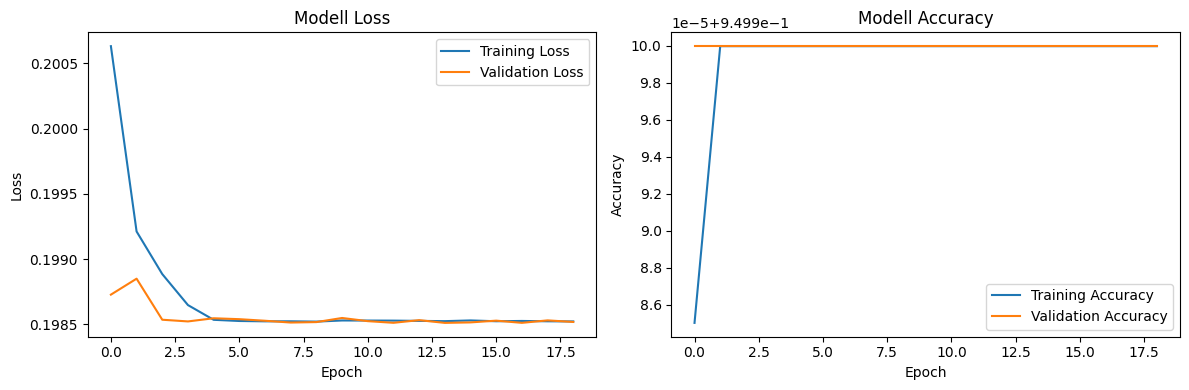

In [70]:
# Zelle 8: Training Visualisierung
plt.figure(figsize=(12, 4))

# Verlust
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Modell Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Genauigkeit
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modell Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
# Zelle 9: Modell Evaluation
def evaluate_model(model, generator):
    y_true = []
    y_pred = []
    
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        preds = model.predict(X_batch)
        preds_binary = (preds > 0.5).astype(int).flatten()
        
        y_true.extend(y_batch)
        y_pred.extend(preds_binary)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    conf_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, target_names=["Nicht Benutzer 1", "Benutzer 1"])
    
    # ROC Kurve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    
    return conf_matrix, class_report, fpr, tpr, roc_auc, y_true, y_pred

print("Starte Evaluation des Modells auf Testdaten...")
conf_matrix, class_report, fpr, tpr, roc_auc, y_true, y_pred = evaluate_model(model, test_generator)

print("\nKonfusionsmatrix:")
print(conf_matrix)
print("\nKlassifikationsbericht:")
print(class_report)

Starte Evaluation des Modells auf Testdaten...
1/1 [==============================] - 0s 8ms/step
1/1 [=======================<======] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 [=======<======================] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 Z==============================] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 [===<==========================] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 [==<===========================] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 Z==============================] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 [====<=========================] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 [===========<==================] - 0s 8ms/step
1/1 [==============================] - 0s 8ms/step
1/1 Z==============================] - 0s 8ms/step
1/1 [==============================

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Cool stuff

In [77]:
# Zelle X: Zusätzliche Imports für Evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tqdm import tqdm
import gc  # Garbage Collector

In [86]:
# Zelle Y: Evaluation Funktion definieren (Überarbeitet)
def evaluate_model_per_user(model, df, example_user_id, samples_per_user=1000, target_size=(64, 64)):
    unique_users = df['username'].unique()
    results = {}
    
    print("Starte Evaluation für jeden Benutzer...")
    
    for user in tqdm(unique_users, desc="Evaluating Users"):
        # Anzahl der verfügbaren Samples für den Benutzer
        available_samples = len(df[df['username'] == user])
        num_samples = min(samples_per_user, available_samples)
        
        # Zufälliges Sampling
        user_df = df[df['username'] == user].sample(n=num_samples, random_state=42)
        
        X = []
        y = []
        
        for _, row in user_df.iterrows():
            img = process_image(row['sampleData'], target_size)
            if img is not None:
                X.append(img)
                label = 1 if user == example_user_id else 0
                y.append(label)
        
        if len(X) == 0:
            print(f"Keine gültigen Bilder für Benutzer {user}. Überspringe...")
            continue
        
        X = np.array(X)
        y = np.array(y)
        
        # Vorhersagen generieren
        y_pred = model.predict(X)
        y_pred_binary = (y_pred > 0.5).astype(int).flatten()
        
        # Metriken berechnen
        conf_matrix = confusion_matrix(y, y_pred_binary, labels=[0,1])
        try:
            class_report = classification_report(y, y_pred_binary, target_names=["Nicht Benutzer 1", "Benutzer 1"], labels=[0,1], zero_division=0)
        except ValueError as ve:
            print(f"Fehler bei der Erstellung des Klassifikationsberichts für Benutzer {user}: {ve}")
            class_report = "Nicht genügend Klassen zur Erstellung des Berichts."
        
        fpr, tpr, _ = roc_curve(y, y_pred)
        roc_auc = auc(fpr, tpr)
        
        # Ergebnisse speichern
        results[user] = {
            'conf_matrix': conf_matrix,
            'class_report': class_report,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc
        }
        
        # Konfusionsmatrix visualisieren
        plt.figure(figsize=(6, 4))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=["Nicht Benutzer 1", "Benutzer 1"],
                    yticklabels=["Nicht Benutzer 1", "Benutzer 1"])
        plt.title(f'Konfusionsmatrix - Benutzer {user}')
        plt.xlabel('Vorhergesagt')
        plt.ylabel('Tatsächlich')
        plt.show()
        
        # ROC Kurve visualisieren
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - Benutzer {user}')
        plt.legend(loc="lower right")
        plt.show()
        
        print(f"Ergebnisse für Benutzer {user}:")
        print(class_report)
        print(f"ROC AUC: {roc_auc:.2f}\n")
        
        # Speicher freigeben
        del X, y, y_pred, y_pred_binary, conf_matrix, class_report, fpr, tpr
        gc.collect()
    
    return results

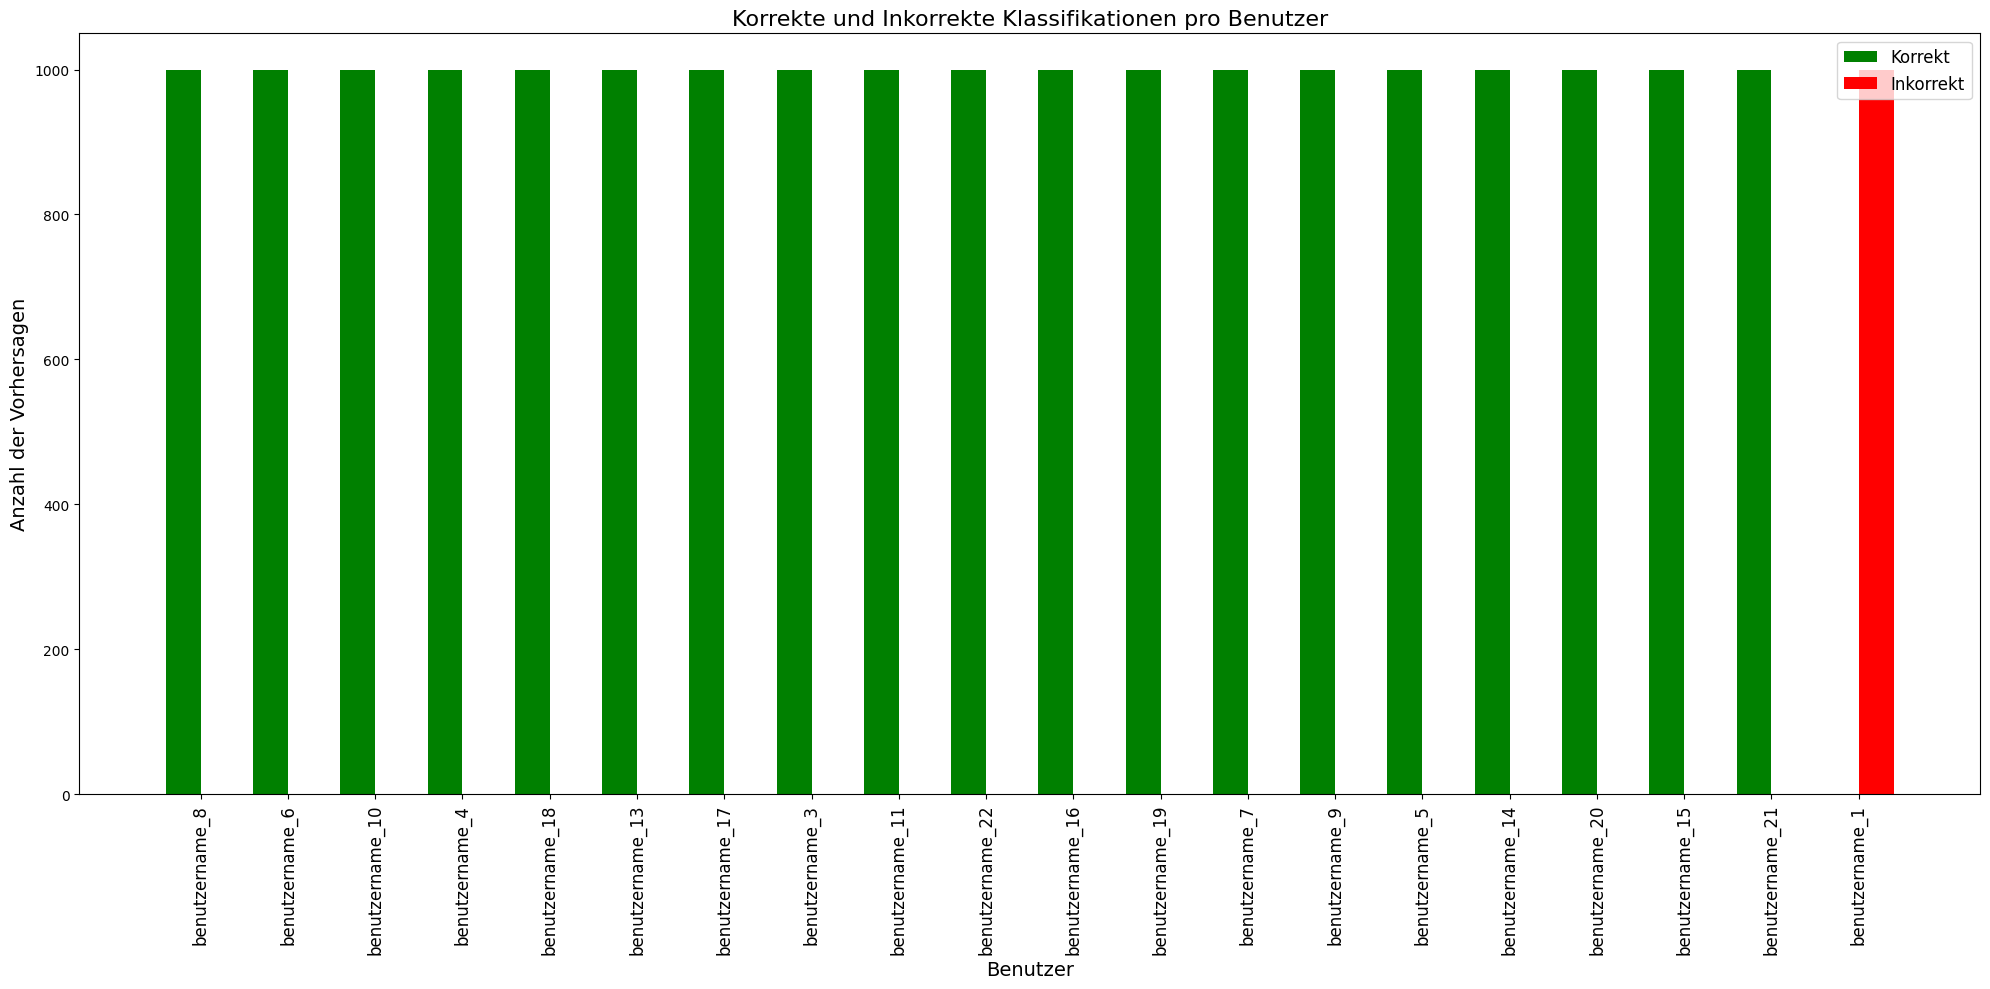

In [92]:
# Zelle AB: Visualisierung der korrekten und inkorrekten Klassifikationen pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie Listen zur Speicherung der Daten
users = []
correct = []
incorrect = []

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user, metrics in evaluation_results.items():
    conf_matrix = metrics['conf_matrix']
    
    # Konfusionsmatrix hat das Format:
    # [[TN, FP],
    #  [FN, TP]]
    if conf_matrix.shape == (2, 2):
        tn, fp, fn, tp = conf_matrix.ravel()
        # Korrkekte Vorhersagen: TN + TP
        correct_count = tn + tp
        # Inkorrekte Vorhersagen: FP + FN
        incorrect_count = fp + fn
    elif conf_matrix.shape == (1, 2):
        # Nur Klasse 0 vorhanden
        tn, fp = conf_matrix.ravel()
        correct_count = tn
        incorrect_count = fp
    elif conf_matrix.shape == (2, 1):
        # Nur Klasse 1 vorhanden
        fn, tp = conf_matrix.ravel()
        correct_count = tp
        incorrect_count = fn
    else:
        # Unerwartetes Format
        correct_count = 0
        incorrect_count = 0
    
    users.append(user)
    correct.append(correct_count)
    incorrect.append(incorrect_count)

# Erstellen eines DataFrames
data = pd.DataFrame({
    'Benutzer': users,
    'Korrekt': correct,
    'Inkorrekt': incorrect
})

# Sortieren der Benutzer nach korrekten Vorhersagen (optional)
data = data.sort_values(by='Korrekt', ascending=False)

# Erstellen des gruppierten Balkendiagramms
plt.figure(figsize=(20, 10))
bar_width = 0.4
indices = range(len(data))

plt.bar(indices, data['Korrekt'], width=bar_width, color='green', label='Korrekt')
plt.bar([i + bar_width for i in indices], data['Inkorrekt'], width=bar_width, color='red', label='Inkorrekt')

plt.xlabel('Benutzer', fontsize=14)
plt.ylabel('Anzahl der Vorhersagen', fontsize=14)
plt.title('Korrekte und Inkorrekte Klassifikationen pro Benutzer', fontsize=16)
plt.xticks([i + bar_width / 2 for i in indices], data['Benutzer'], rotation=90, fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

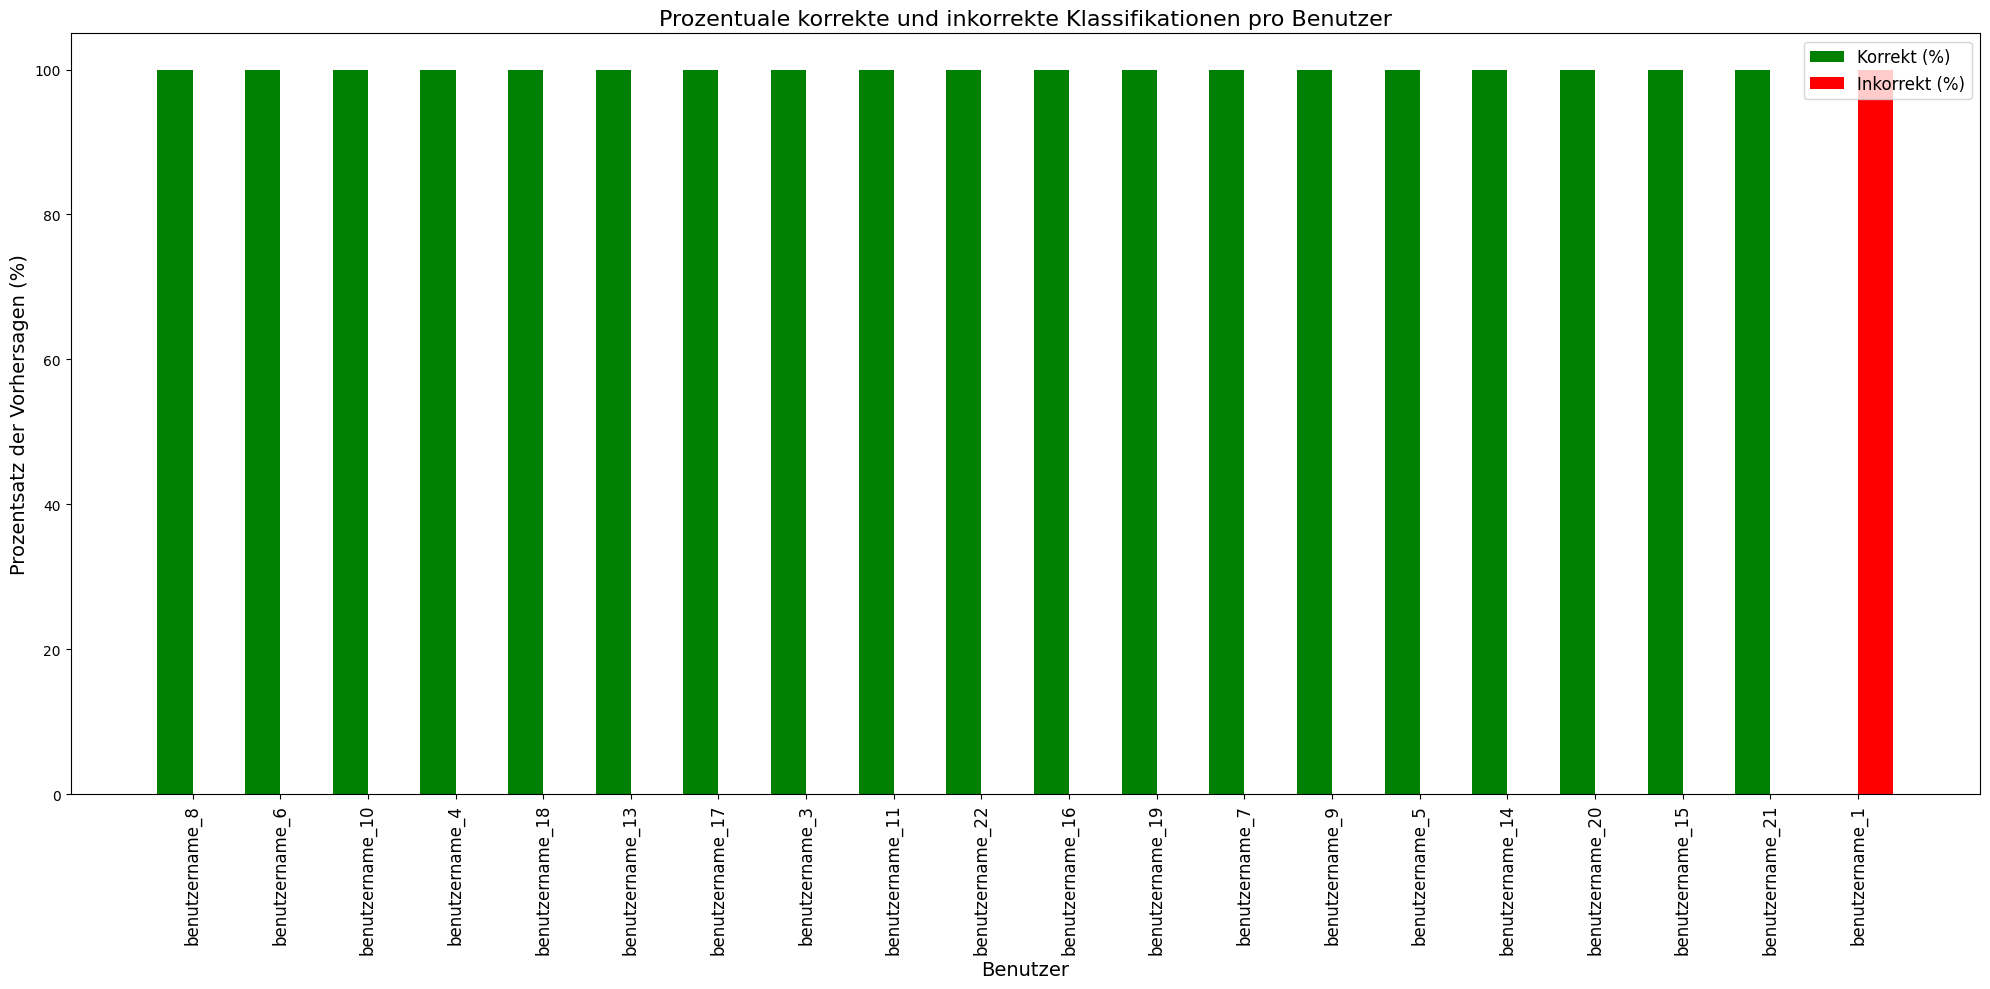

In [84]:
# Zelle AC: Prozente der korrekten und inkorrekten Klassifikationen pro Benutzer

# Berechnen der Prozentsätze
data['Korrekt_Percent'] = (data['Korrekt'] / (data['Korrekt'] + data['Inkorrekt'])) * 100
data['Inkorrekt_Percent'] = (data['Inkorrekt'] / (data['Korrekt'] + data['Inkorrekt'])) * 100

# Erstellen des gruppierten Balkendiagramms
plt.figure(figsize=(20, 10))
plt.bar(indices, data['Korrekt_Percent'], width=bar_width, color='green', label='Korrekt (%)')
plt.bar([i + bar_width for i in indices], data['Inkorrekt_Percent'], width=bar_width, color='red', label='Inkorrekt (%)')

plt.xlabel('Benutzer', fontsize=14)
plt.ylabel('Prozentsatz der Vorhersagen (%)', fontsize=14)
plt.title('Prozentuale korrekte und inkorrekte Klassifikationen pro Benutzer', fontsize=16)
plt.xticks([i + bar_width / 2 for i in indices], data['Benutzer'], rotation=90, fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Starte Modell Evaluation auf Testdaten...
Starte Evaluation für jeden Benutzer...


Evaluating Users:   0%|          | 0/20 [00:00<?, ?it/s]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


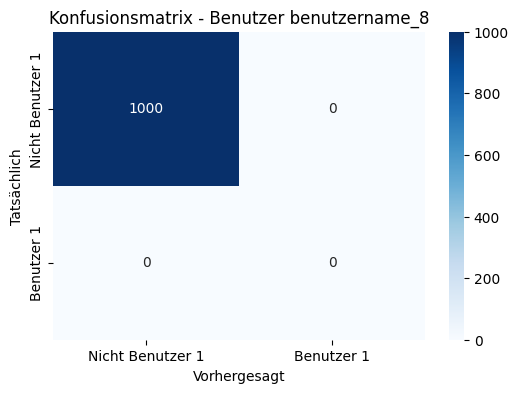

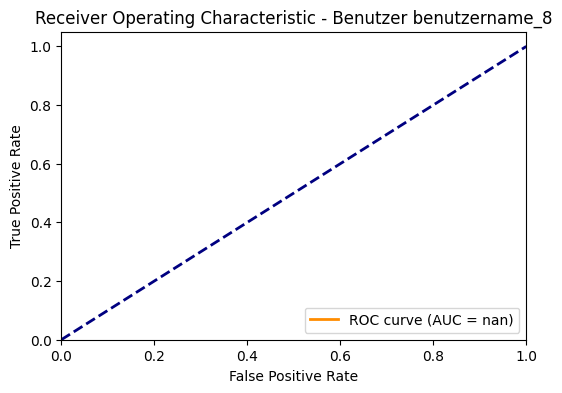

Ergebnisse für Benutzer benutzername_8:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:   5%|▌         | 1/20 [00:04<01:21,  4.32s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


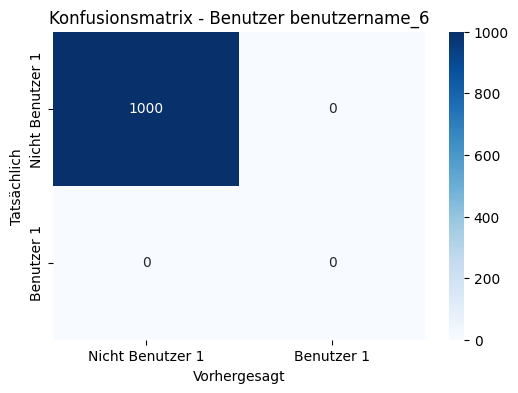

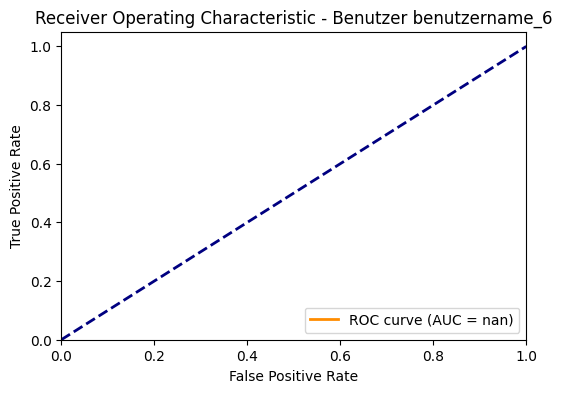

Evaluating Users:  10%|█         | 2/20 [00:07<01:05,  3.66s/it]

Ergebnisse für Benutzer benutzername_6:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


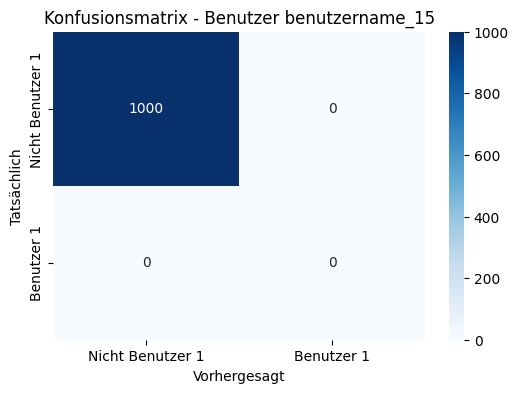

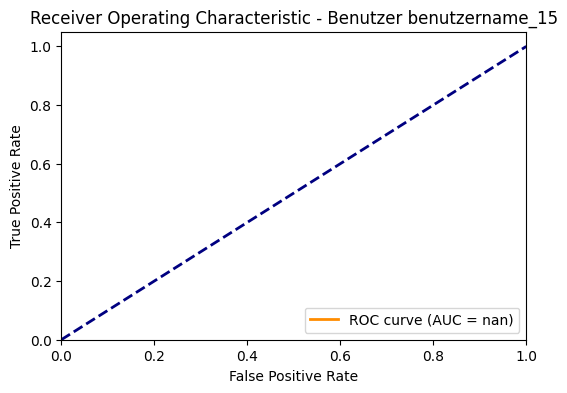

Evaluating Users:  15%|█▌        | 3/20 [00:10<00:57,  3.37s/it]

Ergebnisse für Benutzer benutzername_15:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


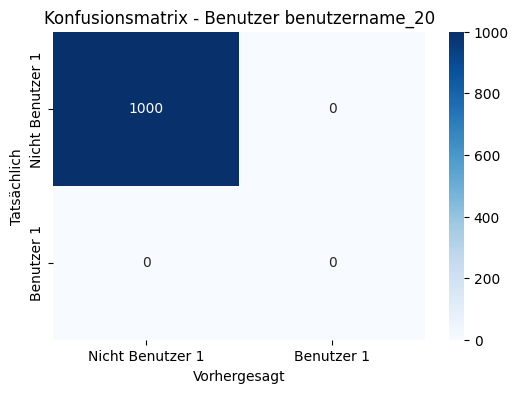

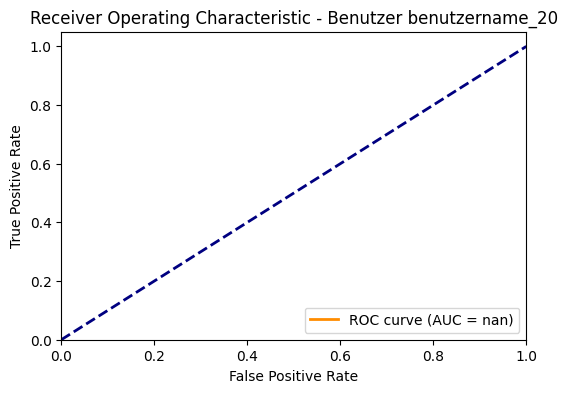

Ergebnisse für Benutzer benutzername_20:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  20%|██        | 4/20 [00:13<00:51,  3.24s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


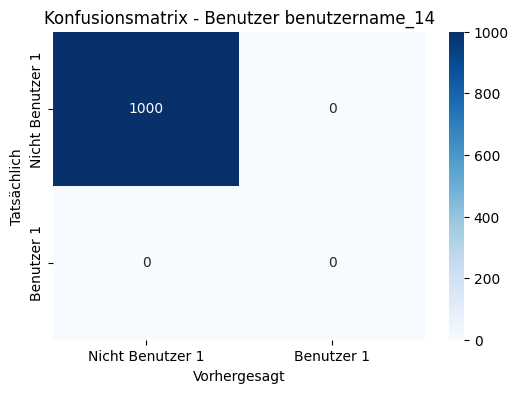

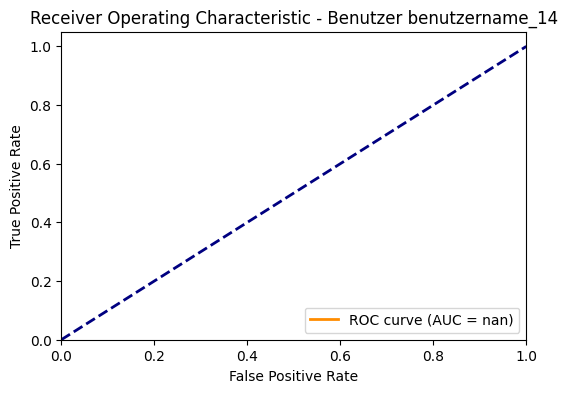

Ergebnisse für Benutzer benutzername_14:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  25%|██▌       | 5/20 [00:16<00:47,  3.15s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


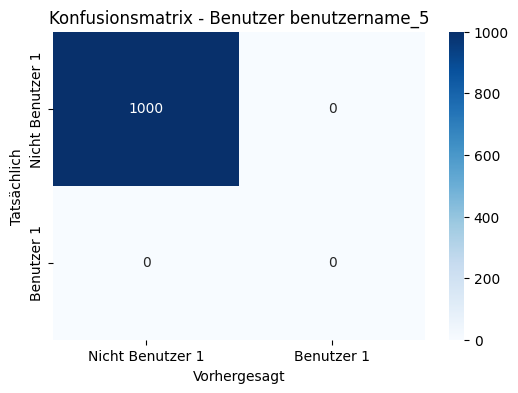

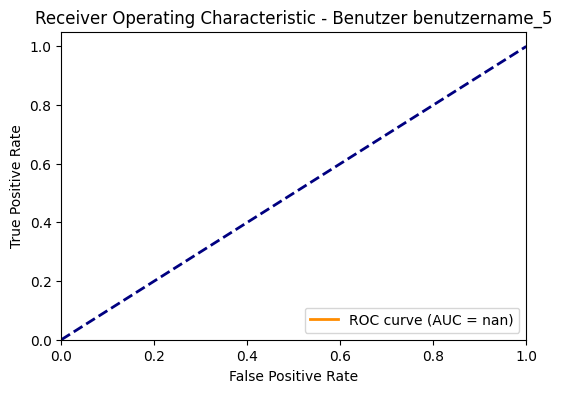

Ergebnisse für Benutzer benutzername_5:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  30%|███       | 6/20 [00:19<00:43,  3.12s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


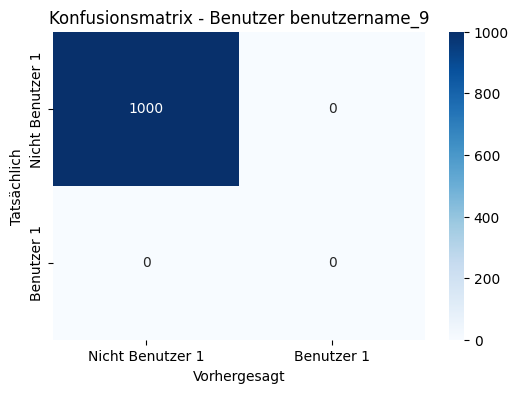

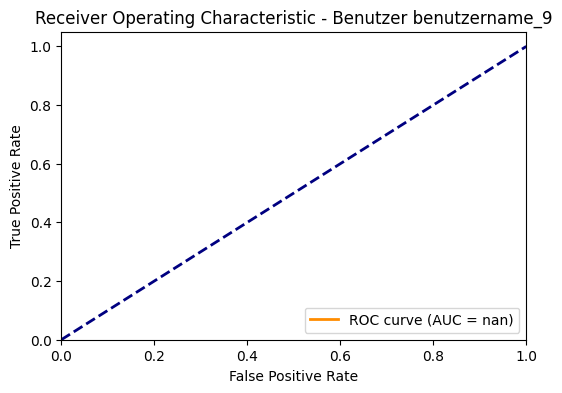

Evaluating Users:  35%|███▌      | 7/20 [00:22<00:40,  3.09s/it]

Ergebnisse für Benutzer benutzername_9:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


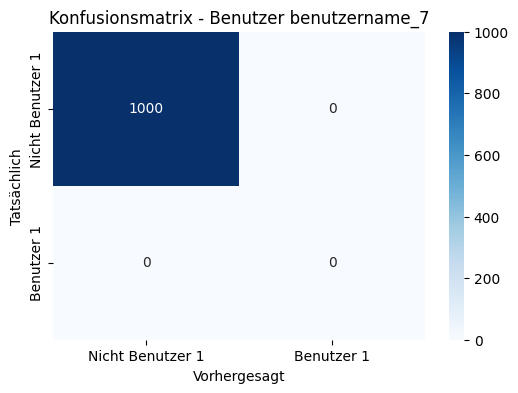

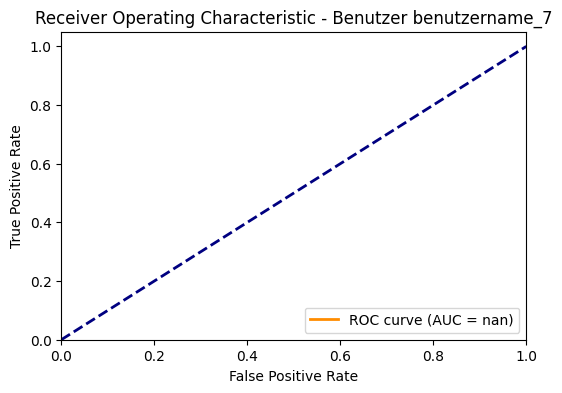

Ergebnisse für Benutzer benutzername_7:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  40%|████      | 8/20 [00:25<00:36,  3.07s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


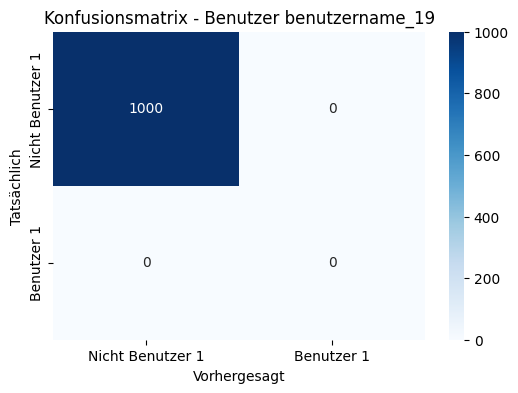

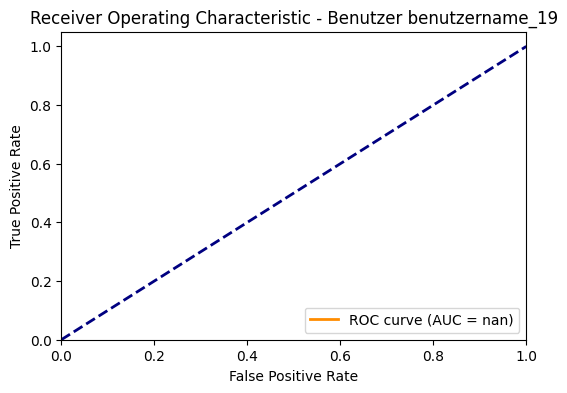

Evaluating Users:  45%|████▌     | 9/20 [00:28<00:33,  3.05s/it]

Ergebnisse für Benutzer benutzername_19:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


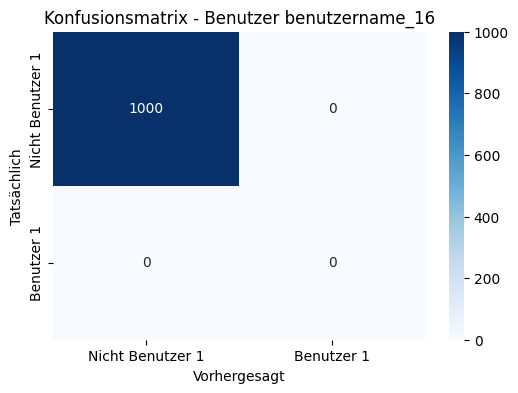

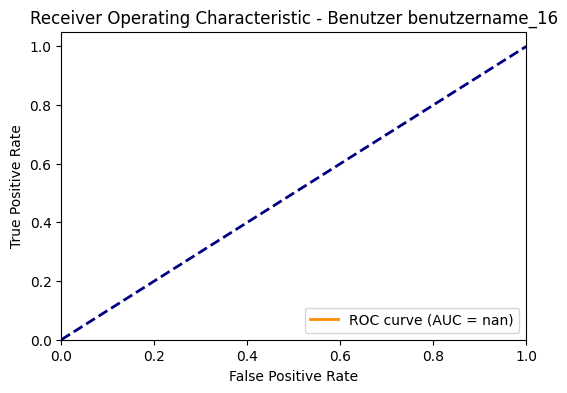

Evaluating Users:  50%|█████     | 10/20 [00:31<00:30,  3.05s/it]

Ergebnisse für Benutzer benutzername_16:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


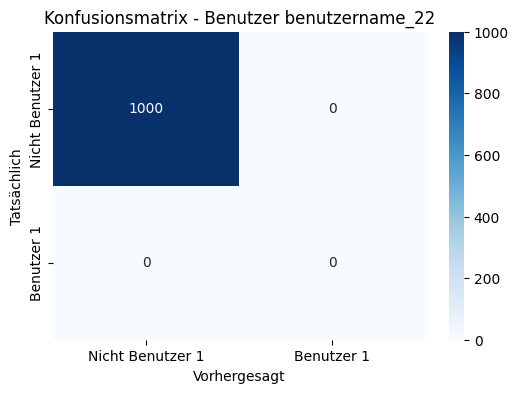

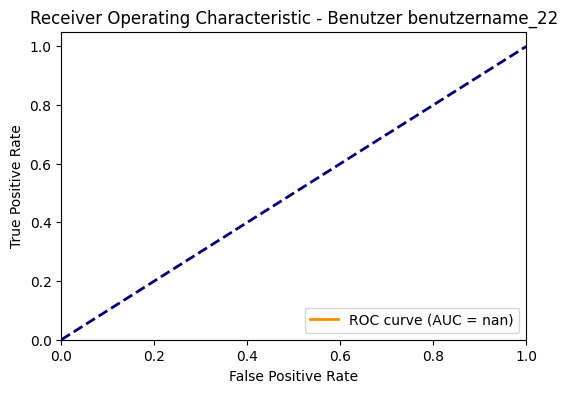

Evaluating Users:  55%|█████▌    | 11/20 [00:34<00:27,  3.04s/it]

Ergebnisse für Benutzer benutzername_22:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


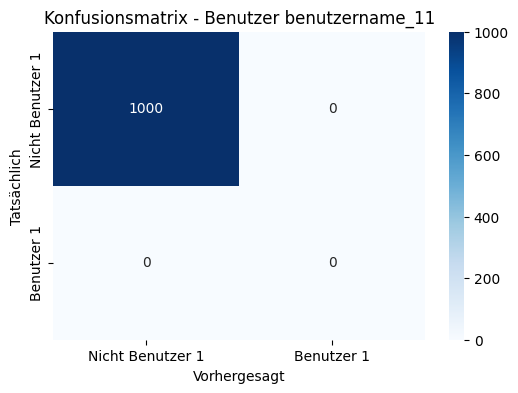

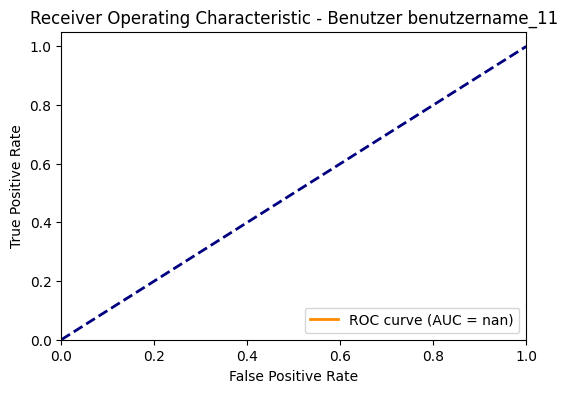

Ergebnisse für Benutzer benutzername_11:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  60%|██████    | 12/20 [00:37<00:24,  3.03s/it]

32/32 [==============================] - 0s 2ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


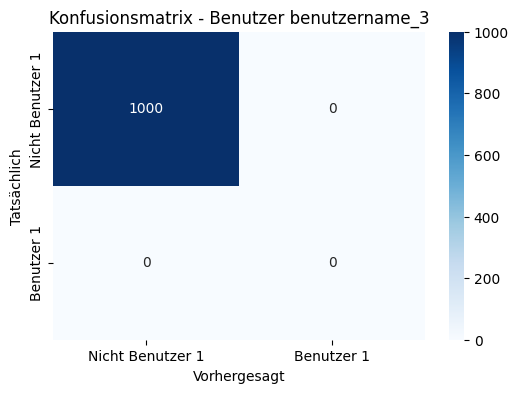

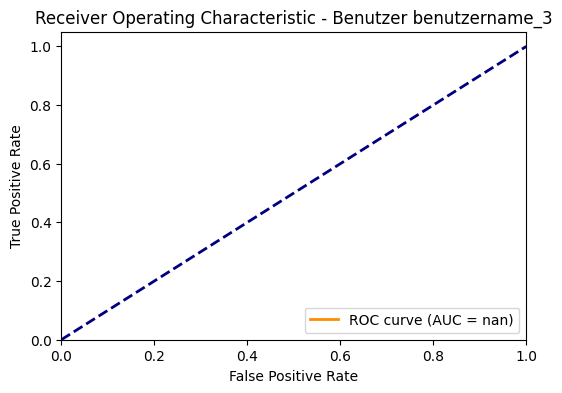

Ergebnisse für Benutzer benutzername_3:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  65%|██████▌   | 13/20 [00:40<00:21,  3.04s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


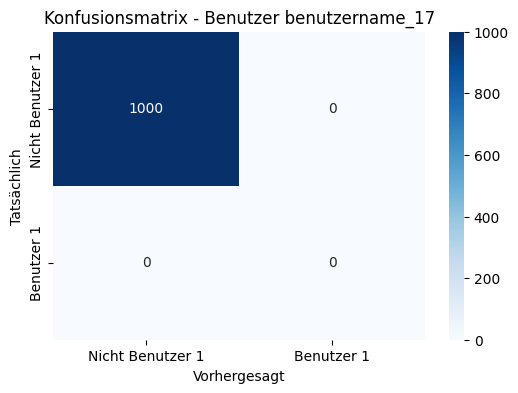

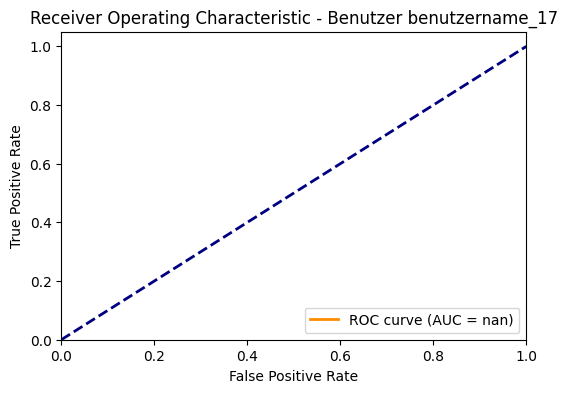

Ergebnisse für Benutzer benutzername_17:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  70%|███████   | 14/20 [00:43<00:18,  3.01s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


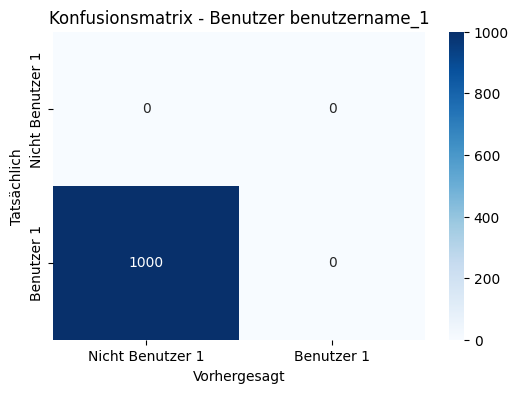

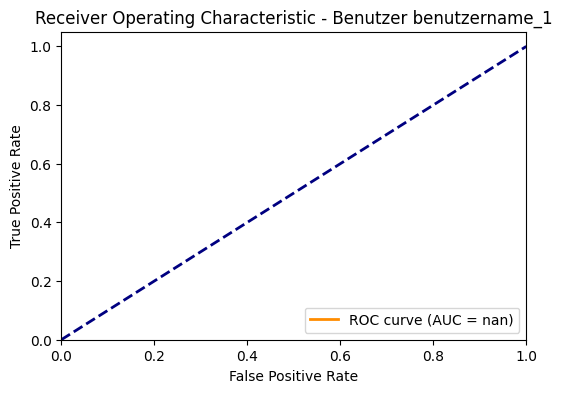

Ergebnisse für Benutzer benutzername_1:
                  precision    recall  f1-score   support

Nicht Benutzer 1       0.00      0.00      0.00       0.0
      Benutzer 1       0.00      0.00      0.00    1000.0

        accuracy                           0.00    1000.0
       macro avg       0.00      0.00      0.00    1000.0
    weighted avg       0.00      0.00      0.00    1000.0

ROC AUC: nan



Evaluating Users:  75%|███████▌  | 15/20 [00:46<00:15,  3.00s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


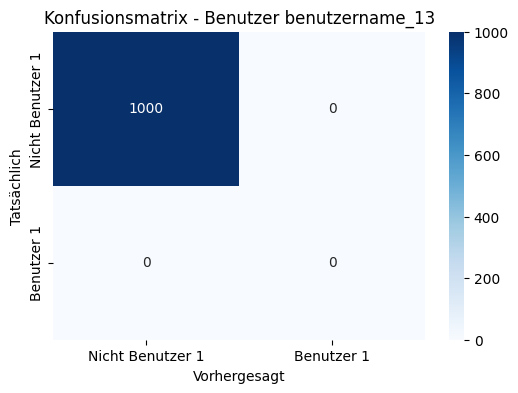

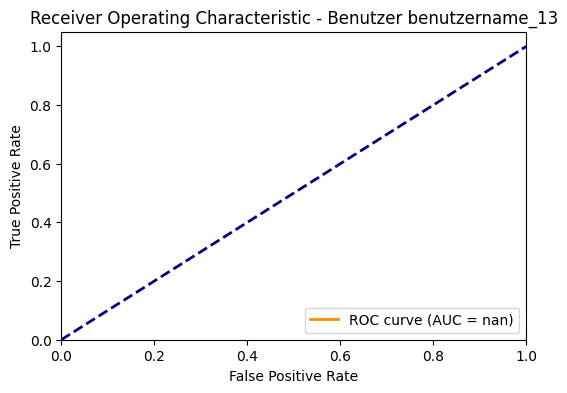

Ergebnisse für Benutzer benutzername_13:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  80%|████████  | 16/20 [00:49<00:11,  2.99s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


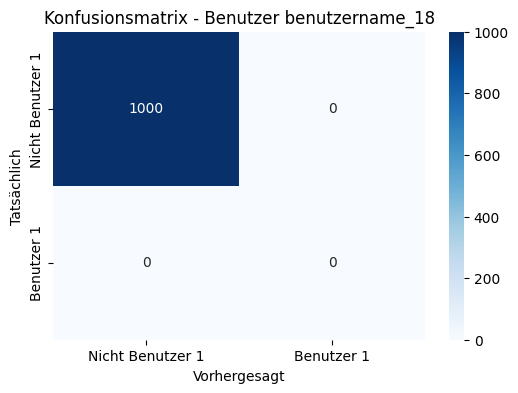

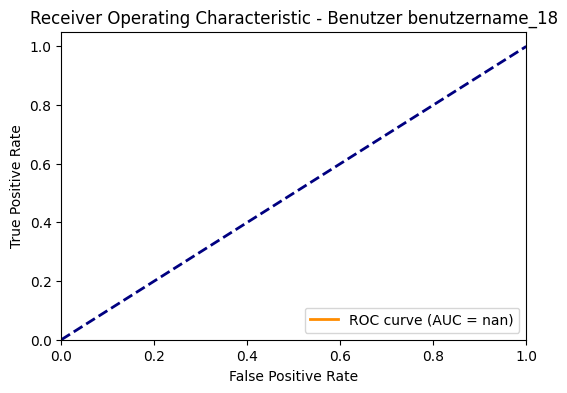

Ergebnisse für Benutzer benutzername_18:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  85%|████████▌ | 17/20 [00:52<00:08,  2.99s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


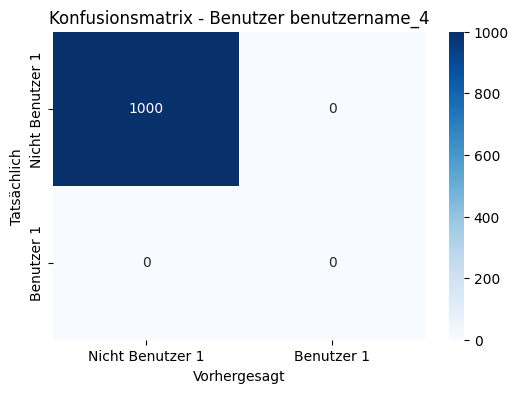

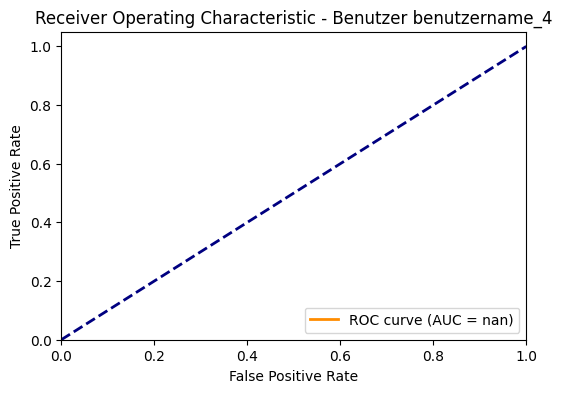

Ergebnisse für Benutzer benutzername_4:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  90%|█████████ | 18/20 [00:55<00:05,  2.99s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


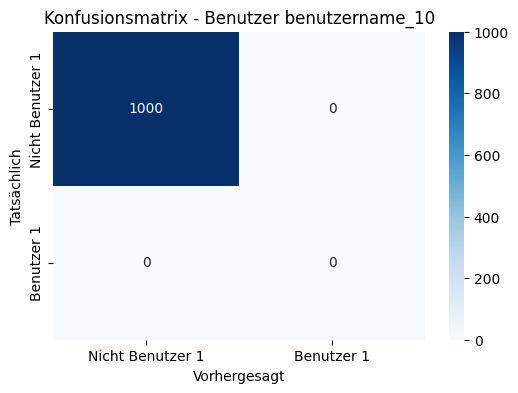

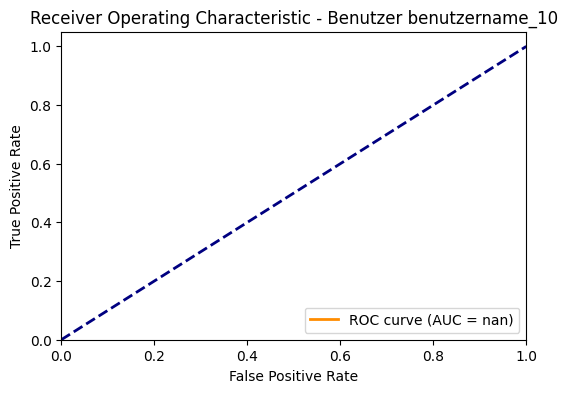

Ergebnisse für Benutzer benutzername_10:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  95%|█████████▌| 19/20 [00:58<00:03,  3.00s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


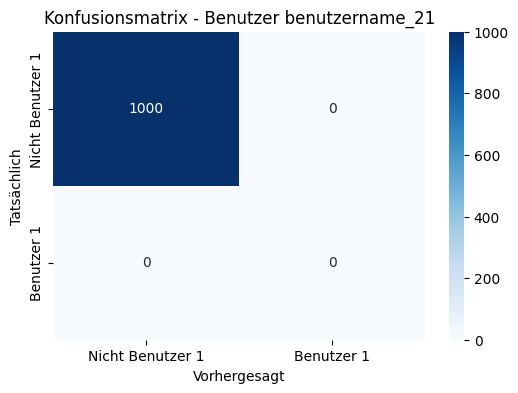

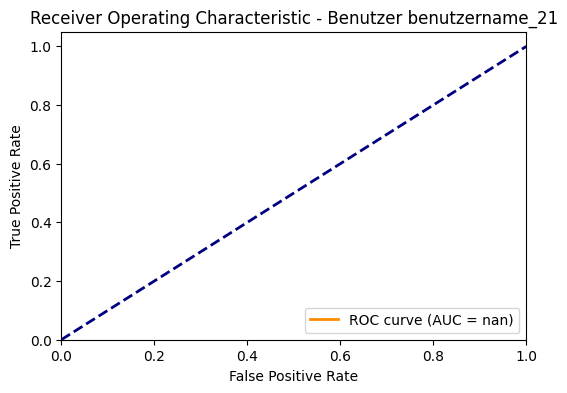

Ergebnisse für Benutzer benutzername_21:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users: 100%|██████████| 20/20 [01:01<00:00,  3.09s/it]

Evaluation abgeschlossen.


In [81]:
# Zelle Z: Modell Evaluation durchführen (Überarbeitet)
print("Starte Modell Evaluation auf Testdaten...")

# Annahme: test_df enthält Ihre Testdaten
# Falls Sie eine andere DataFrame-Variable für den Testdatensatz verwenden, passen Sie dies entsprechend an

evaluation_results = evaluate_model_per_user(
    model=model,
    df=test_df,
    example_user_id=example_user_id,
    samples_per_user=1000,
    target_size=(64, 64)
)

print("Evaluation abgeschlossen.")

In [93]:
# Zelle Y: Evaluation Funktion definieren (Überarbeitet)
def evaluate_model_per_user(model, df, example_user_id, samples_per_user=1000, target_size=(64, 64)):
    unique_users = df['username'].unique()
    results = {}
    
    print("Starte Evaluation für jeden Benutzer...")
    
    for user in tqdm(unique_users, desc="Evaluating Users"):
        # Anzahl der verfügbaren Samples für den Benutzer
        available_samples = len(df[df['username'] == user])
        num_samples = min(samples_per_user, available_samples)
        
        # Zufälliges Sampling
        user_df = df[df['username'] == user].sample(n=num_samples, random_state=42)
        
        X = []
        y = []
        
        for _, row in user_df.iterrows():
            img = process_image(row['sampleData'], target_size)
            if img is not None:
                X.append(img)
                label = 1 if user == example_user_id else 0
                y.append(label)
        
        if len(X) == 0:
            print(f"Keine gültigen Bilder für Benutzer {user}. Überspringe...")
            continue
        
        X = np.array(X)
        y = np.array(y)
        
        # Vorhersagen generieren
        y_pred = model.predict(X)
        y_pred_binary = (y_pred > 0.5).astype(int).flatten()
        
        # Metriken berechnen
        conf_matrix = confusion_matrix(y, y_pred_binary, labels=[0,1])
        try:
            class_report = classification_report(
                y, 
                y_pred_binary, 
                target_names=["Nicht Benutzer 1", "Benutzer 1"], 
                labels=[0,1], 
                zero_division=0
            )
        except ValueError as ve:
            print(f"Fehler bei der Erstellung des Klassifikationsberichts für Benutzer {user}: {ve}")
            class_report = "Nicht genügend Klassen zur Erstellung des Berichts."
        
        fpr, tpr, _ = roc_curve(y, y_pred)
        roc_auc = auc(fpr, tpr)
        
        # Ergebnisse speichern, inklusive y_pred
        results[user] = {
            'conf_matrix': conf_matrix,
            'class_report': class_report,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'y_pred': y_pred.flatten()  # Speichern der Vorhersage-Werte
        }
        
        # Konfusionsmatrix visualisieren
        plt.figure(figsize=(6, 4))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=["Nicht Benutzer 1", "Benutzer 1"],
                    yticklabels=["Nicht Benutzer 1", "Benutzer 1"])
        plt.title(f'Konfusionsmatrix - Benutzer {user}')
        plt.xlabel('Vorhergesagt')
        plt.ylabel('Tatsächlich')
        plt.show()
        
        # ROC Kurve visualisieren
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - Benutzer {user}')
        plt.legend(loc="lower right")
        plt.show()
        
        print(f"Ergebnisse für Benutzer {user}:")
        print(class_report)
        print(f"ROC AUC: {roc_auc:.2f}\n")
        
        # Speicher freigeben
        del X, y, y_pred, y_pred_binary, conf_matrix, class_report, fpr, tpr
        gc.collect()
    
    return results

Starte Modell Evaluation auf Testdaten...
Starte Evaluation für jeden Benutzer...


Evaluating Users:   0%|          | 0/20 [00:00<?, ?it/s]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


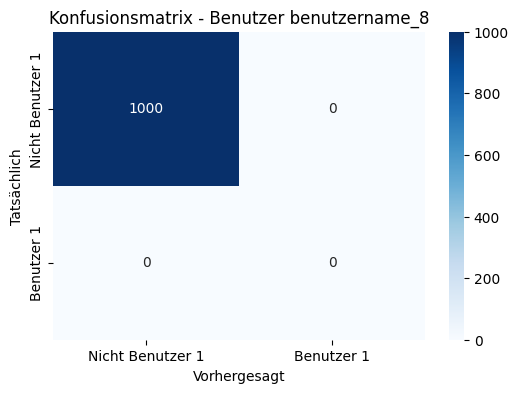

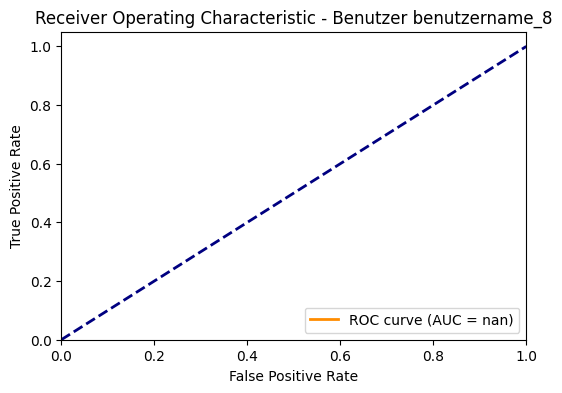

Ergebnisse für Benutzer benutzername_8:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:   5%|▌         | 1/20 [00:03<00:58,  3.07s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


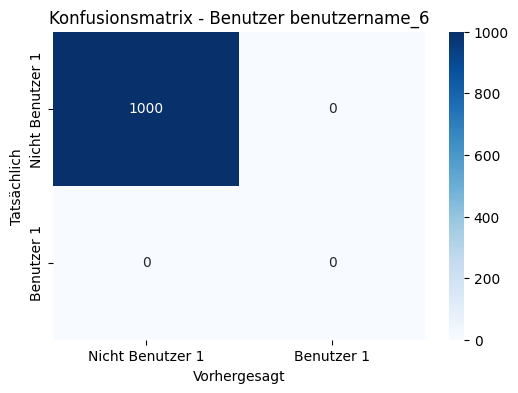

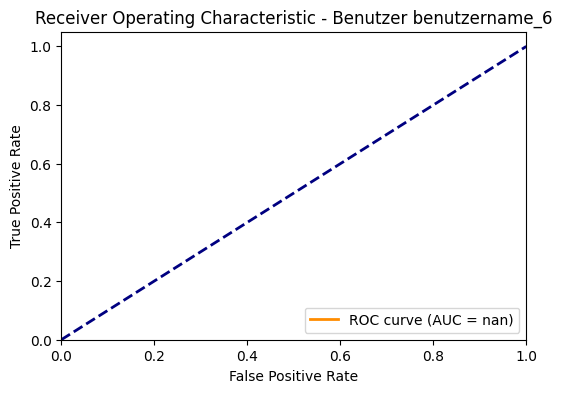

Ergebnisse für Benutzer benutzername_6:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  10%|█         | 2/20 [00:06<00:55,  3.06s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


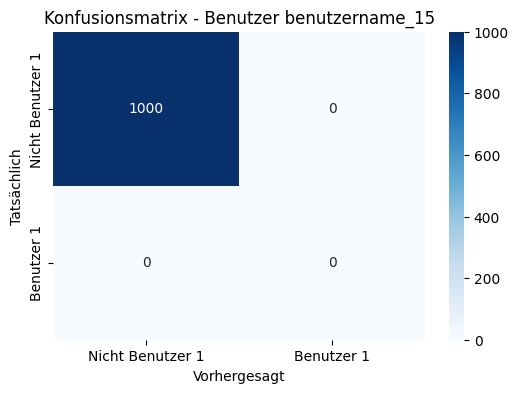

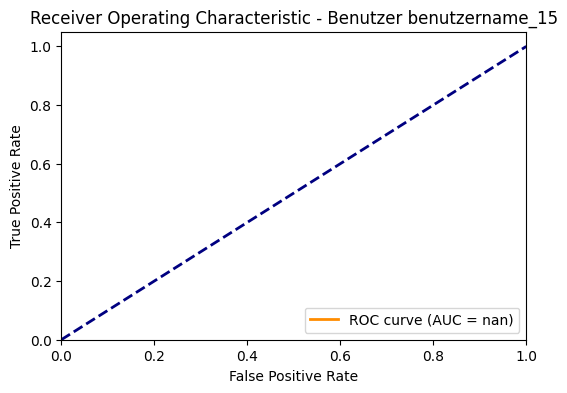

Ergebnisse für Benutzer benutzername_15:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  15%|█▌        | 3/20 [00:09<00:51,  3.06s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


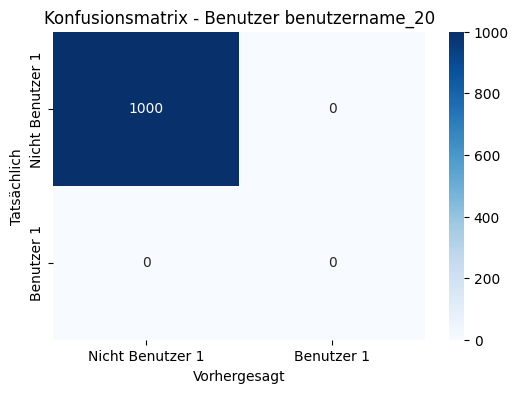

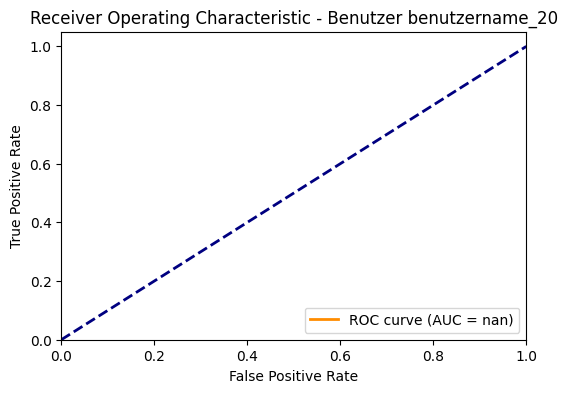

Ergebnisse für Benutzer benutzername_20:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  20%|██        | 4/20 [00:12<00:48,  3.04s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


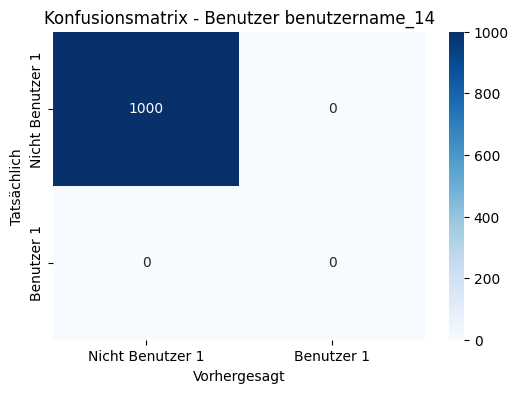

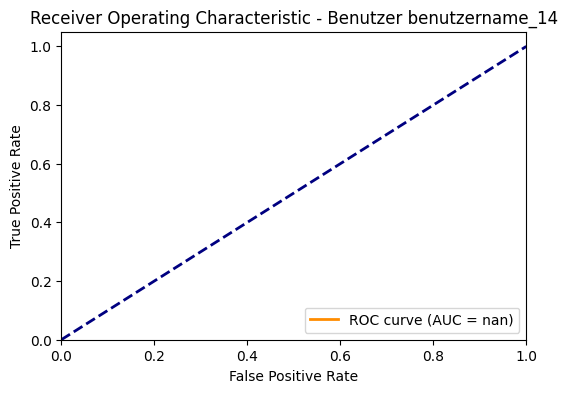

Ergebnisse für Benutzer benutzername_14:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  25%|██▌       | 5/20 [00:15<00:45,  3.04s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


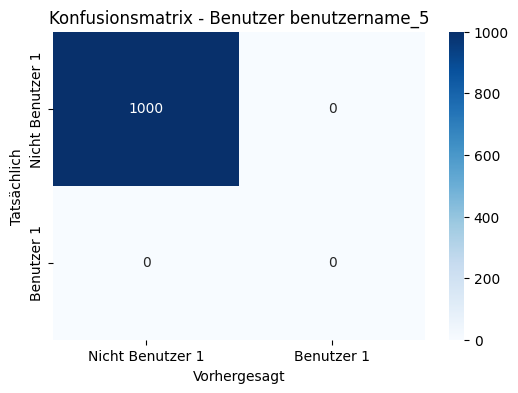

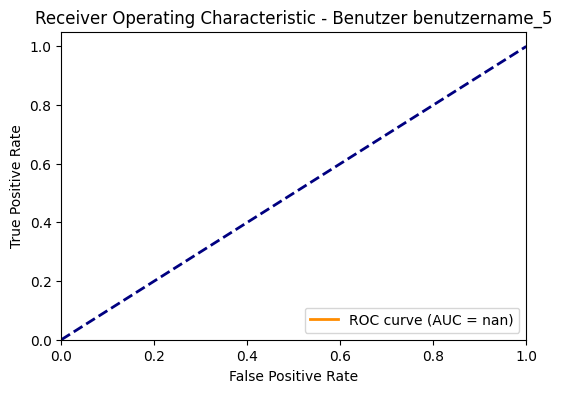

Ergebnisse für Benutzer benutzername_5:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  30%|███       | 6/20 [00:18<00:42,  3.04s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


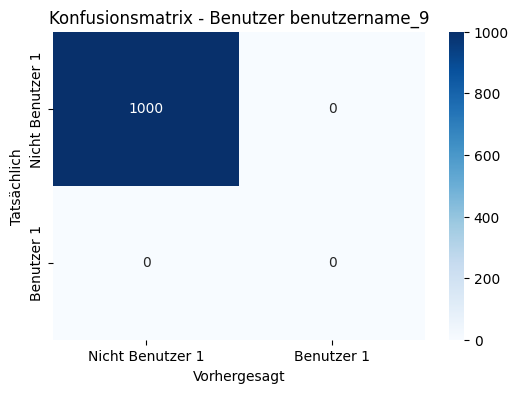

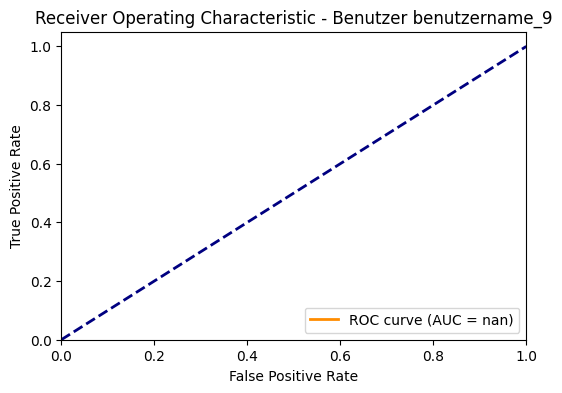

Ergebnisse für Benutzer benutzername_9:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  35%|███▌      | 7/20 [00:21<00:39,  3.04s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


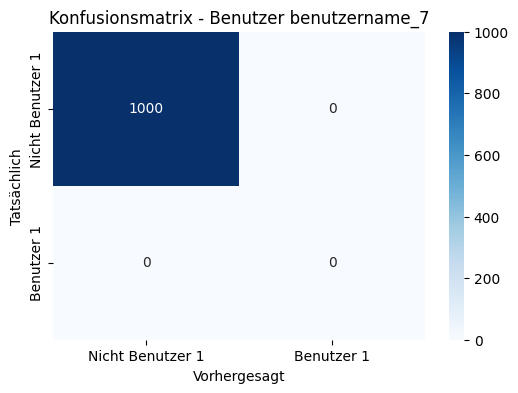

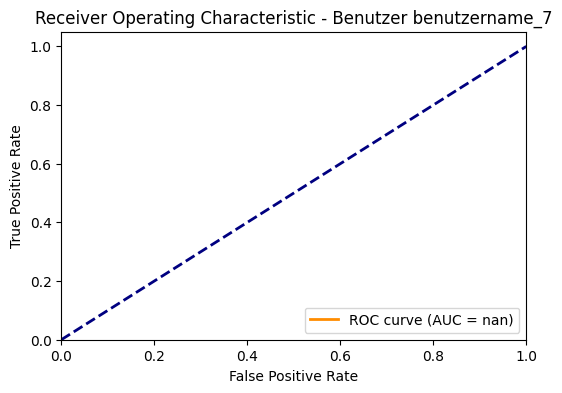

Ergebnisse für Benutzer benutzername_7:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  40%|████      | 8/20 [00:24<00:36,  3.04s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


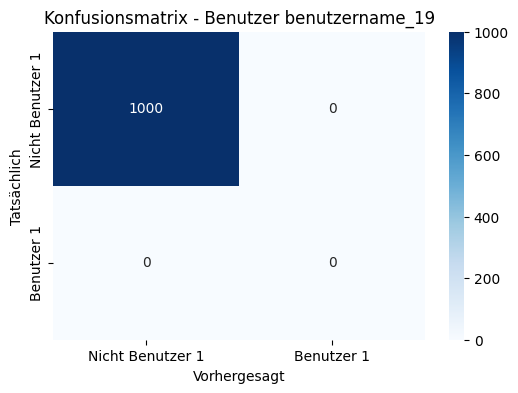

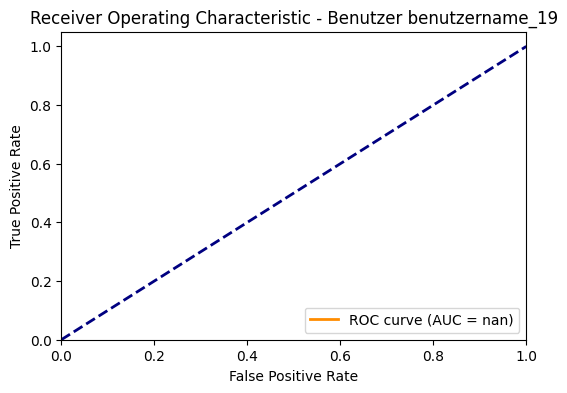

Ergebnisse für Benutzer benutzername_19:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  45%|████▌     | 9/20 [00:27<00:33,  3.03s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


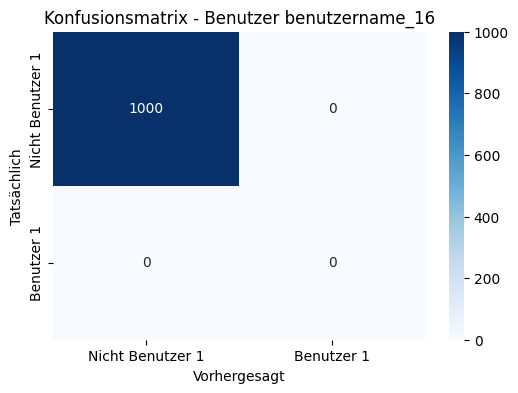

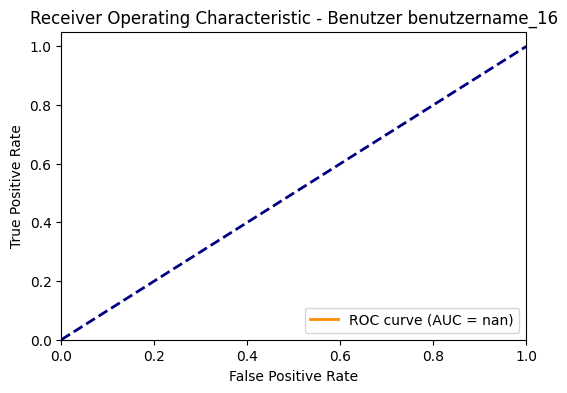

Evaluating Users:  50%|█████     | 10/20 [00:30<00:30,  3.05s/it]

Ergebnisse für Benutzer benutzername_16:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


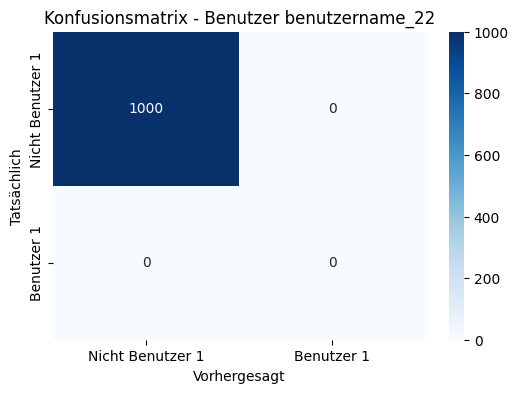

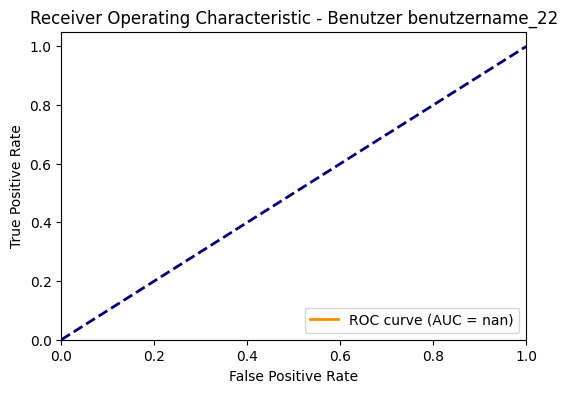

Ergebnisse für Benutzer benutzername_22:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  55%|█████▌    | 11/20 [00:33<00:27,  3.06s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


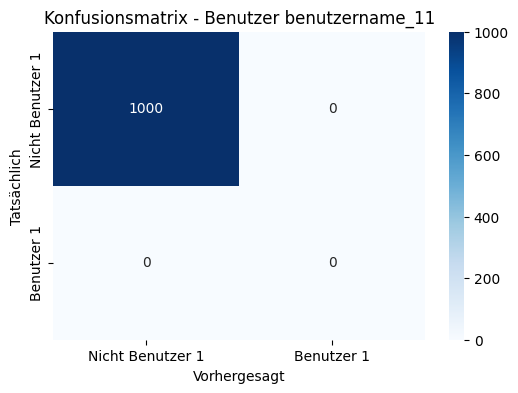

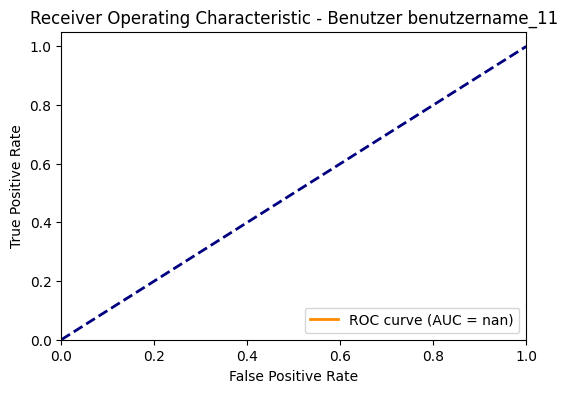

Evaluating Users:  60%|██████    | 12/20 [00:36<00:24,  3.06s/it]

Ergebnisse für Benutzer benutzername_11:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


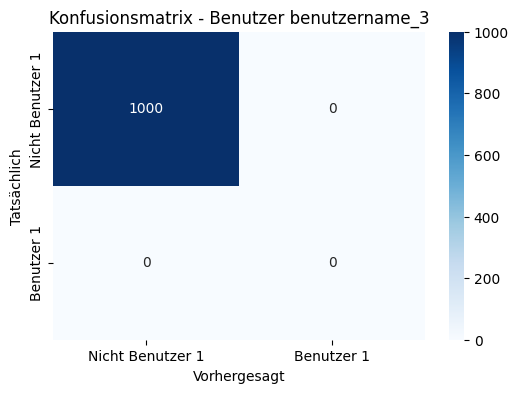

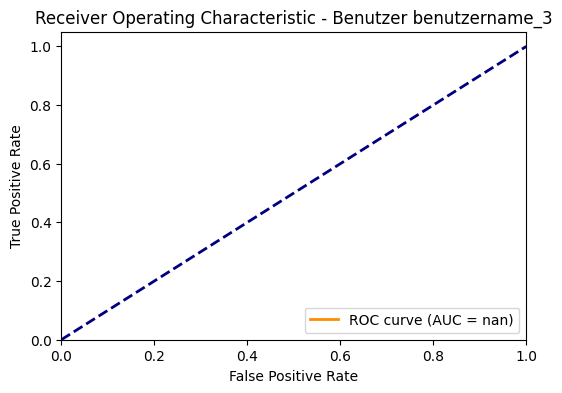

Evaluating Users:  65%|██████▌   | 13/20 [00:39<00:21,  3.07s/it]

Ergebnisse für Benutzer benutzername_3:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


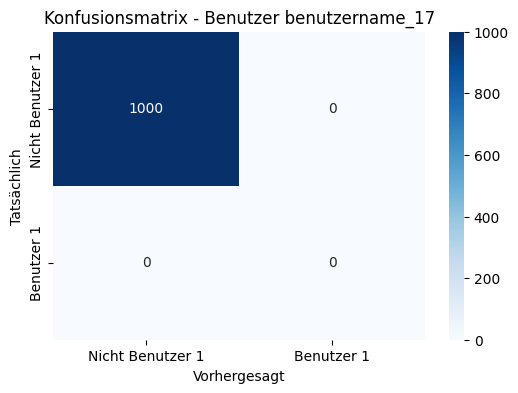

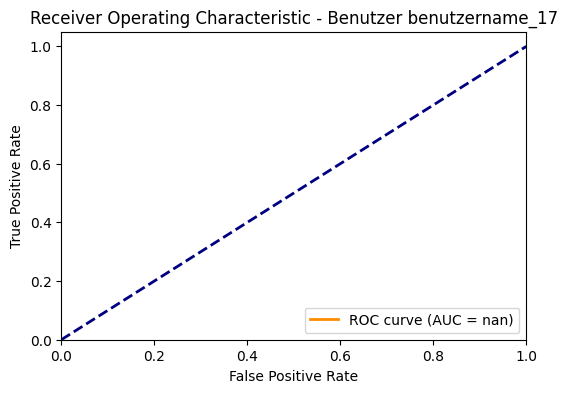

Evaluating Users:  70%|███████   | 14/20 [00:42<00:18,  3.07s/it]

Ergebnisse für Benutzer benutzername_17:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


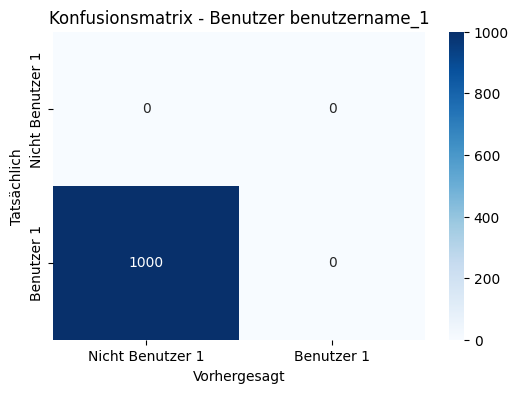

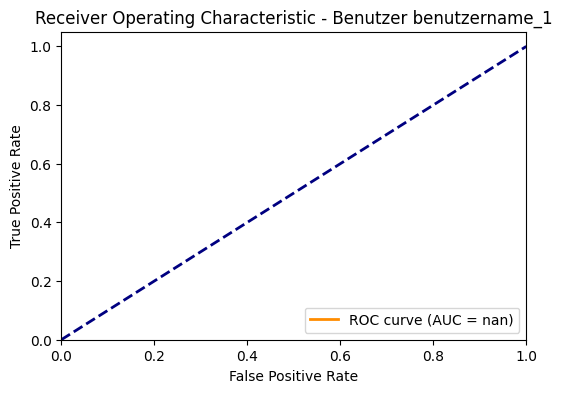

Ergebnisse für Benutzer benutzername_1:
                  precision    recall  f1-score   support

Nicht Benutzer 1       0.00      0.00      0.00       0.0
      Benutzer 1       0.00      0.00      0.00    1000.0

        accuracy                           0.00    1000.0
       macro avg       0.00      0.00      0.00    1000.0
    weighted avg       0.00      0.00      0.00    1000.0

ROC AUC: nan



Evaluating Users:  75%|███████▌  | 15/20 [00:45<00:15,  3.06s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


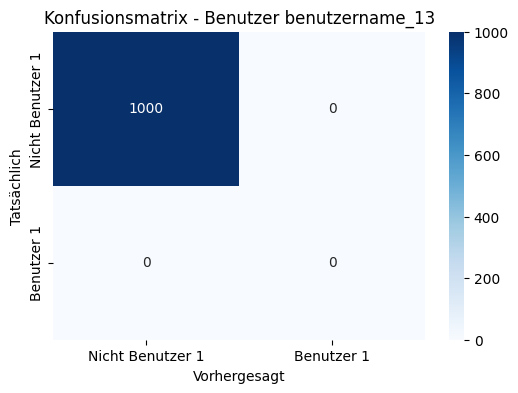

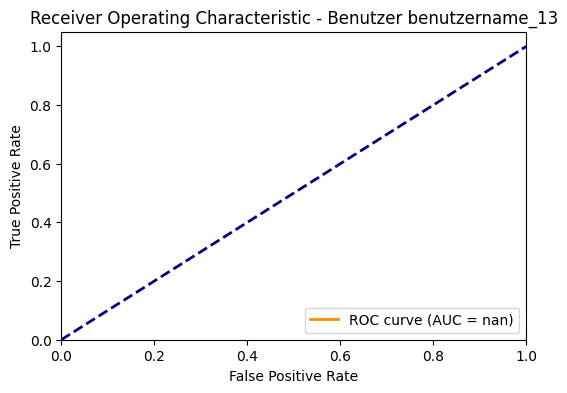

Evaluating Users:  80%|████████  | 16/20 [00:48<00:12,  3.06s/it]

Ergebnisse für Benutzer benutzername_13:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


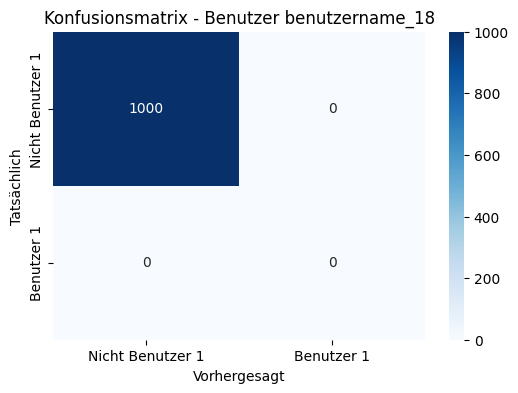

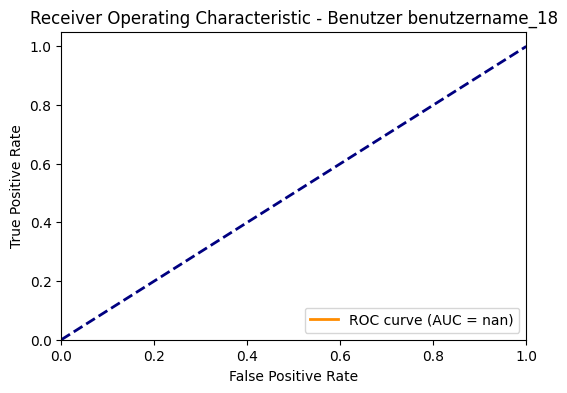

Ergebnisse für Benutzer benutzername_18:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  85%|████████▌ | 17/20 [00:51<00:09,  3.05s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


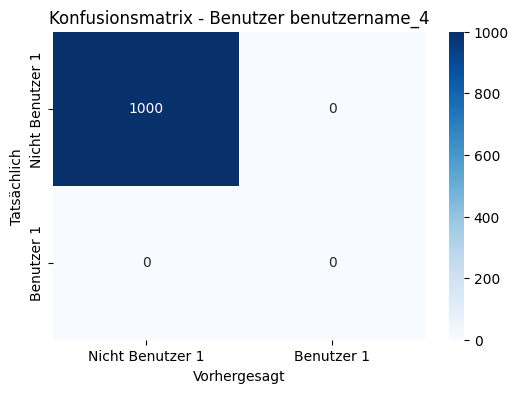

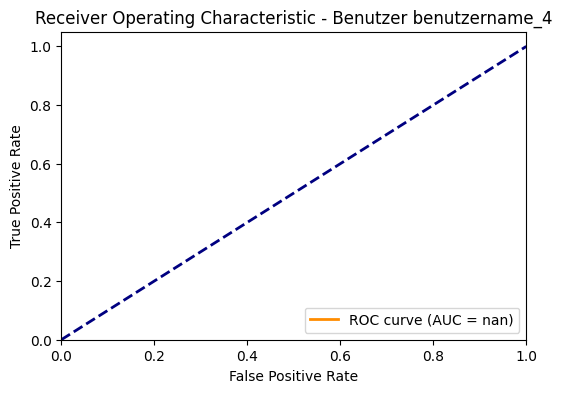

Ergebnisse für Benutzer benutzername_4:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  90%|█████████ | 18/20 [00:54<00:06,  3.05s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


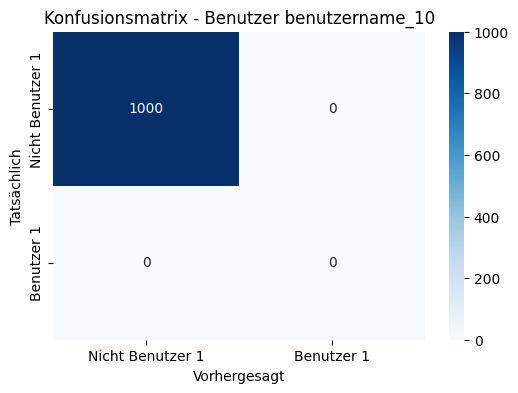

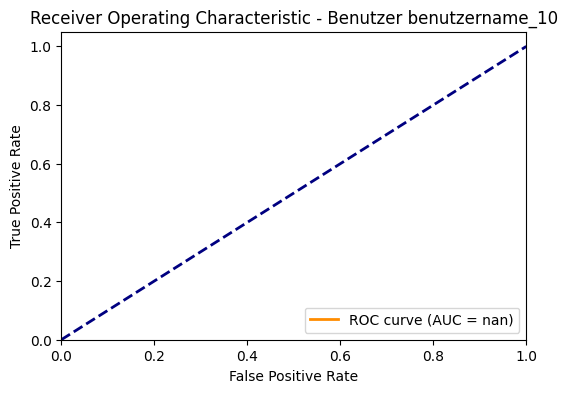

Ergebnisse für Benutzer benutzername_10:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  95%|█████████▌| 19/20 [00:58<00:03,  3.06s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


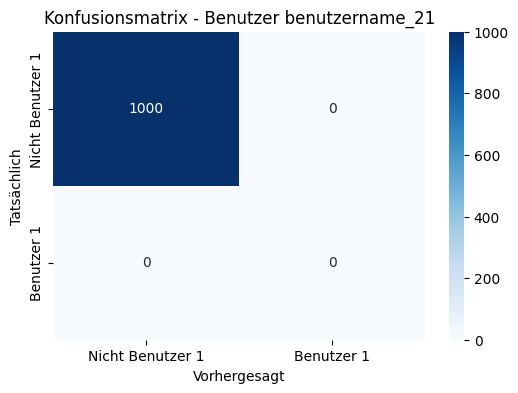

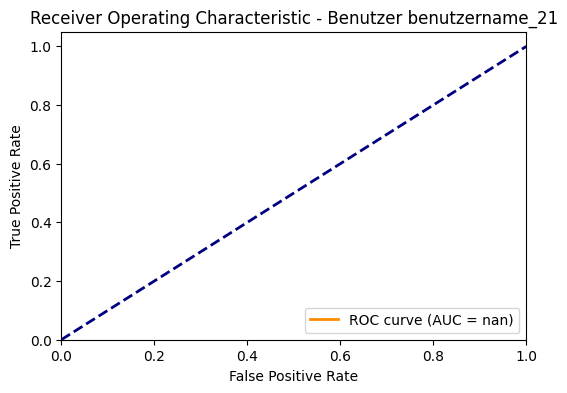

Ergebnisse für Benutzer benutzername_21:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users: 100%|██████████| 20/20 [01:01<00:00,  3.05s/it]

Evaluation abgeschlossen.


In [95]:
# Zelle Z: Modell Evaluation durchführen (Überarbeitet)
print("Starte Modell Evaluation auf Testdaten...")

# Stellen Sie sicher, dass 'test_df' korrekt definiert ist und Ihre Testdaten enthält
evaluation_results = evaluate_model_per_user(
    model=model,
    df=test_df,
    example_user_id=example_user_id,
    samples_per_user=1000,
    target_size=(64, 64)
)

print("Evaluation abgeschlossen.")

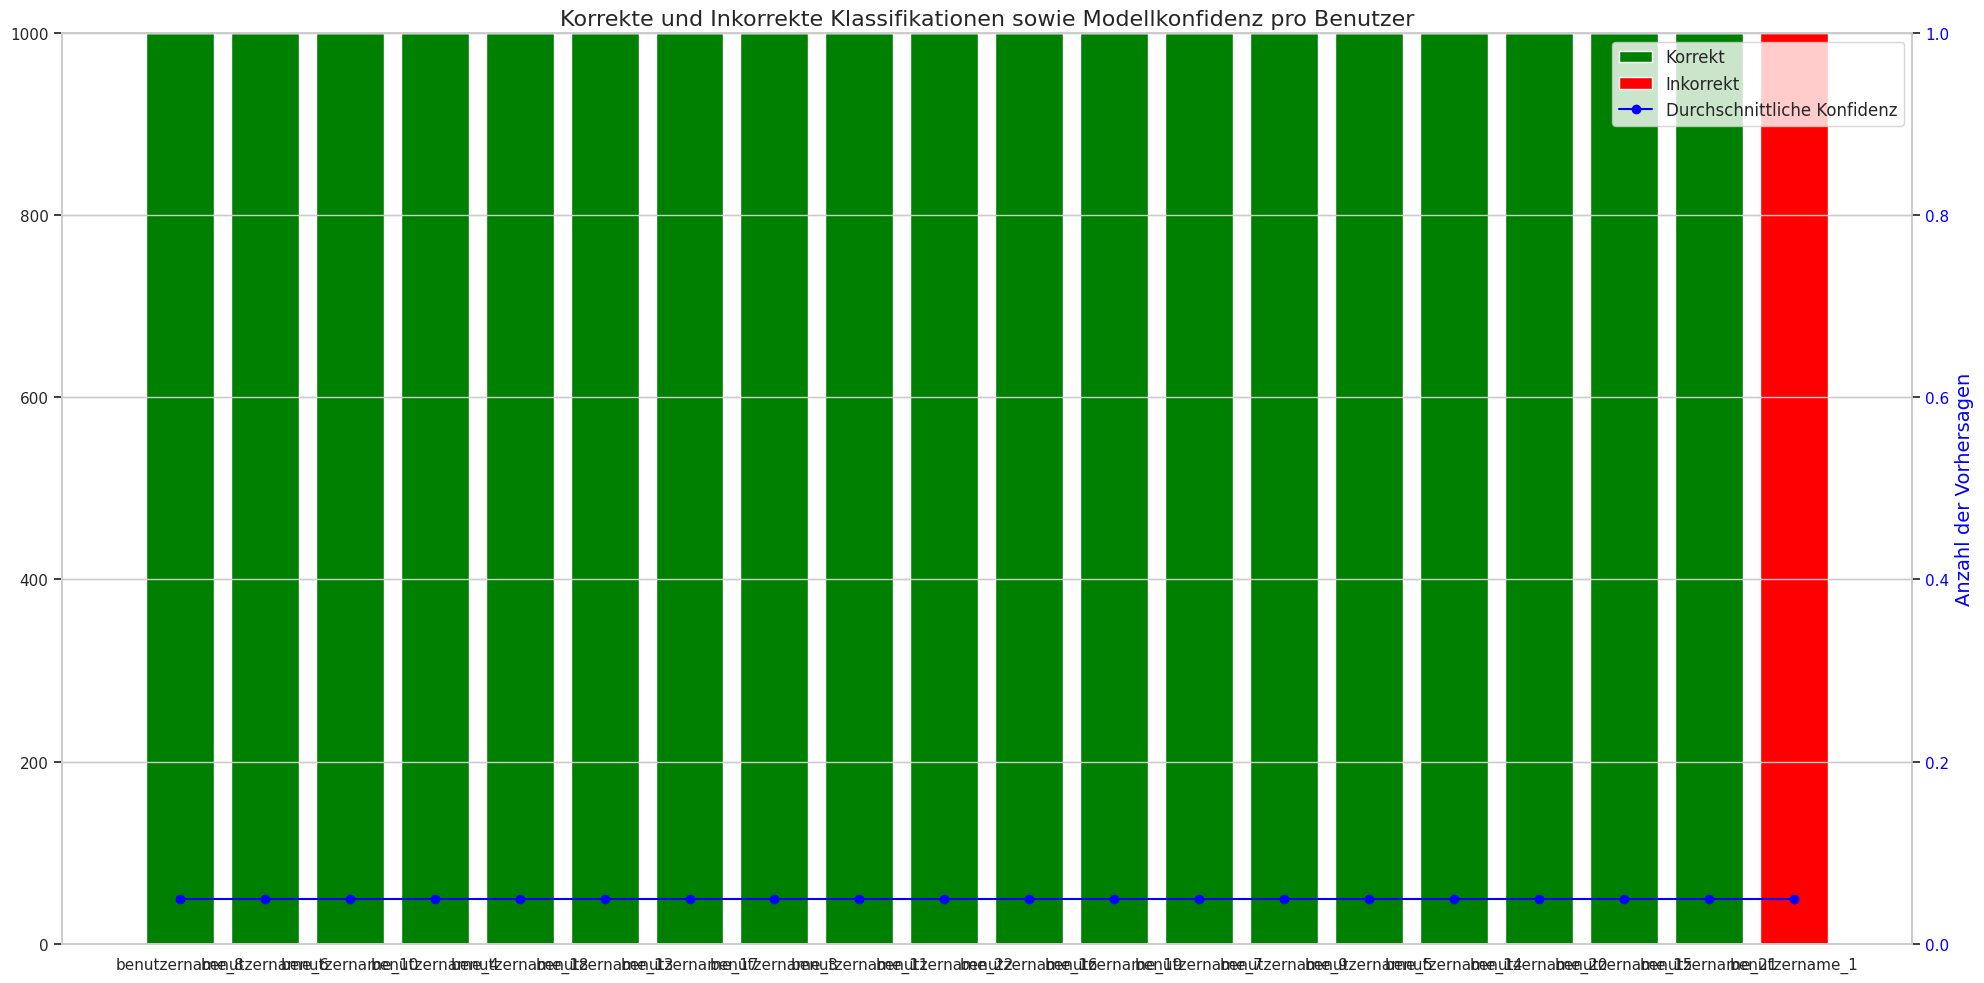

In [96]:
# Zelle AB: Visualisierung der korrekten und inkorrekten Klassifikationen sowie der Modellkonfidenz pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie Listen zur Speicherung der Daten
users = []
correct = []
incorrect = []
confidence = []

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user, metrics in evaluation_results.items():
    conf_matrix = metrics['conf_matrix']
    
    # Initialisieren der Zähler
    correct_count = 0
    incorrect_count = 0
    
    # Überprüfen der Form der Konfusionsmatrix
    if conf_matrix.shape == (2, 2):
        tn, fp, fn, tp = conf_matrix.ravel()
        correct_count = tn + tp
        incorrect_count = fp + fn
    elif conf_matrix.shape == (1, 2):
        tn, fp = conf_matrix.ravel()
        correct_count = tn
        incorrect_count = fp
    elif conf_matrix.shape == (2, 1):
        fn, tp = conf_matrix.ravel()
        correct_count = tp
        incorrect_count = fn
    else:
        print(f"Unerwartetes Format der Konfusionsmatrix für Benutzer {user}.")
        continue
    
    # Durchschnittliche Konfidenz berechnen
    avg_confidence = np.mean(metrics['y_pred'])
    
    # Daten speichern
    users.append(user)
    correct.append(correct_count)
    incorrect.append(incorrect_count)
    confidence.append(avg_confidence)

# Erstellen eines DataFrames
data = pd.DataFrame({
    'Benutzer': users,
    'Korrekt': correct,
    'Inkorrekt': incorrect,
    'Durchschnittliche Konfidenz': confidence
})

# Sortieren der Benutzer nach korrekten Vorhersagen (optional)
data = data.sort_values(by='Korrekt', ascending=False)

# Setze den Stil von Seaborn
sns.set(style="whitegrid")

# Erstellen des gestapelten Balkendiagramms
plt.figure(figsize=(20, 10))

# Balken für korrekte und inkorrekte Vorhersagen
bar_correct = plt.bar(data['Benutzer'], data['Korrekt'], color='green', label='Korrekt')
bar_incorrect = plt.bar(data['Benutzer'], data['Inkorrekt'], bottom=data['Korrekt'], color='red', label='Inkorrekt')

# Linienachse für die durchschnittliche Konfidenz
ax2 = plt.twinx()
ax2.plot(data['Benutzer'], data['Durchschnittliche Konfidenz'], color='blue', marker='o', label='Durchschnittliche Konfidenz')
ax2.set_ylabel('Durchschnittliche Konfidenz', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 1)  # Da Konfidenzwerte zwischen 0 und 1 liegen

# Beschriftungen und Titel
plt.xlabel('Benutzer', fontsize=14)
plt.ylabel('Anzahl der Vorhersagen', fontsize=14)
plt.title('Korrekte und Inkorrekte Klassifikationen sowie Modellkonfidenz pro Benutzer', fontsize=16)

# Legenden
fig = plt.gcf()
handles1, labels1 = fig.axes[0].get_legend_handles_labels()
handles2, labels2 = fig.axes[1].get_legend_handles_labels()
plt.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc='upper right', fontsize=12)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(rotation=90, fontsize=12)

plt.tight_layout()
plt.show()

In [98]:
# Zelle Y: Evaluation Funktion definieren (Überarbeitet)

def evaluate_model_per_user(model, df, example_user_id, samples_per_user=1000, target_size=(64, 64)):
    unique_users = df['username'].unique()
    results = {}
    
    print("Starte Evaluation für jeden Benutzer...")
    
    for user in tqdm(unique_users, desc="Evaluating Users"):
        # Anzahl der verfügbaren Samples für den Benutzer
        available_samples = len(df[df['username'] == user])
        num_samples = min(samples_per_user, available_samples)
        
        # Zufälliges Sampling
        user_df = df[df['username'] == user].sample(n=num_samples, random_state=42)
        
        X = []
        y = []
        
        for _, row in user_df.iterrows():
            img = process_image(row['sampleData'], target_size)
            if img is not None:
                X.append(img)
                label = 1 if user == example_user_id else 0
                y.append(label)
        
        if len(X) == 0:
            print(f"Keine gültigen Bilder für Benutzer {user}. Überspringe...")
            continue
        
        X = np.array(X)
        y = np.array(y)
        
        # Vorhersagen generieren
        y_pred_prob = model.predict(X).flatten()  # Wahrscheinlichkeiten
        y_pred_binary = (y_pred_prob > 0.5).astype(int)  # Binäre Labels
        
        # Metriken berechnen
        conf_matrix = confusion_matrix(y, y_pred_binary, labels=[0,1])
        try:
            class_report = classification_report(
                y, 
                y_pred_binary, 
                target_names=["Nicht Benutzer 1", "Benutzer 1"], 
                labels=[0,1], 
                zero_division=0
            )
        except ValueError as ve:
            print(f"Fehler bei der Erstellung des Klassifikationsberichts für Benutzer {user}: {ve}")
            class_report = "Nicht genügend Klassen zur Erstellung des Berichts."
        
        fpr, tpr, _ = roc_curve(y, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        
        # Ergebnisse speichern, inklusive y_pred_prob und y_true
        results[user] = {
            'conf_matrix': conf_matrix,
            'class_report': class_report,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'y_pred_prob': y_pred_prob,  # Speichern der Vorhersage-Wahrscheinlichkeiten
            'y_true': y  # Speichern der wahren Labels
        }
        
        # Konfusionsmatrix visualisieren
        plt.figure(figsize=(6, 4))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=["Nicht Benutzer 1", "Benutzer 1"],
                    yticklabels=["Nicht Benutzer 1", "Benutzer 1"])
        plt.title(f'Konfusionsmatrix - Benutzer {user}')
        plt.xlabel('Vorhergesagt')
        plt.ylabel('Tatsächlich')
        plt.show()
        
        # ROC Kurve visualisieren
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic - Benutzer {user}')
        plt.legend(loc="lower right")
        plt.show()
        
        print(f"Ergebnisse für Benutzer {user}:")
        print(class_report)
        print(f"ROC AUC: {roc_auc:.2f}\n")
        
        # Speicher freigeben
        del X, y, y_pred_prob, y_pred_binary, conf_matrix, class_report, fpr, tpr
        gc.collect()
    
    return results

Starte Modell Evaluation auf Testdaten...
Starte Evaluation für jeden Benutzer...


Evaluating Users:   0%|          | 0/20 [00:00<?, ?it/s]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


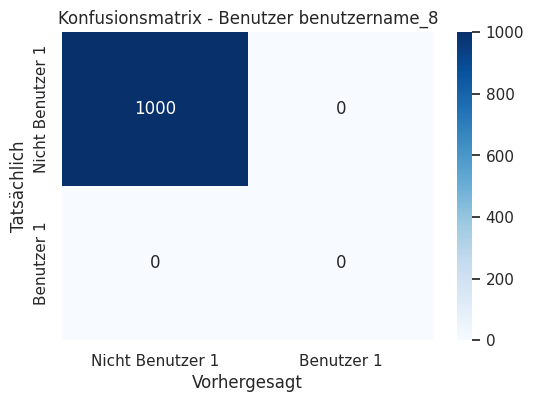

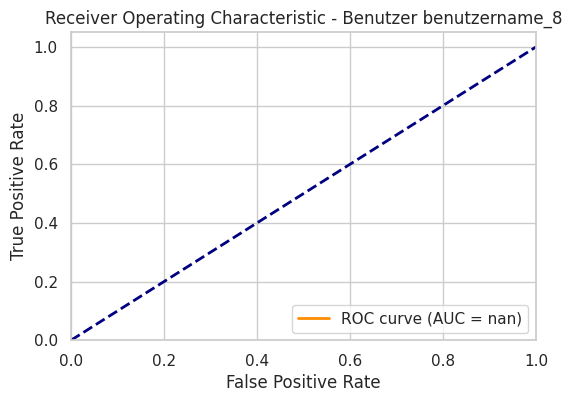

Ergebnisse für Benutzer benutzername_8:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:   5%|▌         | 1/20 [00:03<00:59,  3.13s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


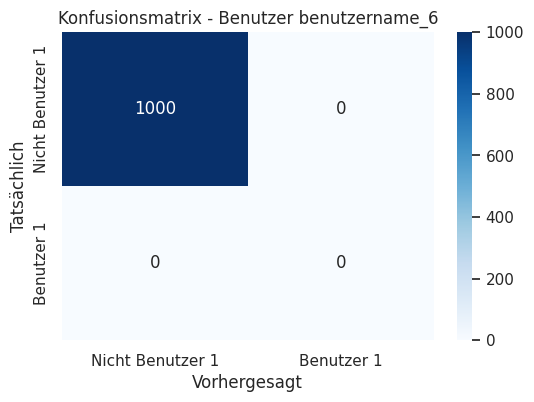

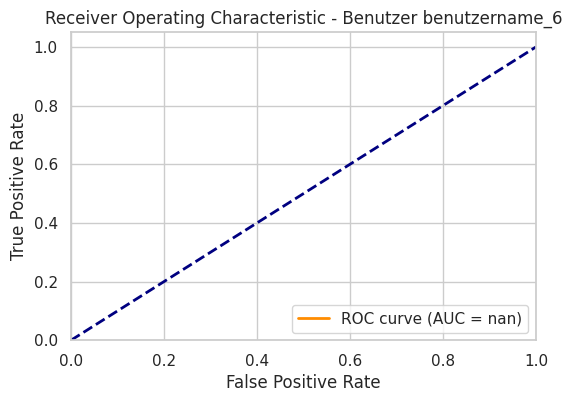

Ergebnisse für Benutzer benutzername_6:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  10%|█         | 2/20 [00:06<00:55,  3.09s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


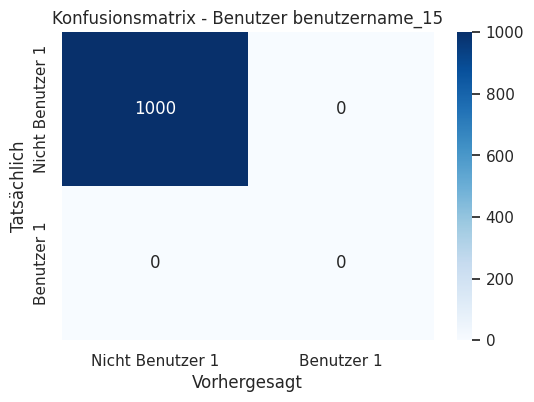

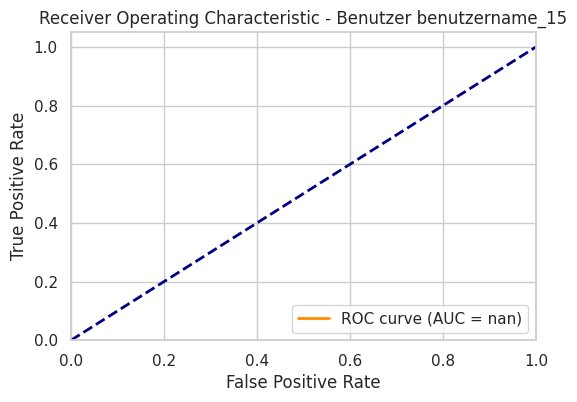

Evaluating Users:  15%|█▌        | 3/20 [00:09<00:52,  3.10s/it]

Ergebnisse für Benutzer benutzername_15:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


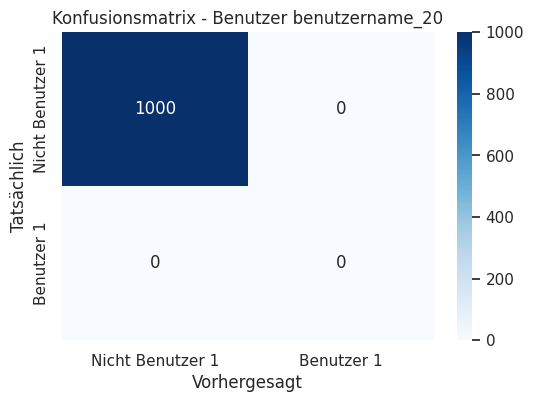

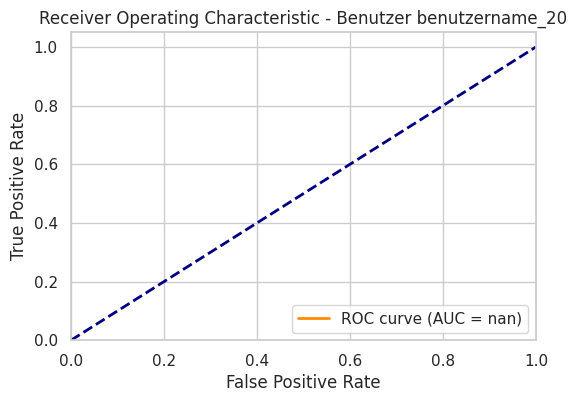

Ergebnisse für Benutzer benutzername_20:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  20%|██        | 4/20 [00:12<00:49,  3.09s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


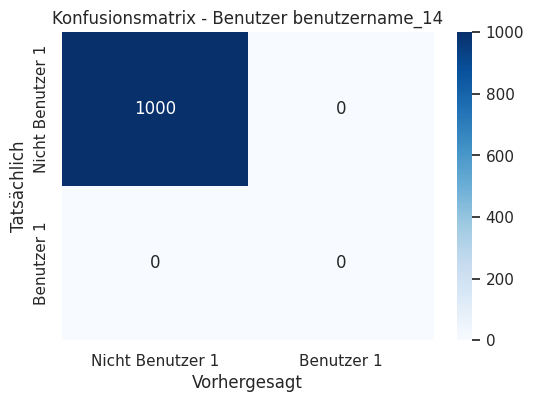

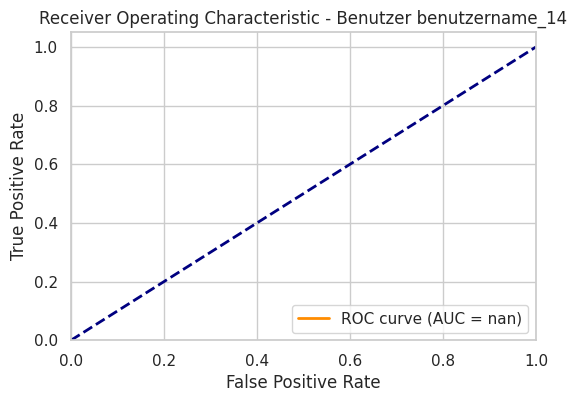

Ergebnisse für Benutzer benutzername_14:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  25%|██▌       | 5/20 [00:15<00:46,  3.09s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


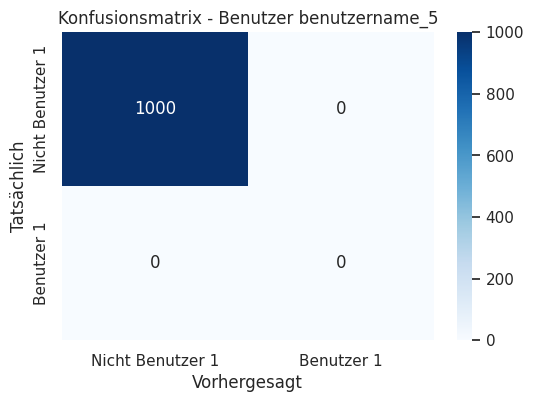

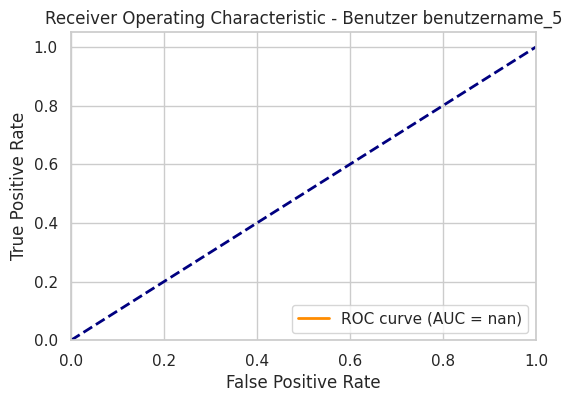

Ergebnisse für Benutzer benutzername_5:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  30%|███       | 6/20 [00:18<00:42,  3.07s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


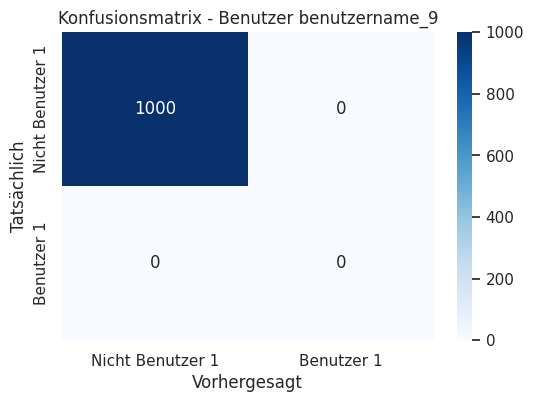

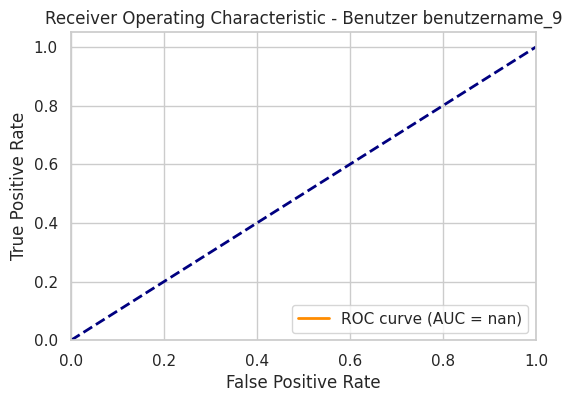

Ergebnisse für Benutzer benutzername_9:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  35%|███▌      | 7/20 [00:21<00:40,  3.08s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


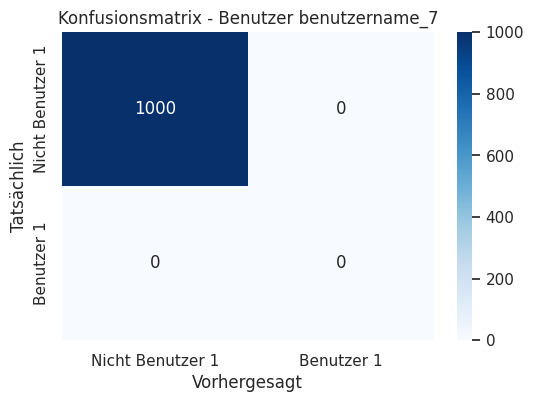

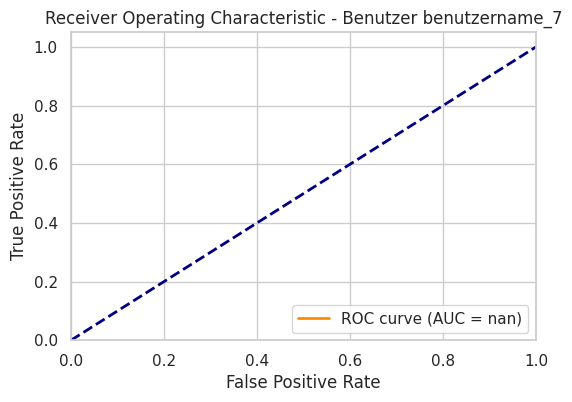

Evaluating Users:  40%|████      | 8/20 [00:24<00:37,  3.10s/it]

Ergebnisse für Benutzer benutzername_7:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


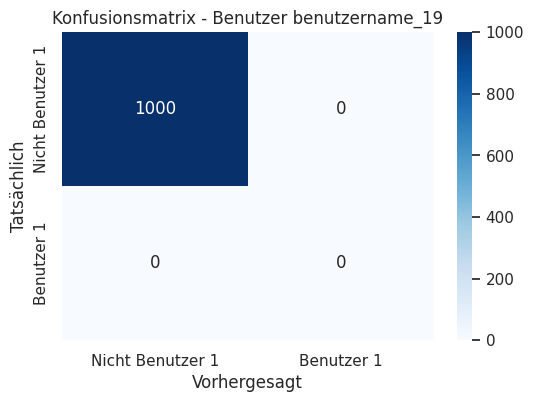

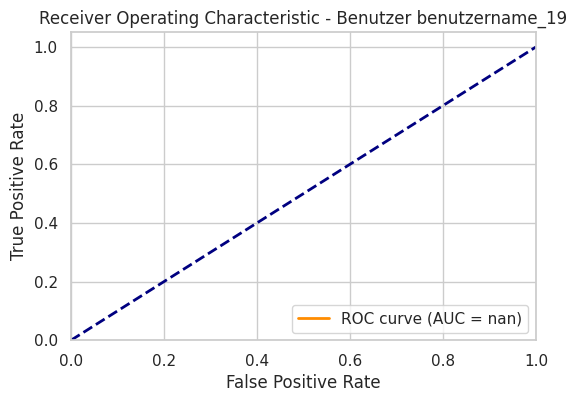

Ergebnisse für Benutzer benutzername_19:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  45%|████▌     | 9/20 [00:27<00:34,  3.10s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


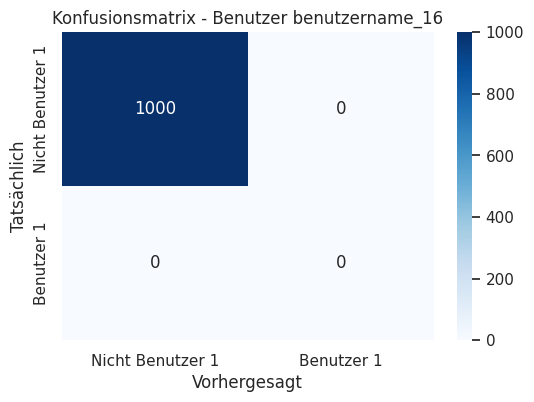

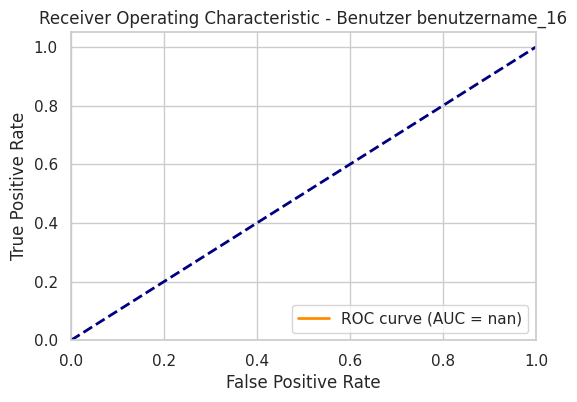

Evaluating Users:  50%|█████     | 10/20 [00:30<00:31,  3.12s/it]

Ergebnisse für Benutzer benutzername_16:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


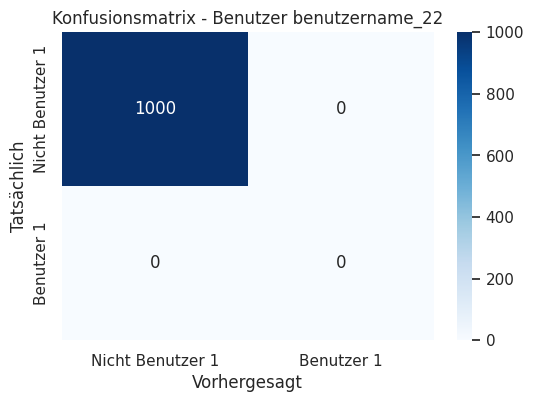

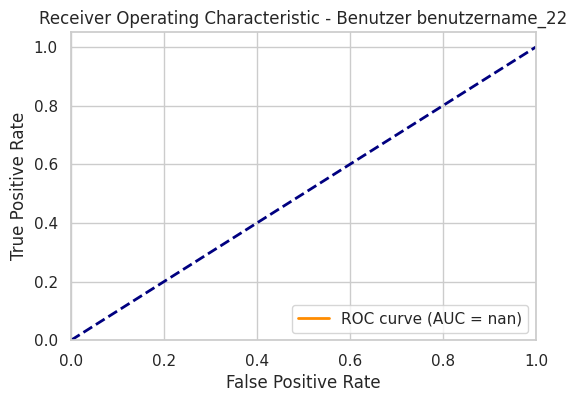

Evaluating Users:  55%|█████▌    | 11/20 [00:34<00:28,  3.13s/it]

Ergebnisse für Benutzer benutzername_22:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


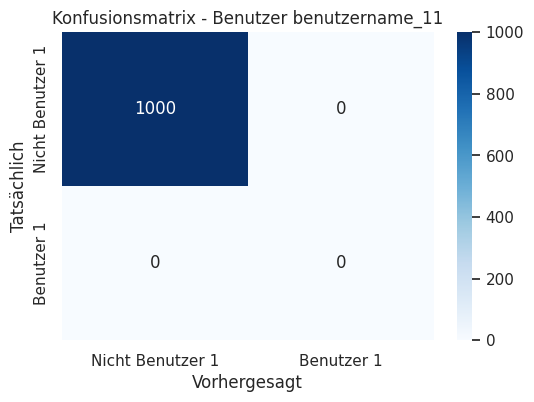

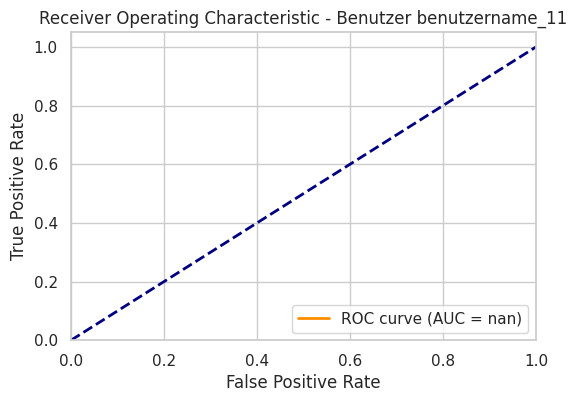

Evaluating Users:  60%|██████    | 12/20 [00:37<00:24,  3.12s/it]

Ergebnisse für Benutzer benutzername_11:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


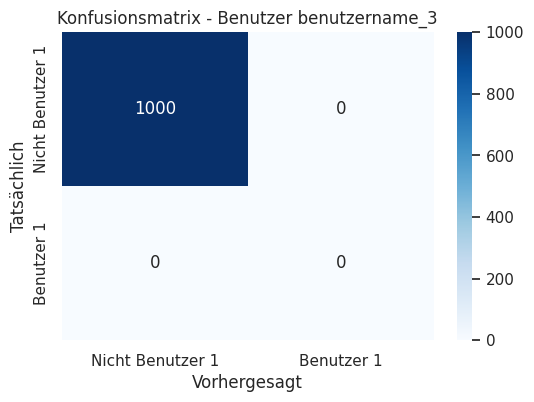

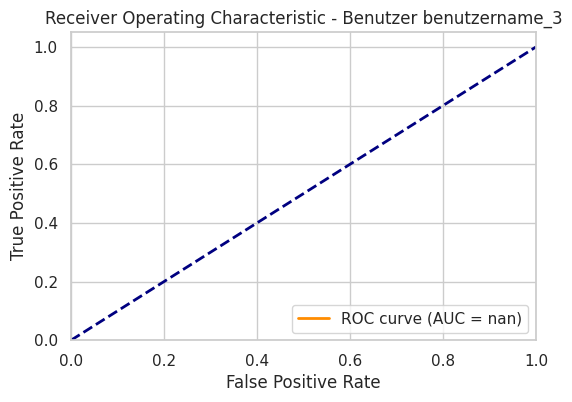

Ergebnisse für Benutzer benutzername_3:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  65%|██████▌   | 13/20 [00:40<00:21,  3.13s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


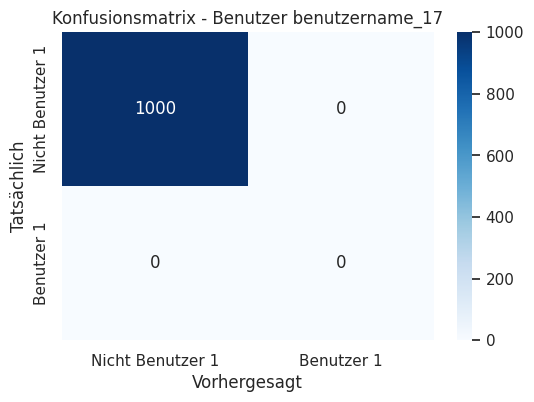

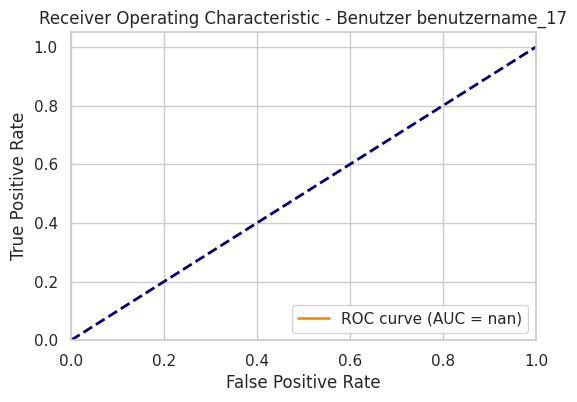

Ergebnisse für Benutzer benutzername_17:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  70%|███████   | 14/20 [00:43<00:18,  3.12s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1124: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


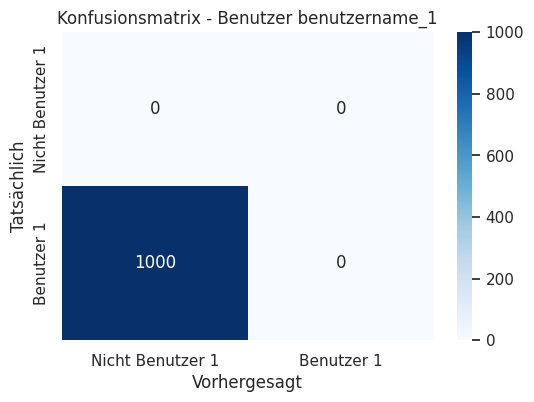

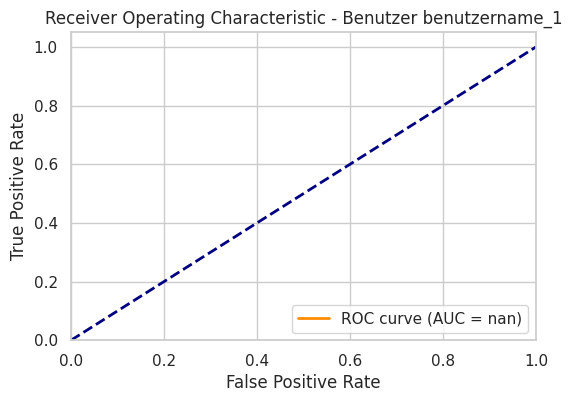

Evaluating Users:  75%|███████▌  | 15/20 [00:46<00:15,  3.11s/it]

Ergebnisse für Benutzer benutzername_1:
                  precision    recall  f1-score   support

Nicht Benutzer 1       0.00      0.00      0.00       0.0
      Benutzer 1       0.00      0.00      0.00    1000.0

        accuracy                           0.00    1000.0
       macro avg       0.00      0.00      0.00    1000.0
    weighted avg       0.00      0.00      0.00    1000.0

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


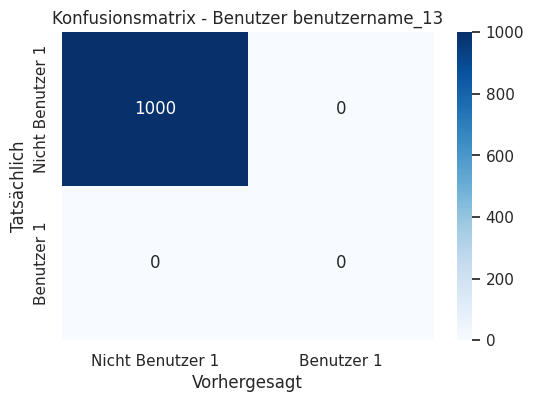

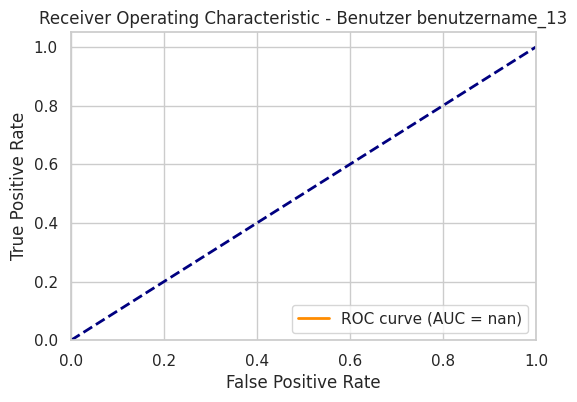

Ergebnisse für Benutzer benutzername_13:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  80%|████████  | 16/20 [00:49<00:12,  3.09s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


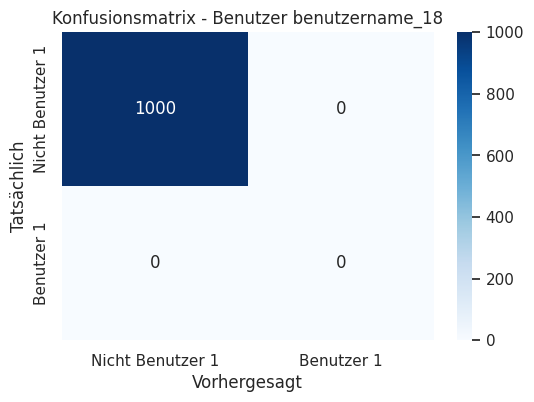

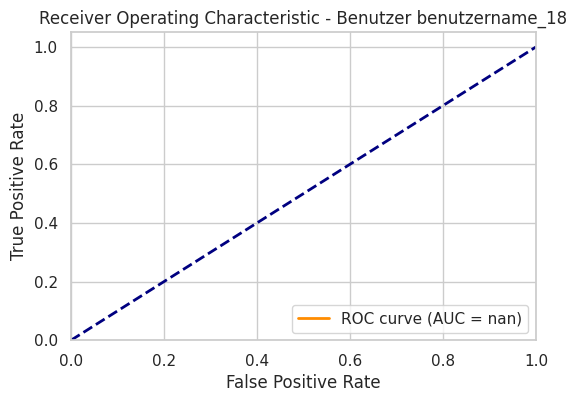

Evaluating Users:  85%|████████▌ | 17/20 [00:52<00:09,  3.07s/it]

Ergebnisse für Benutzer benutzername_18:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


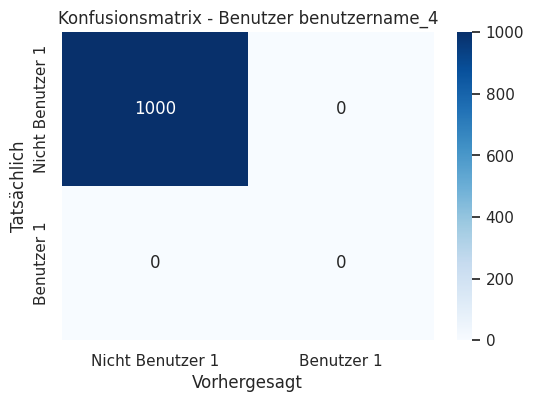

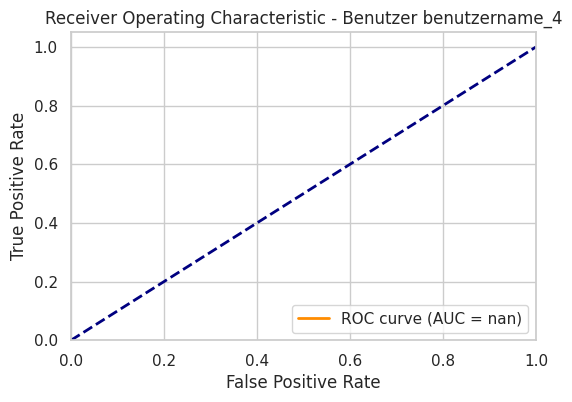

Ergebnisse für Benutzer benutzername_4:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  90%|█████████ | 18/20 [00:55<00:06,  3.07s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


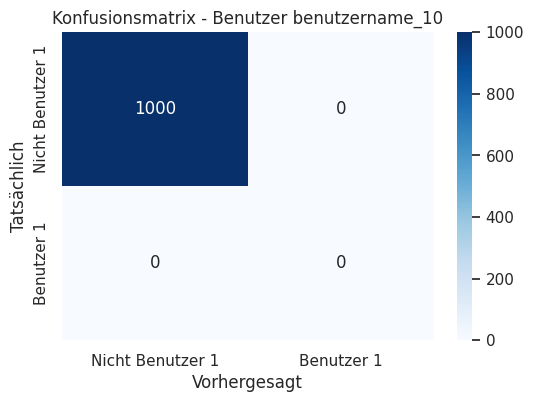

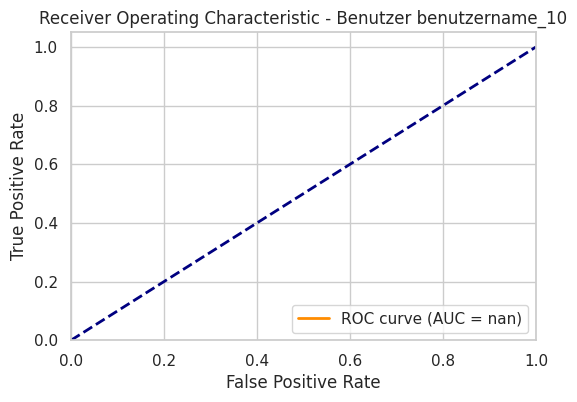

Ergebnisse für Benutzer benutzername_10:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users:  95%|█████████▌| 19/20 [00:58<00:03,  3.08s/it]

32/32 [==============================] - 0s 1ms/step


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


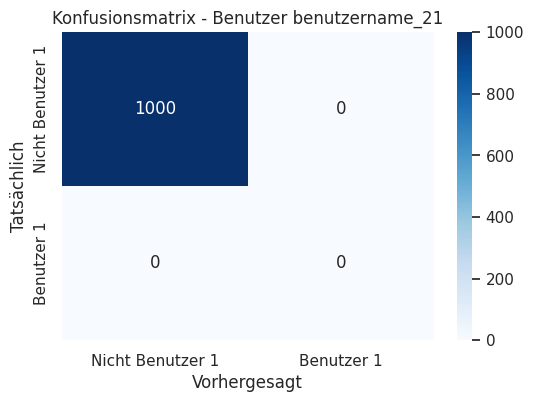

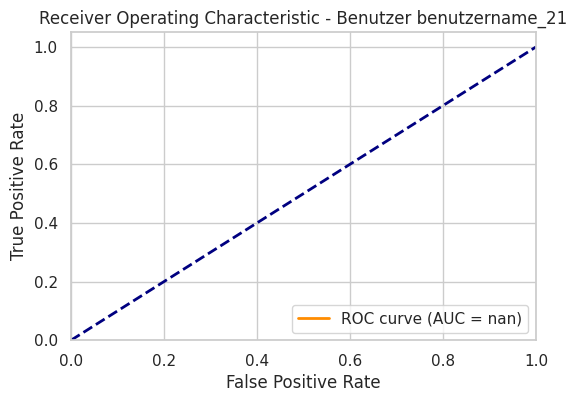

Ergebnisse für Benutzer benutzername_21:
                  precision    recall  f1-score   support

Nicht Benutzer 1       1.00      1.00      1.00      1000
      Benutzer 1       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00      1000
       macro avg       0.50      0.50      0.50      1000
    weighted avg       1.00      1.00      1.00      1000

ROC AUC: nan



Evaluating Users: 100%|██████████| 20/20 [01:01<00:00,  3.10s/it]

Evaluation abgeschlossen.


In [99]:
# Zelle Z: Modell Evaluation durchführen (Überarbeitet)
print("Starte Modell Evaluation auf Testdaten...")

# Stellen Sie sicher, dass 'test_df' korrekt definiert ist und Ihre Testdaten enthält
evaluation_results = evaluate_model_per_user(
    model=model,
    df=test_df,
    example_user_id=example_user_id,
    samples_per_user=1000,  # Anzahl der Samples pro Benutzer
    target_size=(64, 64)  # Bildgröße
)

print("Evaluation abgeschlossen.")

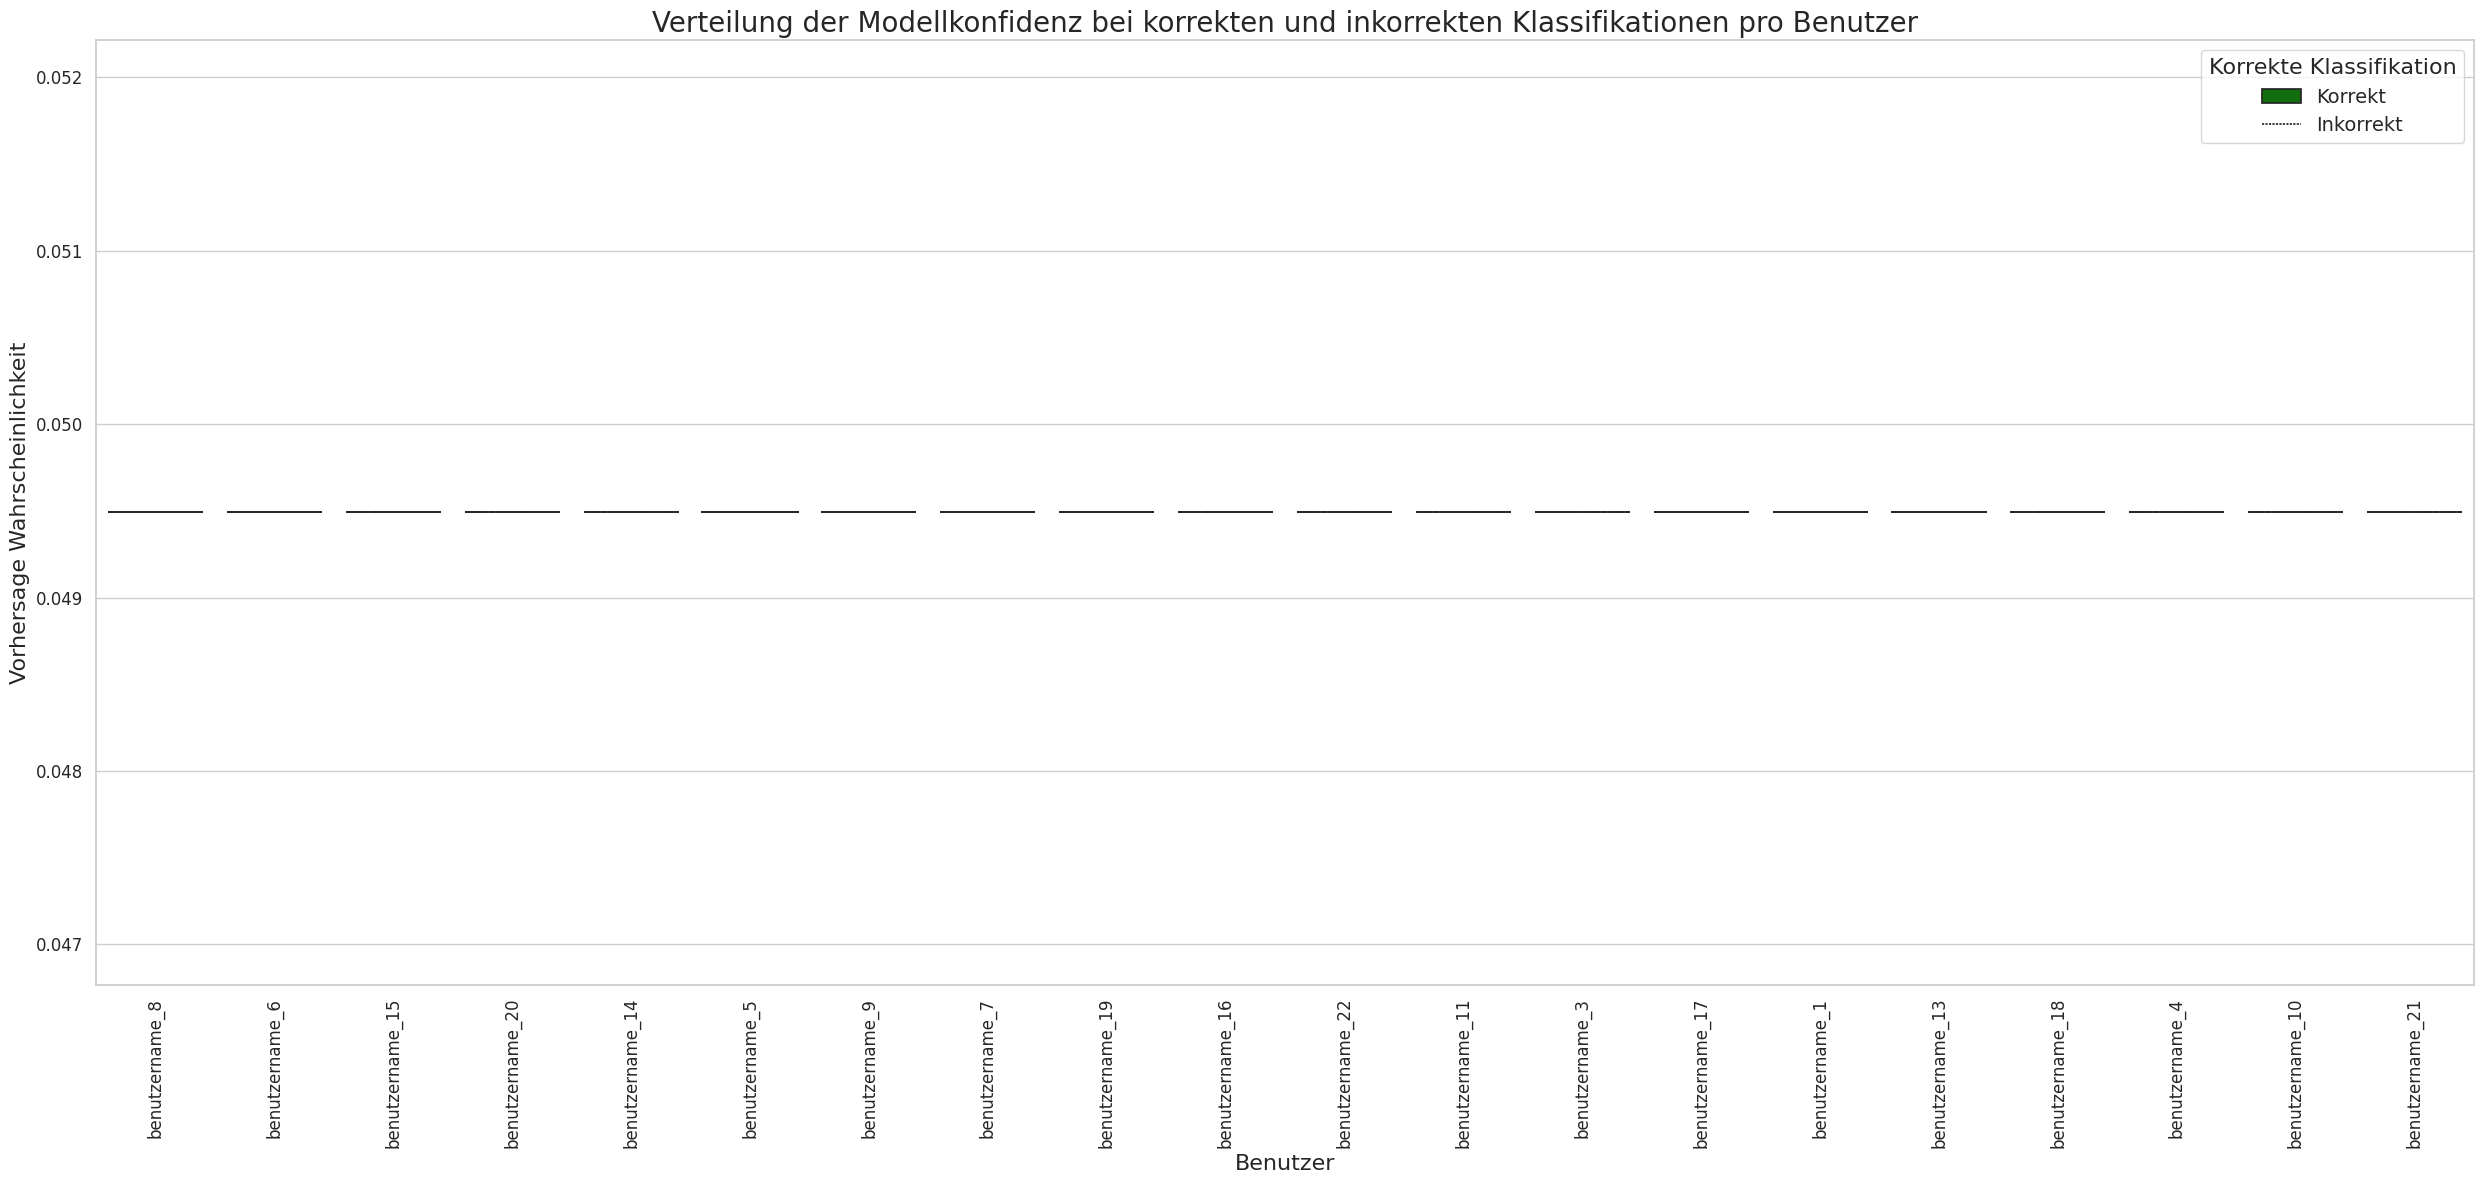

In [100]:
# Zelle AB: Visualisierung der Modellkonfidenz pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie eine Liste zur Speicherung der Daten
data_records = []

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user, metrics in evaluation_results.items():
    y_pred_prob = metrics.get('y_pred_prob', [])
    y_true = metrics.get('y_true', [])
    
    if len(y_pred_prob) == 0 or len(y_true) == 0:
        print(f"Keine Vorhersagen oder wahren Labels für Benutzer {user}.")
        continue
    
    # Durchlaufen Sie alle Vorhersagen und speichern Sie die relevanten Informationen
    for i in range(len(y_pred_prob)):
        pred_prob = y_pred_prob[i]
        pred_label = 1 if pred_prob > 0.5 else 0
        true_label = y_true[i]
        is_correct = pred_label == true_label
        data_records.append({
            'Benutzer': user,
            'Vorhersage_Probabilität': pred_prob,
            'Korrekt': is_correct
        })

# Erstellen eines DataFrames
data = pd.DataFrame(data_records)

# Setze den Stil von Seaborn
sns.set(style="whitegrid")

# Erstellen des Violinplots zur Darstellung der Konfidenzverteilung
plt.figure(figsize=(25, 12))  # Größere Abbildung für bessere Lesbarkeit

sns.violinplot(
    x='Benutzer',
    y='Vorhersage_Probabilität',
    hue='Korrekt',
    data=data,
    split=True,
    palette={True: 'green', False: 'red'},
    inner='quartile'
)

# Anpassen der Beschriftungen und Titel
plt.xlabel('Benutzer', fontsize=16)
plt.ylabel('Vorhersage Wahrscheinlichkeit', fontsize=16)
plt.title('Verteilung der Modellkonfidenz bei korrekten und inkorrekten Klassifikationen pro Benutzer', fontsize=20)

# Anpassung der Legende
plt.legend(title='Korrekte Klassifikation', labels=['Korrekt', 'Inkorrekt'], fontsize=14, title_fontsize=16)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

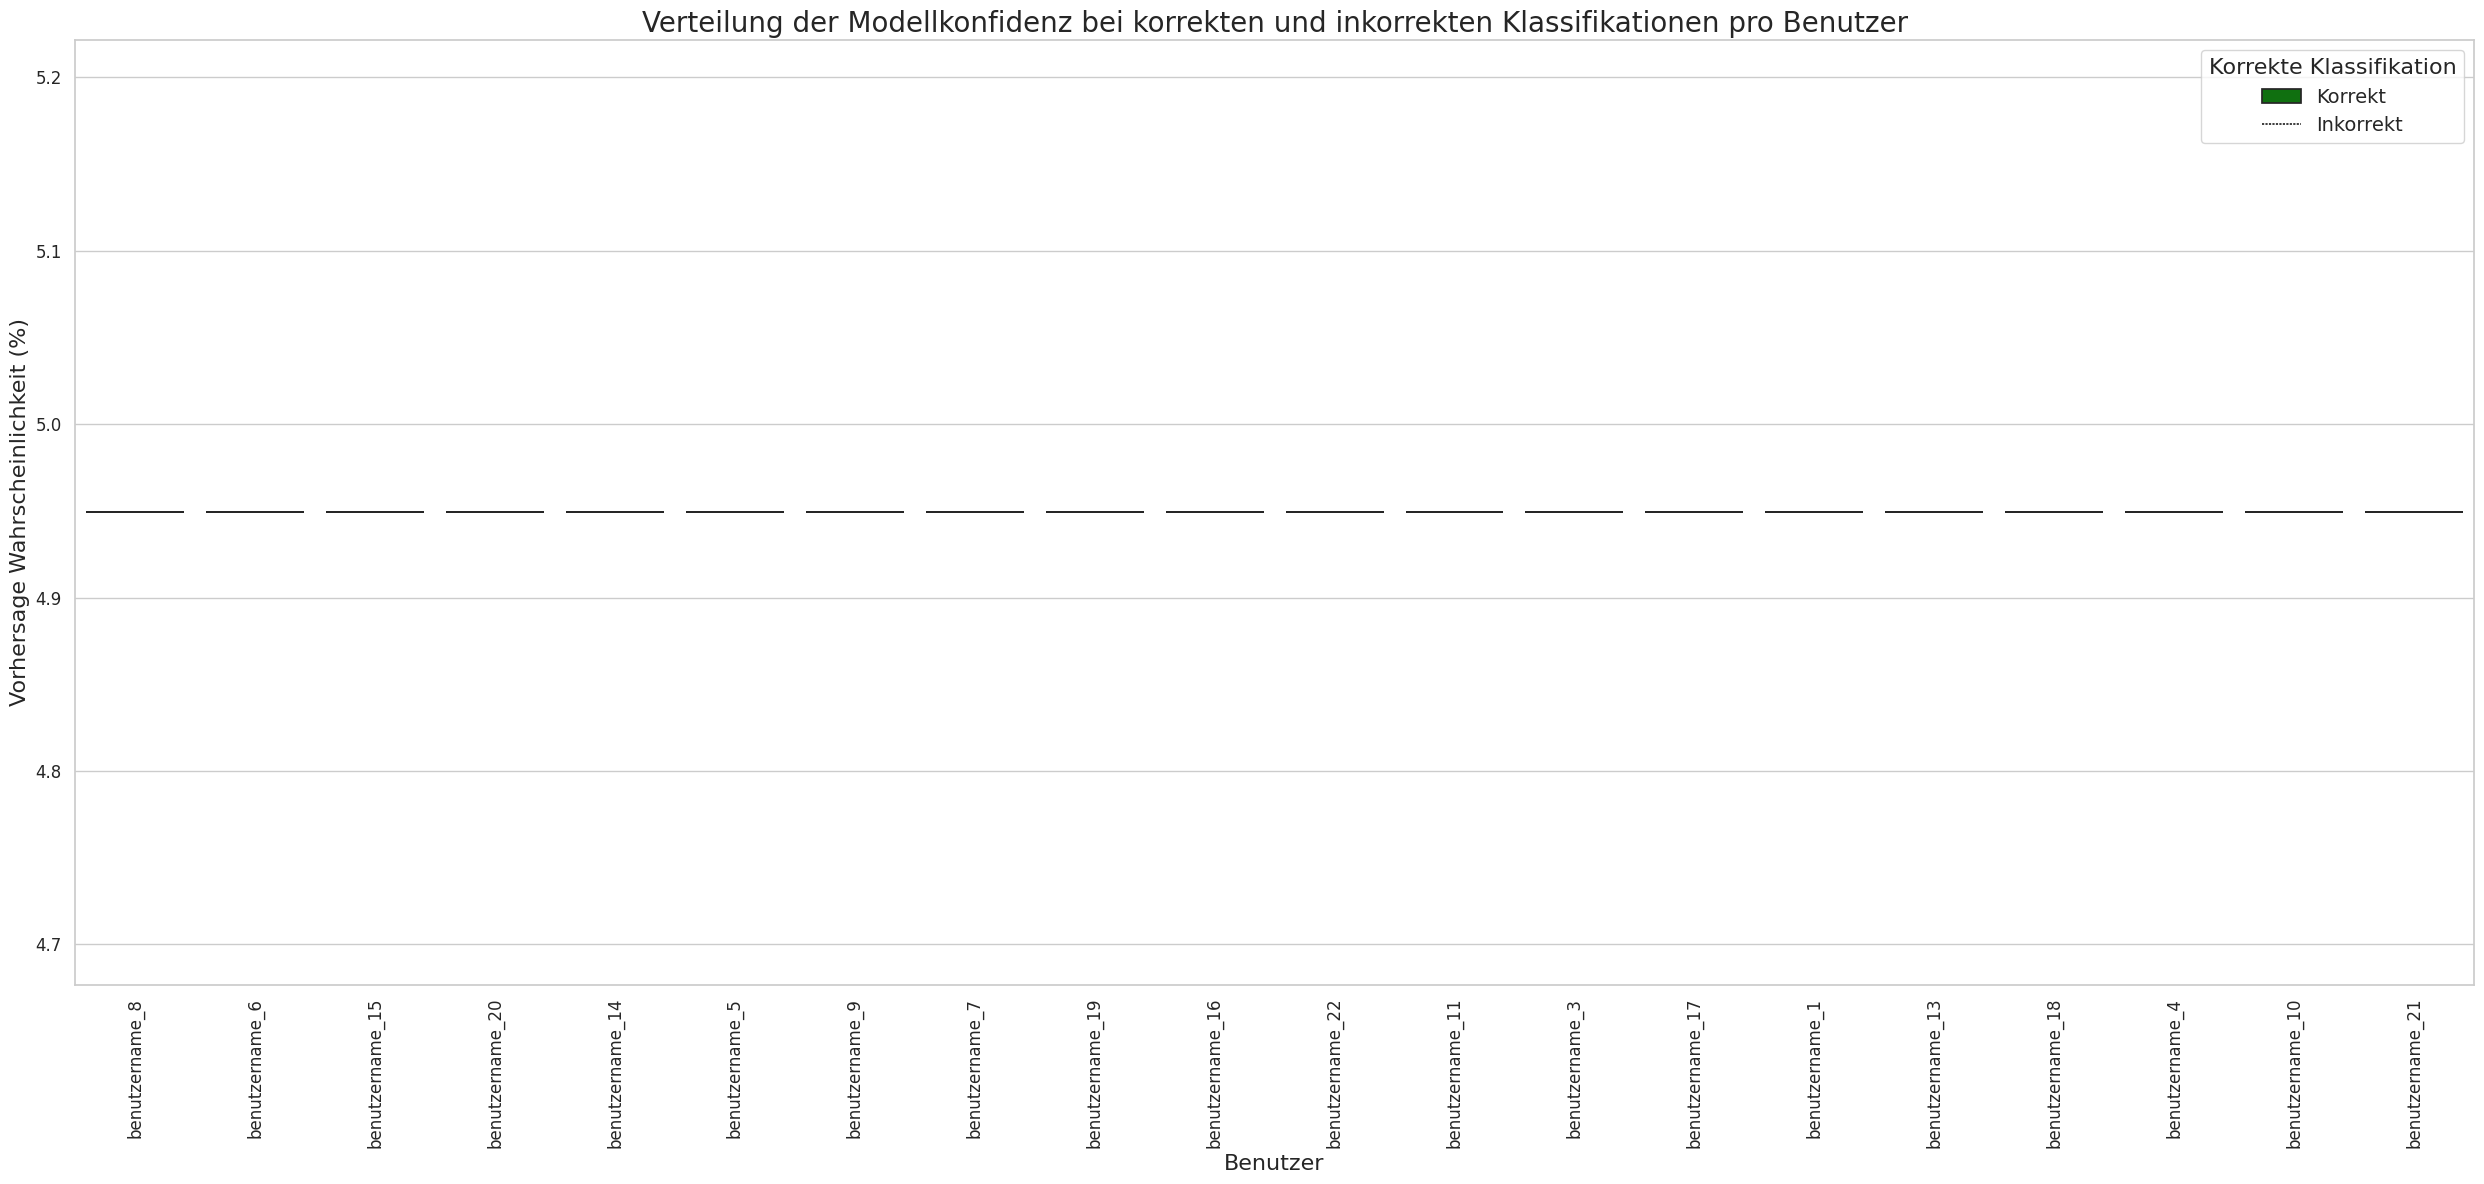

In [108]:
# Zelle AC: Prozentuale Darstellung der Modellkonfidenz pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie eine Liste zur Speicherung der Daten
data_records = []

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user, metrics in evaluation_results.items():
    y_pred_prob = metrics.get('y_pred_prob', [])
    y_true = metrics.get('y_true', [])
    
    if len(y_pred_prob) == 0 or len(y_true) == 0:
        print(f"Keine Vorhersagen oder wahren Labels für Benutzer {user}.")
        continue
    
    # Durchlaufen Sie alle Vorhersagen und speichern Sie die relevanten Informationen
    for i in range(len(y_pred_prob)):
        pred_prob = y_pred_prob[i] * 100  # Konvertieren in Prozent
        pred_label = 1 if pred_prob > 50 else 0
        true_label = y_true[i]
        is_correct = pred_label == true_label
        data_records.append({
            'Benutzer': user,
            'Vorhersage_Prozent': pred_prob,
            'Korrekt': is_correct
        })

# Erstellen eines DataFrames
data = pd.DataFrame(data_records)

# Setze den Stil von Seaborn
sns.set(style="whitegrid")

# Erstellen des Violinplots zur Darstellung der Konfidenzverteilung in Prozent
plt.figure(figsize=(25, 12))  # Größere Abbildung für bessere Lesbarkeit

sns.violinplot(
    x='Benutzer',
    y='Vorhersage_Prozent',
    hue='Korrekt',
    data=data,
    split=True,
    palette={True: 'green', False: 'red'},
    inner='quartile'
)

# Anpassen der Beschriftungen und Titel
plt.xlabel('Benutzer', fontsize=16)
plt.ylabel('Vorhersage Wahrscheinlichkeit (%)', fontsize=16)
plt.title('Verteilung der Modellkonfidenz bei korrekten und inkorrekten Klassifikationen pro Benutzer', fontsize=20)

# Anpassung der Legende
plt.legend(title='Korrekte Klassifikation', labels=['Korrekt', 'Inkorrekt'], fontsize=14, title_fontsize=16)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

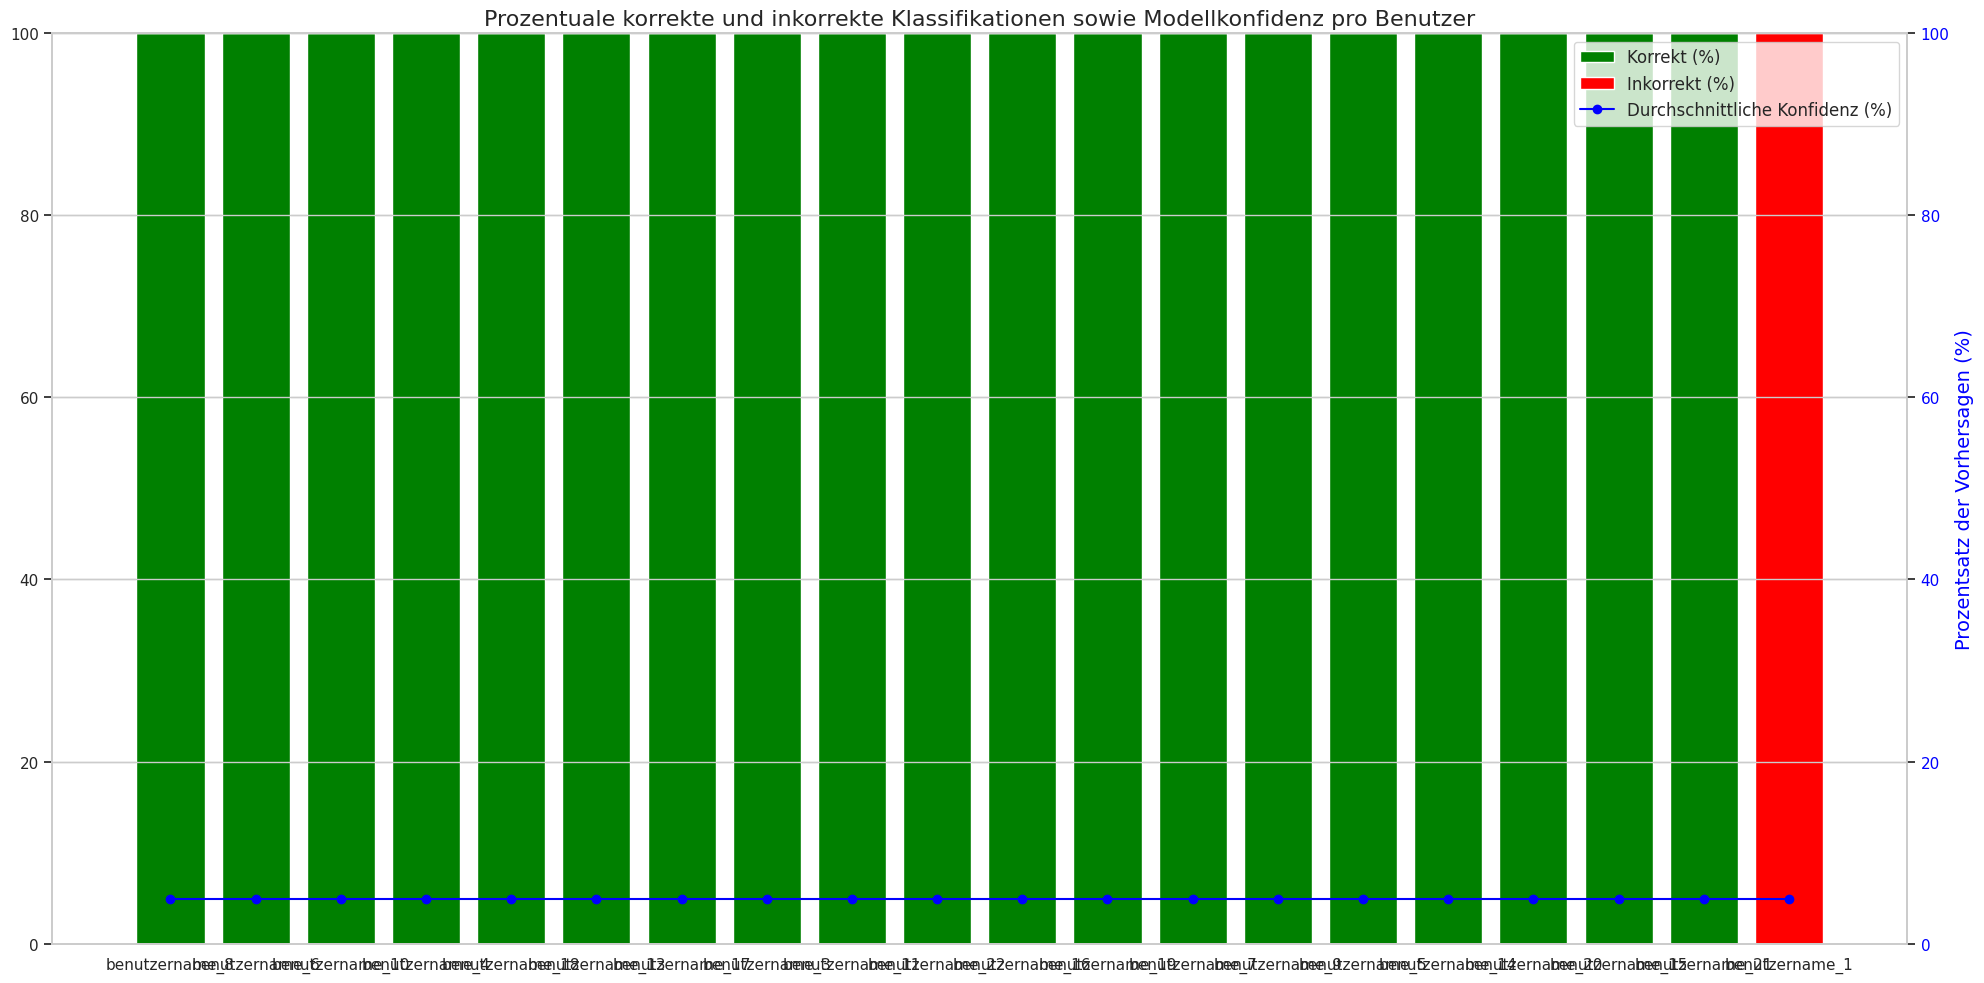

In [97]:
# Zelle AC: Prozentuale Darstellung der korrekten und inkorrekten Klassifikationen sowie der Modellkonfidenz pro Benutzer

# Berechnen der Prozentsätze
data['Korrekt_Percent'] = (data['Korrekt'] / (data['Korrekt'] + data['Inkorrekt'])) * 100
data['Inkorrekt_Percent'] = (data['Inkorrekt'] / (data['Korrekt'] + data['Inkorrekt'])) * 100

# Erstellen des gestapelten Balkendiagramms mit Prozentsätzen
plt.figure(figsize=(20, 10))

# Balken für korrekte und inkorrekte Vorhersagen in Prozent
bar_correct = plt.bar(data['Benutzer'], data['Korrekt_Percent'], color='green', label='Korrekt (%)')
bar_incorrect = plt.bar(data['Benutzer'], data['Inkorrekt_Percent'], bottom=data['Korrekt_Percent'], color='red', label='Inkorrekt (%)')

# Linienachse für die durchschnittliche Konfidenz
ax2 = plt.twinx()
# Konfidenz in Prozent umrechnen
data['Durchschnittliche Konfidenz_Percent'] = data['Durchschnittliche Konfidenz'] * 100
ax2.plot(data['Benutzer'], data['Durchschnittliche Konfidenz_Percent'], color='blue', marker='o', label='Durchschnittliche Konfidenz (%)')
ax2.set_ylabel('Durchschnittliche Konfidenz (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 100)  # Da Prozentsätze zwischen 0 und 100 liegen

# Beschriftungen und Titel
plt.xlabel('Benutzer', fontsize=14)
plt.ylabel('Prozentsatz der Vorhersagen (%)', fontsize=14)
plt.title('Prozentuale korrekte und inkorrekte Klassifikationen sowie Modellkonfidenz pro Benutzer', fontsize=16)

# Legenden
fig = plt.gcf()
handles1, labels1 = fig.axes[0].get_legend_handles_labels()
handles2, labels2 = fig.axes[1].get_legend_handles_labels()
plt.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc='upper right', fontsize=12)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(rotation=90, fontsize=12)

plt.tight_layout()
plt.show()

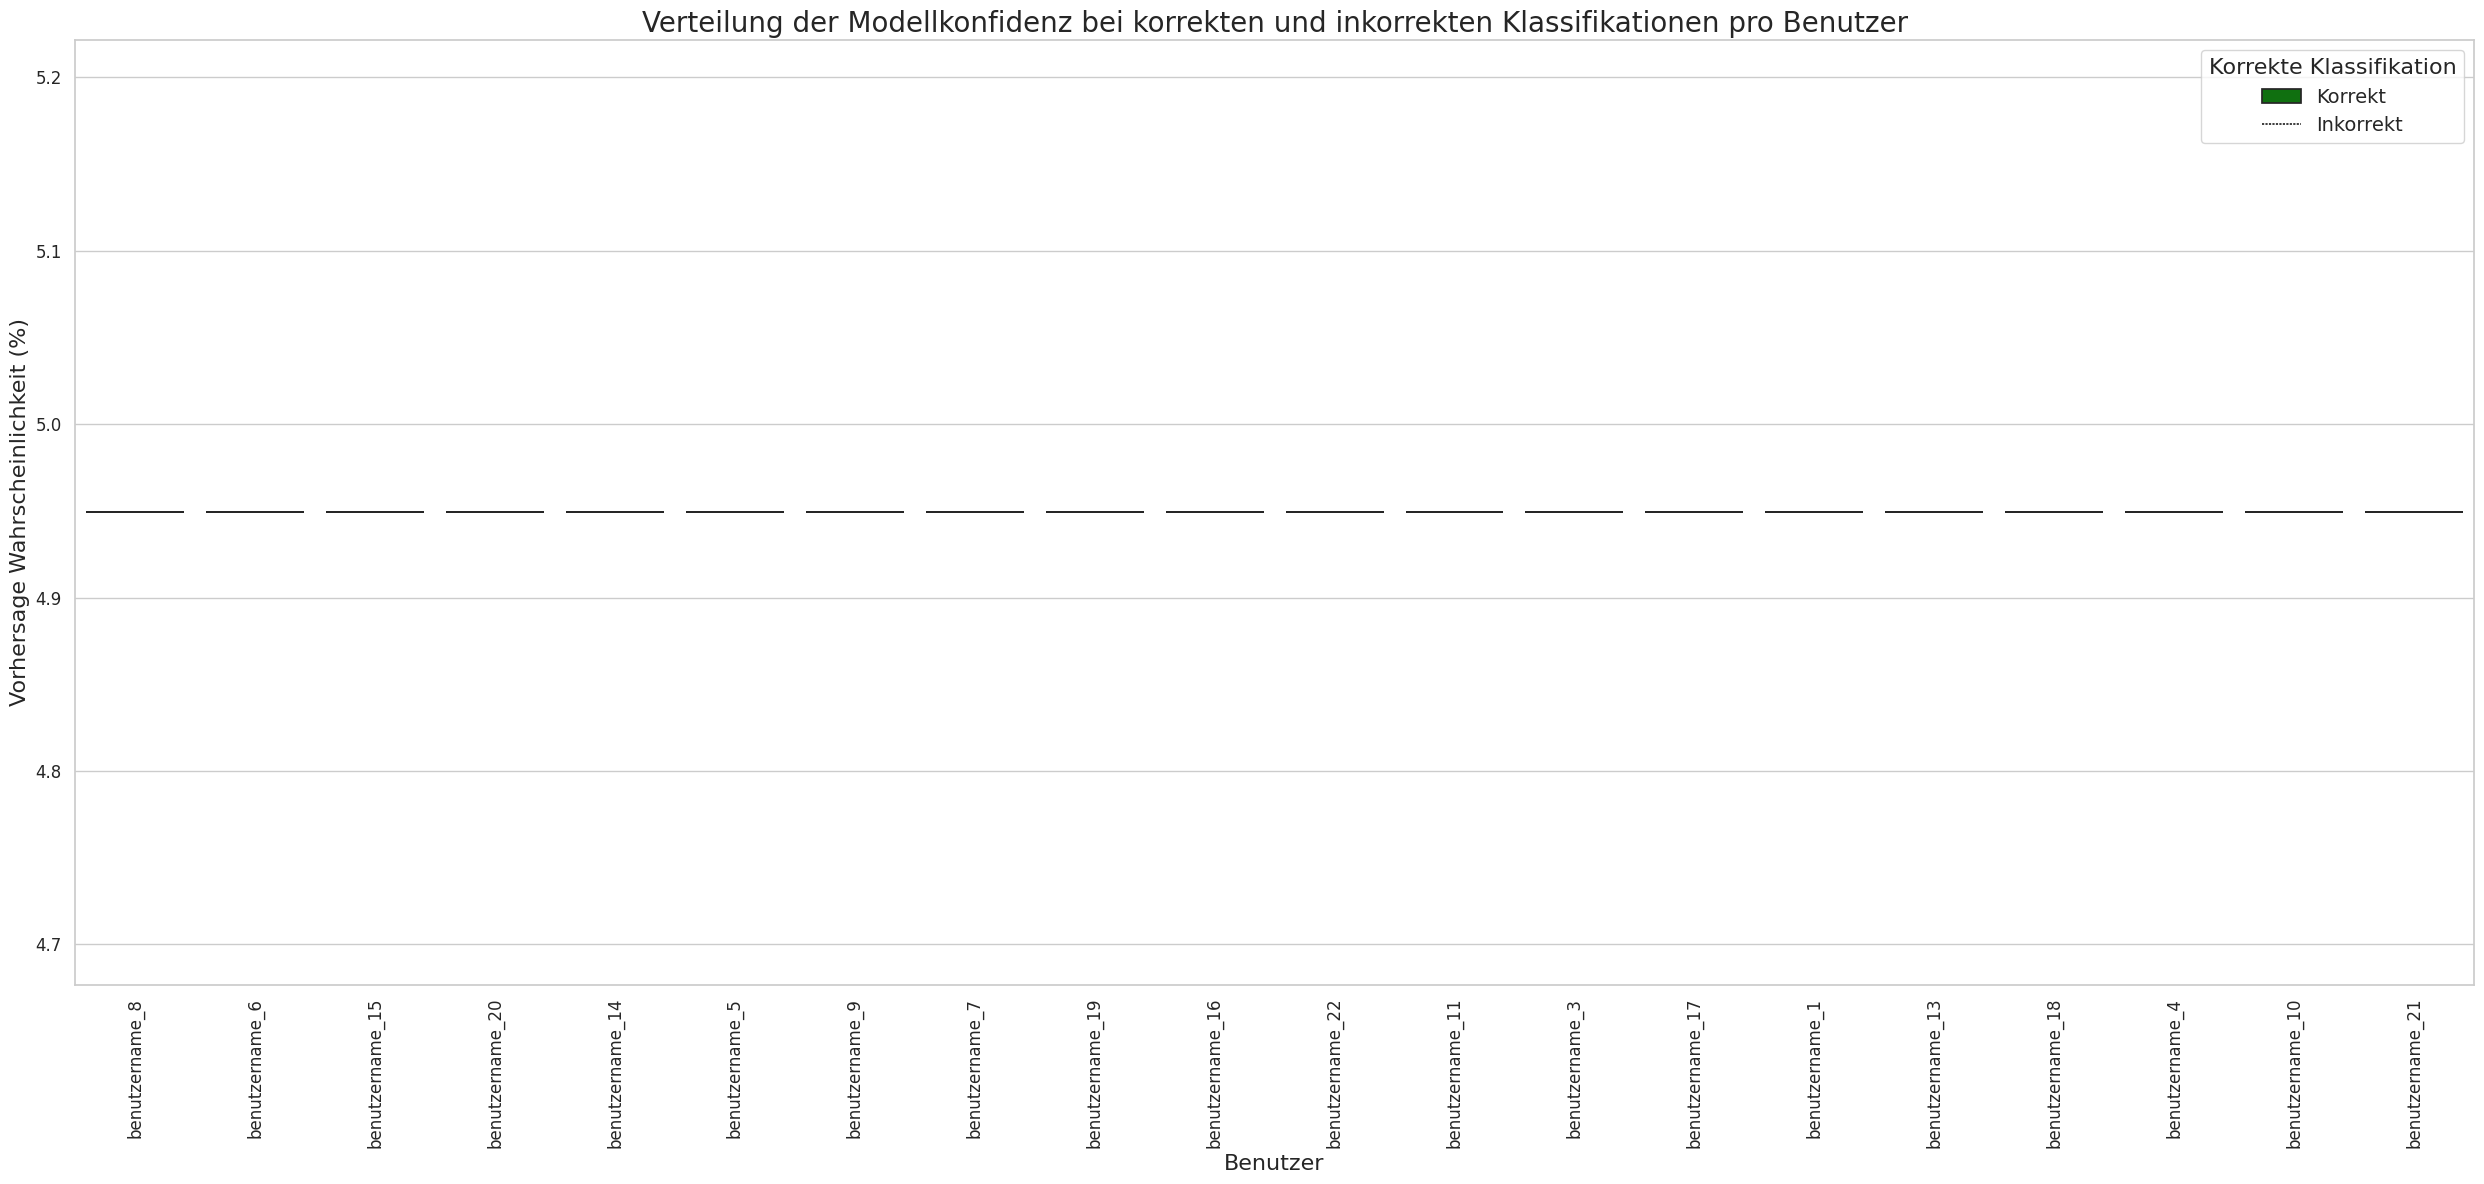

In [110]:
# Zelle AC: Prozentuale Darstellung der Modellkonfidenz pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie eine Liste zur Speicherung der Daten
data_records = []

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user, metrics in evaluation_results.items():
    y_pred_prob = metrics.get('y_pred_prob', [])
    y_true = metrics.get('y_true', [])
    
    if len(y_pred_prob) == 0 or len(y_true) == 0:
        print(f"Keine Vorhersagen oder wahren Labels für Benutzer {user}.")
        continue
    
    # Durchlaufen Sie alle Vorhersagen und speichern Sie die relevanten Informationen
    for i in range(len(y_pred_prob)):
        pred_prob = y_pred_prob[i] * 100  # Konvertieren in Prozent
        pred_label = 1 if pred_prob > 50 else 0
        true_label = y_true[i]
        is_correct = pred_label == true_label
        data_records.append({
            'Benutzer': user,
            'Vorhersage_Prozent': pred_prob,
            'Korrekt': is_correct
        })

# Erstellen eines DataFrames
data = pd.DataFrame(data_records)

# Setze den Stil von Seaborn
sns.set(style="whitegrid")

# Erstellen des Violinplots zur Darstellung der Konfidenzverteilung in Prozent
plt.figure(figsize=(25, 12))  # Größere Abbildung für bessere Lesbarkeit

sns.violinplot(
    x='Benutzer',
    y='Vorhersage_Prozent',
    hue='Korrekt',
    data=data,
    split=True,
    palette={True: 'green', False: 'red'},
    inner='quartile'
)

# Anpassen der Beschriftungen und Titel
plt.xlabel('Benutzer', fontsize=16)
plt.ylabel('Vorhersage Wahrscheinlichkeit (%)', fontsize=16)
plt.title('Verteilung der Modellkonfidenz bei korrekten und inkorrekten Klassifikationen pro Benutzer', fontsize=20)

# Anpassung der Legende
plt.legend(title='Korrekte Klassifikation', labels=['Korrekt', 'Inkorrekt'], fontsize=14, title_fontsize=16)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

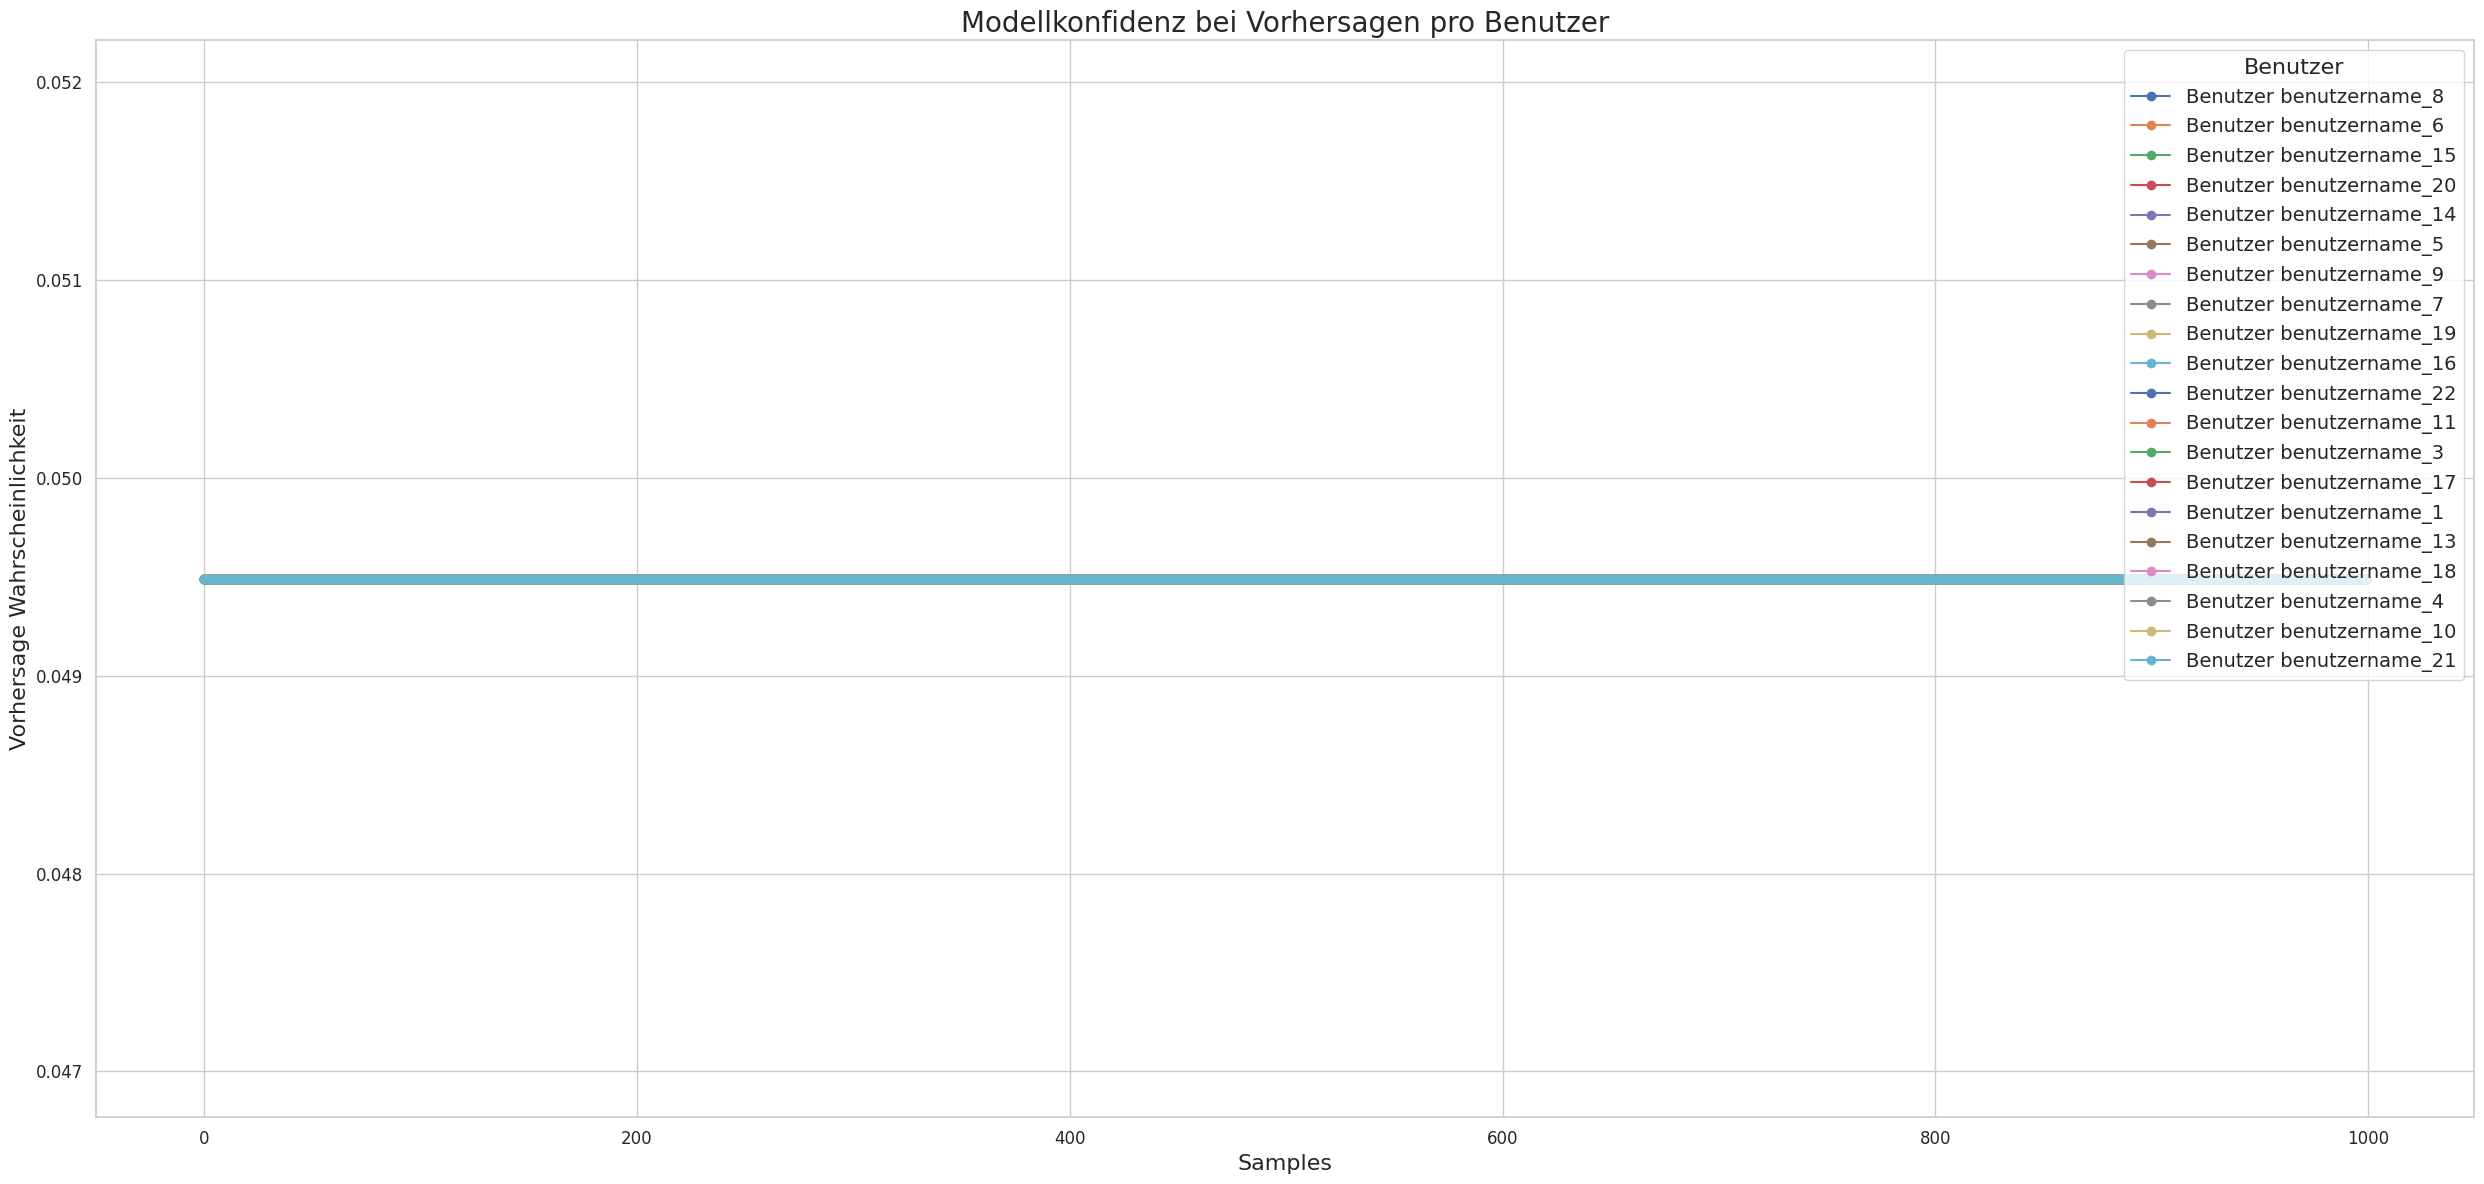

In [113]:
# Zelle AB: Visualisierung der Modellkonfidenz pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie eine Liste zur Speicherung der Daten
data_records = []

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user, metrics in evaluation_results.items():
    y_pred_prob = metrics.get('y_pred_prob', [])
    y_true = metrics.get('y_true', [])
    
    if len(y_pred_prob) == 0 or len(y_true) == 0:
        print(f"Keine Vorhersagen oder wahren Labels für Benutzer {user}.")
        continue
    
    # Durchlaufen Sie alle Vorhersagen und speichern Sie die relevanten Informationen
    for i in range(len(y_pred_prob)):
        pred_prob = y_pred_prob[i]
        true_label = y_true[i]
        data_records.append({
            'Benutzer': user,
            'Sample': i,
            'Vorhersage_Probabilität': pred_prob,
            'True_Label': true_label
        })

# Erstellen eines DataFrames
data = pd.DataFrame(data_records)

# Setze den Stil von Seaborn
sns.set(style="whitegrid")

# Erstellen des Liniendiagramms zur Darstellung der Konfidenzverteilung
plt.figure(figsize=(25, 12))  # Größere Abbildung für bessere Lesbarkeit

# Liniendiagramm für jeden Benutzer
for user in data['Benutzer'].unique():
    user_data = data[data['Benutzer'] == user]
    plt.plot(user_data['Sample'], user_data['Vorhersage_Probabilität'], label=f'Benutzer {user}', marker='o')

# Anpassen der Beschriftungen und Titel
plt.xlabel('Samples', fontsize=16)
plt.ylabel('Vorhersage Wahrscheinlichkeit', fontsize=16)
plt.title('Modellkonfidenz bei Vorhersagen pro Benutzer', fontsize=20)

# Anpassung der Legende
plt.legend(title='Benutzer', fontsize=14, title_fontsize=16)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

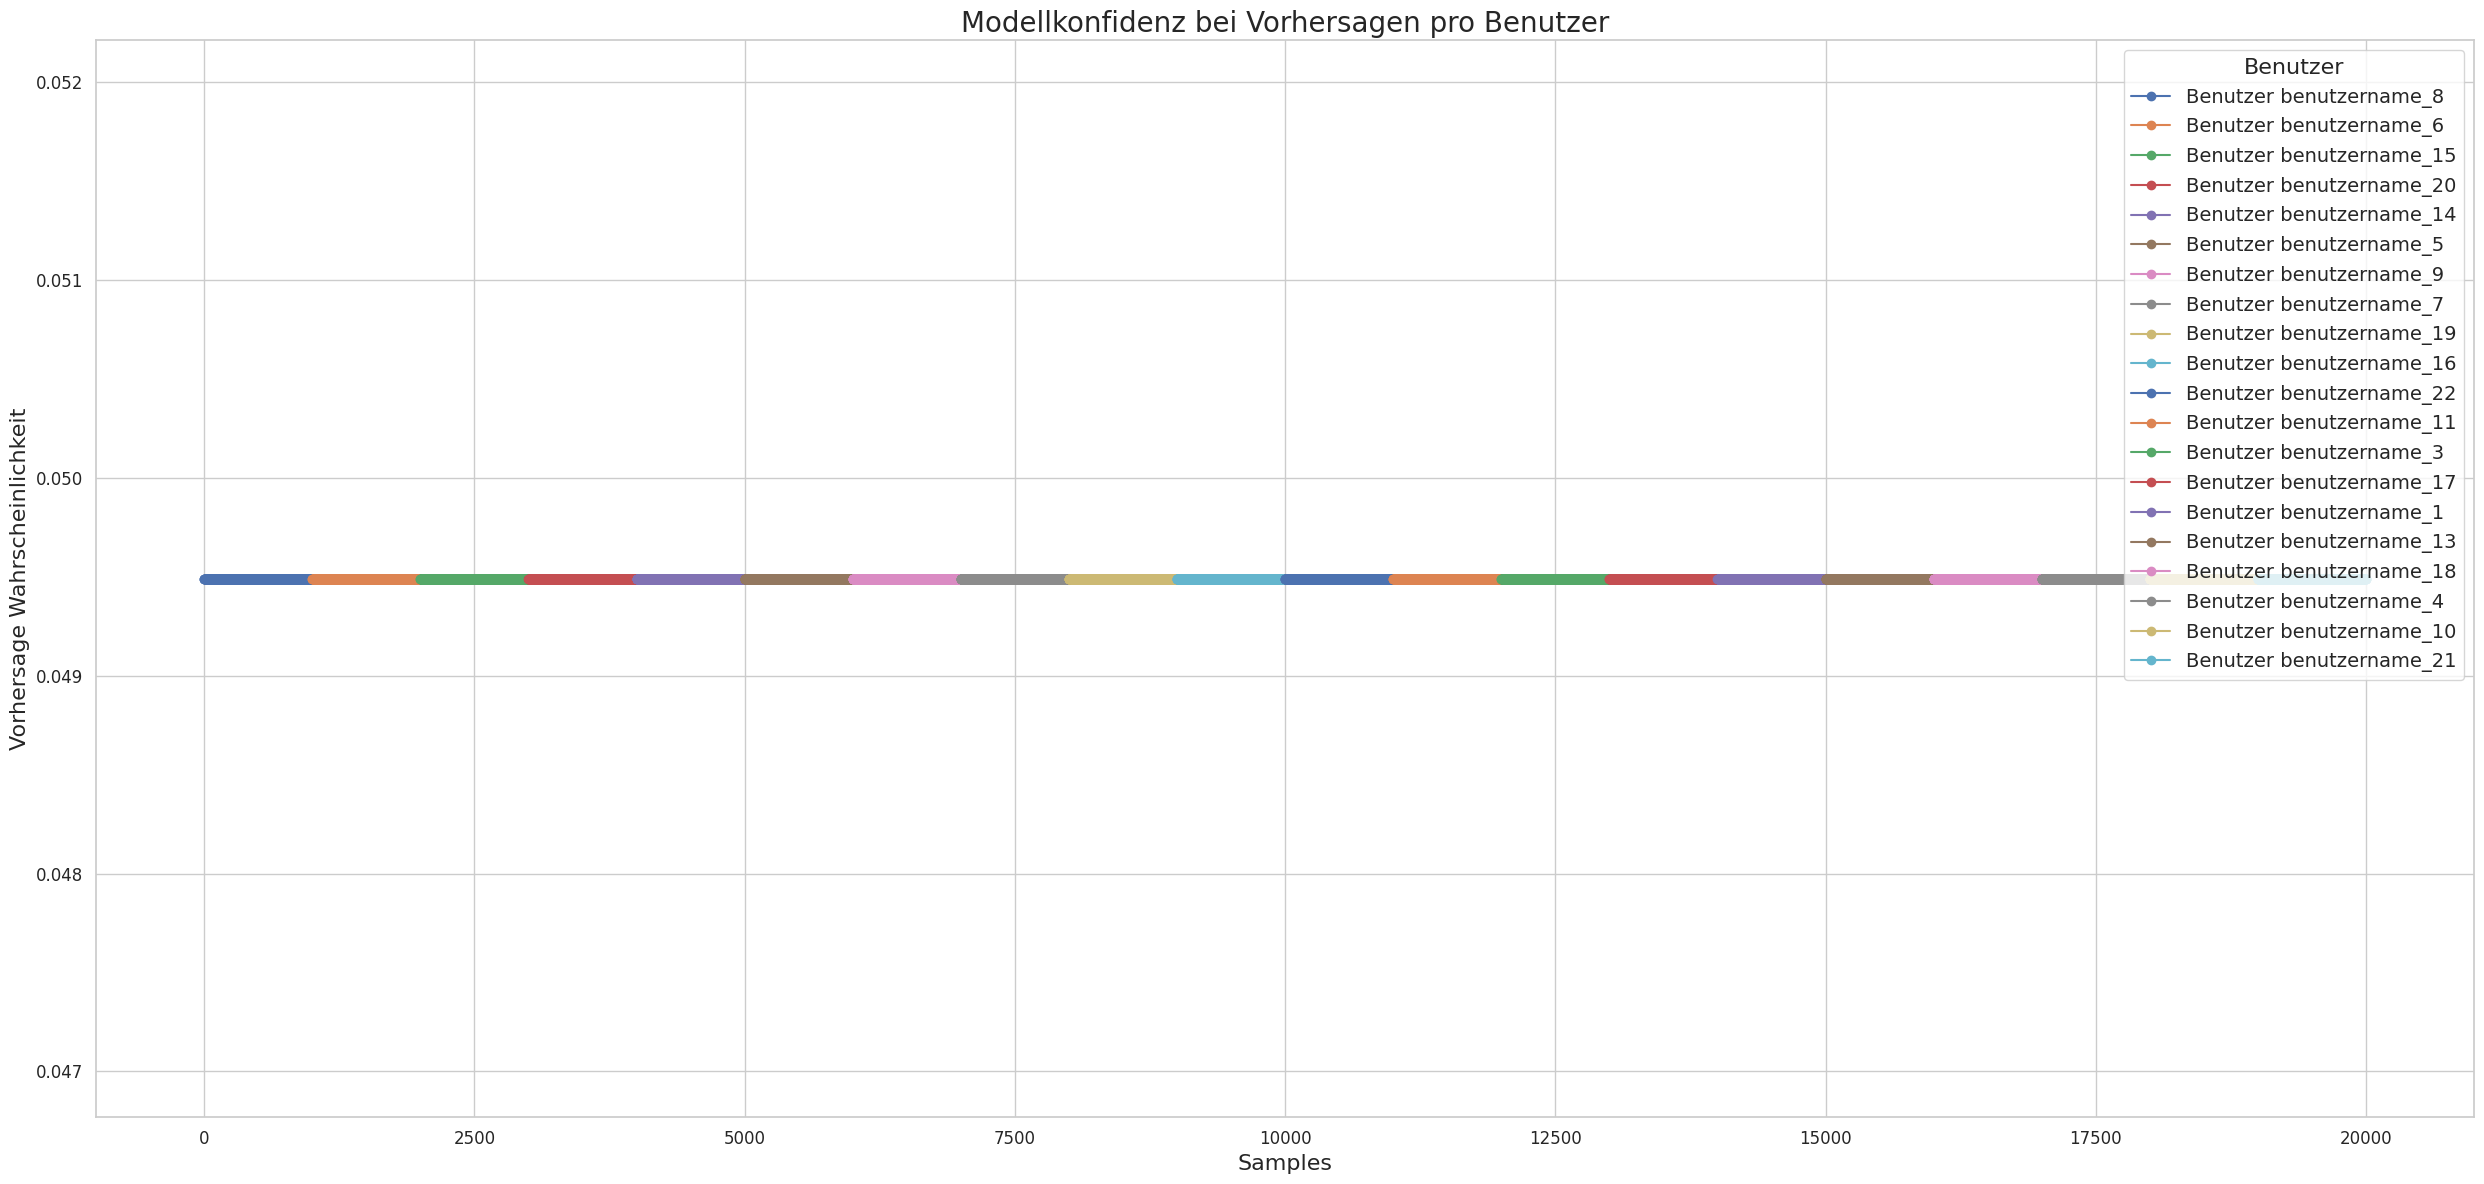

In [115]:
# Zelle AB: Visualisierung der Modellkonfidenz pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie eine Liste zur Speicherung der Daten
data_records = []

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user, metrics in evaluation_results.items():
    y_pred_prob = metrics.get('y_pred_prob', [])
    y_true = metrics.get('y_true', [])
    
    if len(y_pred_prob) == 0 or len(y_true) == 0:
        print(f"Keine Vorhersagen oder wahren Labels für Benutzer {user}.")
        continue
    
    # Durchlaufen Sie alle Vorhersagen und speichern Sie die relevanten Informationen
    for i in range(len(y_pred_prob)):
        pred_prob = y_pred_prob[i]
        true_label = y_true[i]
        is_correct = (pred_prob > 0.5) == true_label
        data_records.append({
            'Benutzer': user,
            'Vorhersage_Probabilität': pred_prob,
            'Korrekt': is_correct
        })

# Erstellen eines DataFrames
data = pd.DataFrame(data_records)

# Setze den Stil von Seaborn
sns.set(style="whitegrid")

# Erstellen des Liniendiagramms zur Darstellung der Konfidenzverteilung
plt.figure(figsize=(25, 12))  # Größere Abbildung für bessere Lesbarkeit

# Liniendiagramm für jeden Benutzer
for user in data['Benutzer'].unique():
    user_data = data[data['Benutzer'] == user]
    plt.plot(user_data.index, user_data['Vorhersage_Probabilität'], label=f'Benutzer {user}', marker='o')

# Anpassen der Beschriftungen und Titel
plt.xlabel('Samples', fontsize=16)
plt.ylabel('Vorhersage Wahrscheinlichkeit', fontsize=16)
plt.title('Modellkonfidenz bei Vorhersagen pro Benutzer', fontsize=20)

# Anpassung der Legende
plt.legend(title='Benutzer', fontsize=14, title_fontsize=16)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

In [116]:
# Zelle AB: Visualisierung der Modellkonfidenz pro Benutzer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialisieren Sie eine Liste zur Speicherung der Daten
data_records = []

# Wählen Sie die Benutzer aus (einschließlich Benutzer 1)
selected_users = ['user_1', 'user_2', 'user_3', 'user_4']

# Durchlaufen Sie die Evaluationsergebnisse und extrahieren Sie die benötigten Werte
for user in selected_users:
    if user not in evaluation_results:
        print(f"Keine Evaluationsergebnisse für Benutzer {user}.")
        continue
    
    metrics = evaluation_results[user]
    y_pred_prob = metrics.get('y_pred_prob', [])
    y_true = metrics.get('y_true', [])
    
    if len(y_pred_prob) == 0 or len(y_true) == 0:
        print(f"Keine Vorhersagen oder wahren Labels für Benutzer {user}.")
        continue
    
    # Begrenzen auf 50 Samples
    num_samples = min(50, len(y_pred_prob))
    
    # Durchlaufen Sie alle Vorhersagen und speichern Sie die relevanten Informationen
    for i in range(num_samples):
        pred_prob = y_pred_prob[i]
        true_label = y_true[i]
        data_records.append({
            'User': user,
            'Sample': i,
            'Prediction_Probability': pred_prob,
            'True_Label': true_label
        })

# Erstellen eines DataFrames
data = pd.DataFrame(data_records)

# Setze den Stil von Seaborn
sns.set(style="whitegrid")

# Erstellen des Liniendiagramms zur Darstellung der Konfidenzverteilung
plt.figure(figsize=(25, 12))  # Größere Abbildung für bessere Lesbarkeit

# Liniendiagramm für jeden Benutzer
for user in data['User'].unique():
    user_data = data[data['User'] == user]
    plt.plot(user_data['Sample'], user_data['Prediction_Probability'], label=f'User {user}', marker='o')

# Anpassen der Beschriftungen und Titel
plt.xlabel('Samples', fontsize=16)
plt.ylabel('Prediction Probability', fontsize=16)
plt.title('Model Confidence in Predictions per User', fontsize=20)

# Anpassung der Legende
plt.legend(title='User', fontsize=14, title_fontsize=16)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show() Zelle AB: Zelle Visualisierung AB: AB: der Visualisierung Modellkonfidenz Visualisierung der pro der Modellkonfidenz Benutzer pro

import Benutzer Modellkonfidenz matplotlib.pyplot

import as matplotlib.pyplot plt pro
import as Benutzer seaborn plt as

import
import sns seaborn
import as matplotlib.pyplot pandas sns as
import pd as

# pandas plt Initialisieren as pd Sie
import

# eine Initialisieren seaborn Sie Liste as eine zur Liste Speicherung zur sns der Speicherung Daten
import der
data_records Daten pandas =
data_records as [] = pd

# [] Wählen Sie

#

# die Wählen Initialisieren Benutzer aus Sie (einschließlich Sie die Benutzer Benutzer 1) eine aus
selected_users = (einschließlich Liste Benutzer ['user_1', zur 1) 'user_2',
selected_users 'user_3', = Speicherung 'user_4'] ['user_1',

# der 'user_2', Durchlaufen Sie 'user_3', Daten die 'user_4'] Evaluationsergebnisse
data_records

# und Durchlaufen = extrahieren Sie die Sie [] die Evaluationsergebnisse und benötigten

# extrahieren Werte Wählen Sie
for user die in benötigten Sie Werte selected_users: die
    if
for user user Benutzer not in in aus selected_users: evaluation_results:
    if
        print(f"Keine (einschließlich user Evaluationsergebnisse not Benutzer für in Benutzer evaluation_results: 1) {user}.")
        print(f"Keine
        continue Evaluationsergebnisse
selected_users
    
    metrics für = = Benutzer evaluation_results[user] ['user_1', {user}.")
    y_pred_prob
        continue 'user_2', =
    
    metrics metrics.get('y_pred_prob', = 'user_3', []) evaluation_results[user]
    y_true 'user_4']
    y_pred_prob = = metrics.get('y_true',

# metrics.get('y_pred_prob', []) []) Durchlaufen
    y_true
    
    if = Sie len(y_pred_prob) metrics.get('y_true', == die 0 []) or
    
    if Evaluationsergebnisse len(y_true) len(y_pred_prob) == == und 0: 0 extrahieren
        print(f"Keine or Vorhersagen len(y_true) Sie oder == wahren 0: die Labels
        print(f"Keine für benötigten Vorhersagen Benutzer Werte oder {user}.")
for wahren
        continue
    
    # Labels Begrenzen user für auf Benutzer in 50 {user}.") Samples
        continue
    num_samples selected_users:
    
    # = Begrenzen min(50, auf len(y_pred_prob))
    if 50
    
    # Samples user Durchlaufen
    num_samples Sie not = alle min(50, Vorhersagen in len(y_pred_prob)) und
    
    # speichern evaluation_results: Sie Durchlaufen
        print(f"Keine Sie die alle Evaluationsergebnisse Vorhersagen relevanten und Informationen für speichern
    for i Benutzer Sie in die range(num_samples): {user}.") relevanten
        pred_prob Informationen =
        continue y_pred_prob[i]
    for
    
    metrics i
        true_label in = = range(num_samples): y_true[i]
        pred_prob evaluation_results[user]
        data_records.append({ =
            'User':
    y_pred_prob user, y_pred_prob[i] =
        true_label
            'Sample': i, = metrics.get('y_pred_prob',
            'Prediction_Probability': y_true[i] pred_prob,
        data_records.append({
            'True_Label':
            'User': []) true_label
        }) user,

#
    y_true Erstellen
            'Sample': eines = i, DataFrames metrics.get('y_true',
            'Prediction_Probability':
data pred_prob, = []) pd.DataFrame(data_records)
            'True_Label':
    
    if

# true_label
        }) Setze len(y_pred_prob)

# den == Stil Erstellen von 0 Seaborn eines or DataFrames
sns.set(style
data= ="whitegrid") len(y_true)

# pd.DataFrame(data_records) == Erstellen

# Setze des 0: den Liniendiagramms Stil zur
        print(f"Keine von Darstellung Vorhersagen Seaborn der
sns.set(style oder Konfidenzverteilung=
plt.figure(figsize"whitegrid")= wahren

#(25, Erstellen Labels 12)) des  # Liniendiagramms für Größere zur Abbildung Benutzer Darstellung der für {user}.") Konfidenzverteilung bessere Lesbarkeit
plt.figure(figsize
        continue

#= Liniendiagramm
    
    #(25, für 12)) jeden Begrenzen  # Benutzer Größere
for auf user Abbildung in 50 für bessere data['User'].unique(): Samples Lesbarkeit
    user_data

# =
    num_samples Liniendiagramm data[data['User'] = == für user] jeden min(50,
    plt.plot(user_data['Sample'], Benutzer user_data['Prediction_Probability'],
for len(y_pred_prob)) label user
    
    # in= data['User'].unique():f'User Durchlaufen
    user_data {user}', = Sie marker= data[data['User'] =='o') alle user]

#
    plt.plot(user_data['Sample'], Vorhersagen Anpassen user_data['Prediction_Probability'], der und label Beschriftungen speichern und= Titelf'User
plt.xlabel('Samples', Sie {user}', fontsize= die marker16) relevanten=
plt.ylabel('Prediction'o') Probability', Informationen

# fontsize
    for Anpassen=16) der i
plt.title('Model Beschriftungen Confidence und in in Titel range(num_samples): Predictions
plt.xlabel('Samples', per fontsize User',
        pred_prob= fontsize16) ==
plt.ylabel('Prediction20) y_pred_prob[i] Probability',

#
        true_label fontsize= Anpassung =16) der
plt.title('Model y_true[i] Legende Confidence
plt.legend(title in
        data_records.append({= Predictions per'User',
            'User': User', fontsize fontsize== user,14,20) title_fontsize
            'Sample':=

# Anpassung16) i, der

# Legende
            'Prediction_Probability': Drehung
plt.legend(title= der pred_prob,'User', x fontsize
            'True_Label':-=Achsen true_label14,-
        }) title_fontsizeBeschriftungen=

#16) für

# bessere Erstellen Drehung Lesbarkeit eines der
plt.xticks(fontsize DataFrames= x12)-
plt.yticks(fontsize=
dataAchsen12)-

plt.tight_layout() =
plt.show()Beschriftungen für pd.DataFrame(data_records) bessere Lesbarkeit

#
plt.xticks(fontsize Setze=12) den
plt.yticks(fontsize= Stil12) von

plt.tight_layout() Seaborn
plt.show()
sns.set(style="whitegrid")

# Erstellen des Liniendiagramms zur Darstellung der Konfidenzverteilung
plt.figure(figsize=(25, 12))  # Größere Abbildung für bessere Lesbarkeit

# Liniendiagramm für jeden Benutzer
for user in data['User'].unique():
    user_data = data[data['User'] == user]
    plt.plot(user_data['Sample'], user_data['Prediction_Probability'], label=f'User {user}', marker='o')

# Anpassen der Beschriftungen und Titel
plt.xlabel('Samples', fontsize=16)
plt.ylabel('Prediction Probability', fontsize=16)
plt.title('Model Confidence in Predictions per User', fontsize=20)

# Anpassung der Legende
plt.legend(title='User', fontsize=14, title_fontsize=16)

# Drehung der x-Achsen-Beschriftungen für bessere Lesbarkeit
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3691115908.py, line 68)

## More Statistics

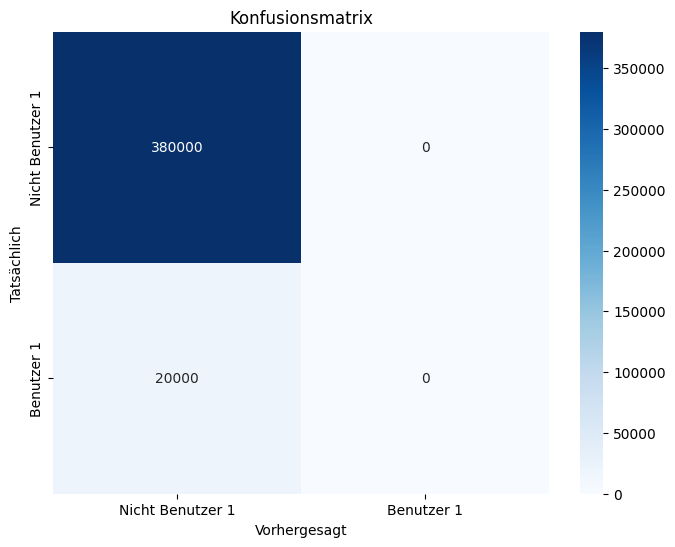

In [72]:
# Zelle 10: Visualisierung der Konfusionsmatrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Nicht Benutzer 1", "Benutzer 1"],
            yticklabels=["Nicht Benutzer 1", "Benutzer 1"])
plt.title('Konfusionsmatrix')
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.show()

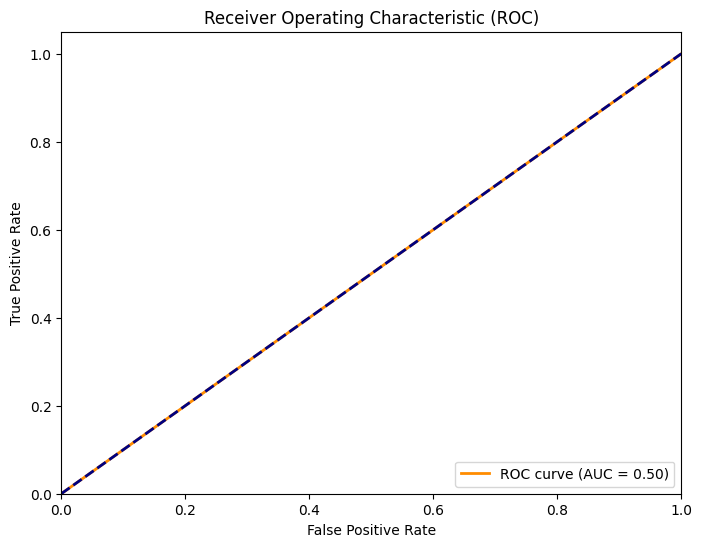

In [73]:
# Zelle 11: ROC Kurve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

Visualisiere Fehlklassifikationen...


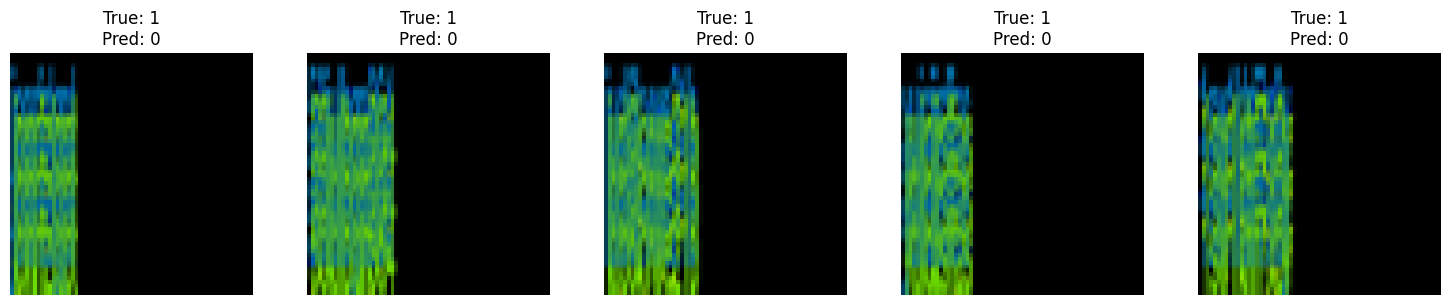

In [74]:
# Zelle 12: Fehlklassifikationen visualisieren
def plot_misclassified_examples(generator, y_true, y_pred, n_examples=5):
    misclassified_indices = np.where(y_true != y_pred)[0]
    
    if len(misclassified_indices) == 0:
        print("Keine Fehlklassifikationen gefunden.")
        return
    
    n_examples = min(n_examples, len(misclassified_indices))
    plt.figure(figsize=(15, 3))
    
    for i, idx in enumerate(misclassified_indices[:n_examples]):
        # Berechne welche Batch und welcher Index innerhalb der Batch
        batch_num = idx // generator.batch_size
        idx_in_batch = idx % generator.batch_size
        X_batch, _ = generator[batch_num]
        
        plt.subplot(1, n_examples, i+1)
        plt.imshow(X_batch[idx_in_batch])
        plt.title(f'True: {y_true[idx]}\nPred: {y_pred[idx]}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Visualisiere Fehlklassifikationen...")
plot_misclassified_examples(test_generator, y_true, y_pred, n_examples=5)